In [473]:
# from common import *
from my import *

import os
import random
import pickle
from pathlib import Path
from IPython.display import display, HTML

from tqdm import tqdm
from itertools import product
import joblib
from joblib import Parallel, delayed, parallel_backend

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

import time
import datetime
from datetime import datetime
from timeit import default_timer as timer
from dateutil.relativedelta import relativedelta

from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, chi2, RFE
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from lightgbm import LGBMClassifier
from xgboost import XGBRegressor, XGBClassifier

plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline
%config InlineBackend.figure_format='retina'

# set random seed for reproducibility
def set_seeds(seed=777):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

SEED = 777
set_seeds(SEED)
print(f'Random seed set to: {SEED}')

# checking
set_seeds(SEED)
print(np.random.rand(3))
set_seeds(SEED)
print(np.random.rand(3))

Random seed set to: 777
[0.15266373 0.30235661 0.06203641]
[0.15266373 0.30235661 0.06203641]


In [3]:
def print_cols(df, n=5): 
    with pd.option_context('display.max_columns',None):
        # with pd.option_context('display.float_format', '{:,.4f}'.format):
            print(df.shape)
            display(df[:n])

# Load Data

In [446]:
data_path = 'data/df_dataset.csv'
merged_df = pd.read_csv(data_path)
merged_df['respondent_id'] = merged_df['respondent_id'].astype(str).str.replace('.0', '', regex=False)
merged_df.set_index('respondent_id', inplace=True)

In [447]:
print_cols(merged_df)

(18438, 197)


,is_sleep_deprived,daily_sleep_duration,sleep_risk_category,gender,age_years,race_hispanic_origin,race_hispanic_origin_with_asian,exam_period,country_of_birth,education_level,marital_status,family_income_to_poverty_ratio,body_measures_status_code,weight_kg,standing_height_cm,body_mass_index,upper_leg_length_cm,upper_arm_length_cm,arm_circumference_cm,waist_circumference_cm,hip_circumference_cm,waist_to_height_ratio,arm_selected_oscillometric,mid_arm_circumference_cm,systolic_bp_reading1_mmHg,diastolic_bp_reading1_mmHg,systolic_bp_reading2_mmHg,diastolic_bp_reading2_mmHg,systolic_bp_reading3_mmHg,diastolic_bp_reading3_mmHg,pulse_reading1_bpm,pulse_reading2_bpm,pulse_reading3_bpm,17alpha_hydroxyprogesterone_ng_dL,17alpha_hydroxyprogesterone_nmol_L,17alpha_hydroxyprogesterone_code,androstenedione_ng_dL,androstenedione_nmol_L,androstenedione_code,estradiol_pg_mL,estradiol_pmol_L,estradiol_code,estrone_ng_dL,estrone_pmol_L,estrone_code,estrone_sulfate_pg_mL,estrone_sulfate_pmol_L,estrone_sulfate_code,follicle_stimulating_hormone_mIU_mL,follicle_stimulating_hormone_code,luteinizing_hormone_mIU_mL,luteinizing_hormone_code,progesterone_ng_dL,progesterone_nmol_L,progesterone_code,sex_hormone_binding_globulin_nmol_L,sex_hormone_binding_globulin_code,direct_HDL_cholesterol_mg_dL,direct_HDL_cholesterol_mmol_L,total_cholesterol_mg_dL,total_cholesterol_mmol_L,high_sensitivity_CRP_mg_L,high_sensitivity_CRP_code,glycohemoglobin_percent,white_blood_cell_count_1000_per_uL,lymphocyte_percent,monocyte_percent,segmented_neutrophils_percent,eosinophils_percent,basophils_percent,lymphocyte_number_1000_per_uL,monocyte_number_1000_per_uL,segmented_neutrophils_number_1000_per_uL,eosinophils_number_1000_per_uL,basophils_number_1000_per_uL,red_blood_cell_count_million_per_uL,hemoglobin_g_dL,hematocrit_percent,mean_cell_volume_fL,mean_cell_hemoglobin_concentration_g_dL,mean_cell_hemoglobin_pg,red_cell_distribution_width_percent,platelet_count_1000_per_uL,mean_platelet_volume_fL,nucleated_red_blood_cells,sleep_time_weekdays_usual_hours,wake_time_weekdays_usual_hours,sleep_time_weekends_usual_hours,wake_time_weekends_usual_hours,sleep_time_consistency,ever_told_weak_kidneys,leak_during_physical_activity,urinate_before_reaching_toilet,frequent_urinary_leakage,significant_daily_impact,any_urinary_incontinence,ever_told_heart_failure,ever_told_asthma,treatment_anemia_last_3_months,ever_told_cancer,had_gallbladder_surgery,metal_objects_in_body,ever_told_heart_attack,ever_told_gallstones,ever_told_liver_condition,hay_fever_last_year,ever_told_copd,ever_told_angina,ever_told_arthritis,ever_told_coronary_disease,ever_told_stroke,ever_told_thyroid_problem,cancer_breast,cancer_prostate,cancer_skin_non_melanoma,cardiovascular_disease,chronic_condition_count,difficulty_from_problems_last_2_weeks,depression_binary,sleep_problems_flag,fatigue_flag,functional_impairment,significant_impairment,sleep_disturbance_score,poor_oral_health,mouth_ache_frequency_last_year_frequent,job_difficulty_due_to_mouth_last_year_frequent,insect_control_use,weed_control_use,any_pesticide_use,aspirin_recommended,aspirin_self_medication,current_aspirin_use,regular_periods_last_12_months,ever_been_pregnant,age_first_period,age_last_period,treated_pelvic_infection_ever,both_ovaries_removed,total_deliveries,had_hysterectomy,periods_started,menopausal,smoked_100_cigs_lifetime,questionnaire_mode_flag,smoke_cigs_now,current_smoker,num_smokers_inside_home,num_smokers_in_house,any_smokers_in_house,any_indoor_smoking,used_cigars_last_5_days,used_cigs_last_5_days,used_any_tobacco_last_5_days,smoked_tobacco_last_5_days,used_smokeless_tobacco_last_5_days,tried_lose_weight_last_year,weight_last_1_year_pounds,current_height_inches,current_weight_pounds,weight_loss_attempt,height_meters,bmi,weight_change_pounds,urinary_leakage_frequency,urinary_leakage_freq_category,feeling_down_last_2_weeks,trouble_sleeping_last_2_weeks,poor_appetite_or_overeating_last_2_weeks,moving_speaking_slow_or_fast_last_2_weeks,thoug

In [277]:
get_profile(merged_df)

## Overview 

<class 'pandas.core.frame.DataFrame'>
Index: 18438 entries, 109266 to 142310
Columns: 197 entries, is_sleep_deprived to weight_change_category
dtypes: float64(172), int64(1), object(24)
memory usage: 27.9+ MB

Number of variables: 197
Number of observations: 18438
Total missing cells: 391341
Total missing cells (%): 10.77
Duplicate columns: []
Duplicate columns (count): 0
Duplicate rows: []
Duplicate rows (count): 0

## Details


,col,dtype,all_can_be_num,value_cnt,nunique,null_cnt,blank_cnt,zero_cnt,spec_char_cnt,neg_cnt,mean,std,cv,min,25%,median,75%,max,most_freq_val,most_freq_cnt,least_freq_val,least_freq_cnt,max_length,min_length
0,is_sleep_deprived,int64,True,18438(100.0%),2,0,0,14424(78.23%),0,0,0.2177,0.4127,1.8957,0,0.0000,0.0000,0.0000,1,0,14424,1,4014,1,1
1,daily_sleep_duration,float64,True,18438(100.0%),621,0,0,0,0,0,7.8848,1.5305,0.1941,2.0000,7.0200,8.0000,8.7600,14.0200,8.0200,1050,7.6000,1,2,1
2,sleep_risk_category,object,False,18438(100.0%),2,0,0,0,0,0,NaN,NaN,NaN,High Risk,NaN,NaN,NaN,Low Risk,Low Risk,16940,High Risk,1498,9,8
3,gender,object,False,18438(100.0%),2,0,0,0,0,0,NaN,NaN,NaN,Female,NaN,NaN,NaN,Male,Female,9781,Male,8657,6,4
4,age_years,float64,True,18438(100.0%),65,0,0,0,0,0,49.0947,19.5606,0.3984,16.0000,32.0000,51.0000,65.0000,80.0000,80.0000,1181,78.0000,142,2,2
5,race_hispanic_origin,object,False,18438(100.0%),5,0,0,0,14711(79.79%),0,NaN,NaN,NaN,Mexican American,NaN,NaN,NaN,Other/Multi-Racial,Non-Hispanic White,8255,Mexican American,1852,18,14
6,race_hispanic_origin_with_asian,object,False,18438(100.0%),6,0,0,0,14711(79.79%),0,NaN,NaN,NaN,Mexican American,NaN,NaN,NaN,Other/Multi-Racial,Non-Hispanic White,8255,Other/Multi-Racial,1075,18,14
7,exam_period,object,False,15871(86.08%),2,2567(13.92%),0,0,15871(86.08%),0,NaN,NaN,NaN,May-Oct,NaN,NaN,NaN,Nov-Apr,Nov-Apr,8007,May-Oct,7864,7,7
8,country_of_birth,object,False,18436(99.99%),4,2(0.01%),0,0,0,0,NaN,NaN,NaN,Foreign Born,NaN,NaN,NaN,Unknown,US Born,14036,Unknown,1,12,7
9,education_level,object,False,16787(91.05%),7,1651(8.95%),0,0,15697(85.13%),0,NaN,NaN,NaN,9-11th Grade,NaN,NaN,NaN,Unknown,Some College/AA,5281,Refused,2,17,7


0 exist -> nan
- weight_last_1_year_pounds, current_height_inches, current_weight_pounds, height_meters

In [5]:
# cleaning

# merged_df['trouble_sleeping_last_2_weeks'] = merged_df['trouble_sleeping_last_2_weeks'].apply(lambda x: 0 if isinstance(x, float) and abs(x) < 0.0001 else x)
# merged_df['feeling_tired_last_2_weeks'] = merged_df['feeling_tired_last_2_weeks'].apply(lambda x: 0 if isinstance(x, float) and abs(x) < 0.0001 else x)

# check cols with almost 0 values
# if less than threshold -> 0
threshold = 1e-5 # 1e-10
near_zero_cols = []
for col in merged_df.columns:
    if merged_df[col].dtype in [np.float64, np.float32]: # float
        has_near_zero = (merged_df[col].abs() < threshold).any()
        if has_near_zero:
            near_zero_cols.append(col)
# for col in near_zero_cols:
#     small_values = merged_df[col][merged_df[col].abs() < threshold]
#     print(f'{col}: found {len(small_values)} small values:\n{small_values.unique().tolist()}')

merged_df[near_zero_cols] = merged_df[near_zero_cols].map(lambda x: 0 if isinstance(x, (float, np.floating)) and abs(x) < threshold else x)

# cols with 0 that should not be 0
# 0 -> nan
cols_to_replace = ['weight_last_1_year_pounds', 'current_height_inches', 'current_weight_pounds', 'height_meters']
merged_df[cols_to_replace] = merged_df[cols_to_replace].replace(0, np.nan)

print_cols(merged_df)

(18438, 197)


,is_sleep_deprived,daily_sleep_duration,sleep_risk_category,gender,age_years,race_hispanic_origin,race_hispanic_origin_with_asian,exam_period,country_of_birth,education_level,marital_status,family_income_to_poverty_ratio,body_measures_status_code,weight_kg,standing_height_cm,body_mass_index,upper_leg_length_cm,upper_arm_length_cm,arm_circumference_cm,waist_circumference_cm,hip_circumference_cm,waist_to_height_ratio,arm_selected_oscillometric,mid_arm_circumference_cm,systolic_bp_reading1_mmHg,diastolic_bp_reading1_mmHg,systolic_bp_reading2_mmHg,diastolic_bp_reading2_mmHg,systolic_bp_reading3_mmHg,diastolic_bp_reading3_mmHg,pulse_reading1_bpm,pulse_reading2_bpm,pulse_reading3_bpm,17alpha_hydroxyprogesterone_ng_dL,17alpha_hydroxyprogesterone_nmol_L,17alpha_hydroxyprogesterone_code,androstenedione_ng_dL,androstenedione_nmol_L,androstenedione_code,estradiol_pg_mL,estradiol_pmol_L,estradiol_code,estrone_ng_dL,estrone_pmol_L,estrone_code,estrone_sulfate_pg_mL,estrone_sulfate_pmol_L,estrone_sulfate_code,follicle_stimulating_hormone_mIU_mL,follicle_stimulating_hormone_code,luteinizing_hormone_mIU_mL,luteinizing_hormone_code,progesterone_ng_dL,progesterone_nmol_L,progesterone_code,sex_hormone_binding_globulin_nmol_L,sex_hormone_binding_globulin_code,direct_HDL_cholesterol_mg_dL,direct_HDL_cholesterol_mmol_L,total_cholesterol_mg_dL,total_cholesterol_mmol_L,high_sensitivity_CRP_mg_L,high_sensitivity_CRP_code,glycohemoglobin_percent,white_blood_cell_count_1000_per_uL,lymphocyte_percent,monocyte_percent,segmented_neutrophils_percent,eosinophils_percent,basophils_percent,lymphocyte_number_1000_per_uL,monocyte_number_1000_per_uL,segmented_neutrophils_number_1000_per_uL,eosinophils_number_1000_per_uL,basophils_number_1000_per_uL,red_blood_cell_count_million_per_uL,hemoglobin_g_dL,hematocrit_percent,mean_cell_volume_fL,mean_cell_hemoglobin_concentration_g_dL,mean_cell_hemoglobin_pg,red_cell_distribution_width_percent,platelet_count_1000_per_uL,mean_platelet_volume_fL,nucleated_red_blood_cells,sleep_time_weekdays_usual_hours,wake_time_weekdays_usual_hours,sleep_time_weekends_usual_hours,wake_time_weekends_usual_hours,sleep_time_consistency,ever_told_weak_kidneys,leak_during_physical_activity,urinate_before_reaching_toilet,frequent_urinary_leakage,significant_daily_impact,any_urinary_incontinence,ever_told_heart_failure,ever_told_asthma,treatment_anemia_last_3_months,ever_told_cancer,had_gallbladder_surgery,metal_objects_in_body,ever_told_heart_attack,ever_told_gallstones,ever_told_liver_condition,hay_fever_last_year,ever_told_copd,ever_told_angina,ever_told_arthritis,ever_told_coronary_disease,ever_told_stroke,ever_told_thyroid_problem,cancer_breast,cancer_prostate,cancer_skin_non_melanoma,cardiovascular_disease,chronic_condition_count,difficulty_from_problems_last_2_weeks,depression_binary,sleep_problems_flag,fatigue_flag,functional_impairment,significant_impairment,sleep_disturbance_score,poor_oral_health,mouth_ache_frequency_last_year_frequent,job_difficulty_due_to_mouth_last_year_frequent,insect_control_use,weed_control_use,any_pesticide_use,aspirin_recommended,aspirin_self_medication,current_aspirin_use,regular_periods_last_12_months,ever_been_pregnant,age_first_period,age_last_period,treated_pelvic_infection_ever,both_ovaries_removed,total_deliveries,had_hysterectomy,periods_started,menopausal,smoked_100_cigs_lifetime,questionnaire_mode_flag,smoke_cigs_now,current_smoker,num_smokers_inside_home,num_smokers_in_house,any_smokers_in_house,any_indoor_smoking,used_cigars_last_5_days,used_cigs_last_5_days,used_any_tobacco_last_5_days,smoked_tobacco_last_5_days,used_smokeless_tobacco_last_5_days,tried_lose_weight_last_year,weight_last_1_year_pounds,current_height_inches,current_weight_pounds,weight_loss_attempt,height_meters,bmi,weight_change_pounds,urinary_leakage_frequency,urinary_leakage_freq_category,feeling_down_last_2_weeks,trouble_sleeping_last_2_weeks,poor_appetite_or_overeating_last_2_weeks,moving_speaking_slow_or_fast_last_2_weeks,thoug

In [6]:
# X, y
to_exlucde = ['daily_sleep_duration', 'wake_time_weekdays_usual_hours', 'wake_time_weekends_usual_hours']
X = merged_df.drop(columns=['is_sleep_deprived'] + to_exlucde)
y = merged_df['is_sleep_deprived']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (18438, 193)
y shape: (18438,)


# Feature Selection

## Filter Method + Wrapper Method
- No imputation yet
- Filter method + Wrapper method -> Union
- If over 30, further selection based on feature importance (XGBoost)

In [7]:
from sklearn.feature_selection import VarianceThreshold

# remove columns with more than 80% missing values
threshold = 0.8
missing_ratio = X.isnull().mean()
keep_cols = missing_ratio[missing_ratio < threshold].index
X_filtered = X[keep_cols].copy()
print(f'Removed {len(X.columns) - len(X_filtered.columns)} columns with >80% missing values')
print('Shape after missing value filtering:', X_filtered.shape)

# VarianceThreshold
# numerical cols only
numeric_cols = X_filtered.select_dtypes(include=[np.number]).columns
X_numeric = X_filtered[numeric_cols]
# missing values -> 0 (VarianceThreshold cannot handle NaN)
X_numeric_filled = X_numeric.fillna(0)
# remove cols with variance = 0 or near 0
threshold = 0.01
selector = VarianceThreshold(threshold=threshold) # default: 0.0
X_variance_filtered = selector.fit_transform(X_numeric_filled)
keep_cols = X_numeric_filled.columns[selector.get_support()].tolist()
print(f'\nRemoved {len(X_numeric.columns) - len(keep_cols)} columns with <{threshold*100}% variance')
# print('Remaining numeric columns after variance filter:', keep_cols)

# combine non-numeric cols and reamining numeric cols
non_numeric_cols = X_filtered.select_dtypes(exclude=[np.number]).columns.tolist()
X_filtered = pd.concat([
    pd.DataFrame(X_variance_filtered, columns=keep_cols, index=X_filtered.index),
    X_filtered[non_numeric_cols]
], axis=1)
print('Shape after variance filtering:', X_filtered.shape)

Removed 0 columns with >80% missing values
Shape after missing value filtering: (18438, 193)

Removed 9 columns with <1.0% variance
Shape after variance filtering: (18438, 184)


In [8]:
# 1. filter method
# split data into numeric and categorical columns
numeric_cols = X_filtered.select_dtypes(include=[np.number]).columns
categorical_cols = X_filtered.select_dtypes(exclude=[np.number]).columns

# filter numeric variables
# fill missing values with 0 temporarily
X_numeric = X_filtered[numeric_cols].fillna(0)
# select top 30 numeric features
selector_numeric = SelectKBest(score_func=f_classif, k=30) # f_classif (ANOVA F-test)
X_numeric_filtered = selector_numeric.fit_transform(X_numeric, y)
# get names of selected numeric features
numeric_selected_filter = numeric_cols[selector_numeric.get_support()].tolist()
print('\nSelected numeric features from Filter (30):', numeric_selected_filter)

# filter categorical variables
# fill missing values with the most frequent value
X_categorical = X_filtered[categorical_cols].fillna(X_filtered[categorical_cols].mode().iloc[0])
# convert categorical values to numeric codes
X_categorical_encoded = X_categorical.astype('category').apply(lambda x: x.cat.codes)
# select top 10 categorical features
selector_categorical = SelectKBest(score_func=chi2, k=10) # Chi-squared test
X_categorical_filtered = selector_categorical.fit_transform(X_categorical_encoded, y)
# get names of selected categorical features
categorical_selected_filter = categorical_cols[selector_categorical.get_support()].tolist()
print('Selected categorical features from Filter (10):', categorical_selected_filter)

# total selected features
filter_selected = numeric_selected_filter + categorical_selected_filter # combine filter results (numeric + categorical)
print('\nTotal features from Filter method (40):', filter_selected)
print('Shape after Filter method:', X_filtered[filter_selected].shape)

# 2. wrapper method
X_encoded = X_filtered.copy()
# convert categorical columns to numeric codes
for col in categorical_cols:
    X_encoded[col] = X_encoded[col].astype('category').cat.codes

# rfe with xgboost model
model = XGBClassifier(
    eval_metric='logloss',
    random_state=SEED,
    enable_categorical=False # use numeric codes, not categories
)
# rfe to select top 40 features
rfe = RFE(estimator=model, n_features_to_select=40, step=5)
rfe.fit(X_encoded, y)
# selected features
wrapper_selected = X_encoded.columns[rfe.support_].tolist()
print('\nSelected features from Wrapper (RFE, 40):', wrapper_selected)
print('Shape after Wrapper method:', X_filtered[wrapper_selected].shape)

# 3. combine features
# combine filter and wrapper features (union, remove duplicates)
combined_features = list(set(filter_selected + wrapper_selected))
print('\nCombined features (Filter U Wrapper):', combined_features)
# intersection
#combined_features = list(set(filter_selected) & set(wrapper_selected))
#print('\nCombined features (Filter ∩ Wrapper):', combined_features)
print('Shape after combining:', X_filtered[combined_features].shape)

# 4. reduce to top 30 features
if len(combined_features) > 30:
    X_combined_encoded = X_filtered[combined_features].copy()
    # convert categorical columns to numeric codes
    for col in categorical_cols:
        if col in X_combined_encoded.columns:
            X_combined_encoded[col] = X_combined_encoded[col].astype('category').cat.codes
    # xgboost to get feature importance
    model.fit(X_combined_encoded, y)
    # get top 30 features based on importance
    importances = pd.Series(model.feature_importances_, index=X_combined_encoded.columns)
    top_30_features = importances.sort_values(ascending=False).head(30).index.tolist()
    # select final data with top 30 features
    X_selected = X_filtered[top_30_features].copy()
    print('\nFinal 30 features after additional selection:')
    print(top_30_features)
    print('Final X shape:', X_selected.shape)
else:
    # use combined features as final data
    X_selected = X_filtered[combined_features].copy()
    print('\nFinal features (no additional selection needed):', combined_features)
    print('Final X shape:', X_selected.shape)


Selected numeric features from Filter (30): ['weight_kg', 'body_mass_index', 'sleep_time_weekdays_usual_hours', 'sleep_time_weekends_usual_hours', 'depression_binary', 'sleep_problems_flag', 'fatigue_flag', 'sleep_disturbance_score', 'poor_oral_health', 'current_smoker', 'num_smokers_inside_home', 'num_smokers_in_house', 'any_smokers_in_house', 'any_indoor_smoking', 'used_cigs_last_5_days', 'used_any_tobacco_last_5_days', 'smoked_tobacco_last_5_days', 'weight_last_1_year_pounds', 'current_weight_pounds', 'bmi', 'feeling_down_last_2_weeks', 'trouble_sleeping_last_2_weeks', 'poor_appetite_or_overeating_last_2_weeks', 'moving_speaking_slow_or_fast_last_2_weeks', 'little_interest_last_2_weeks', 'feeling_bad_about_self_last_2_weeks', 'feeling_tired_last_2_weeks', 'phq9_total', 'job_difficulty_due_to_mouth_last_year', 'teeth_gums_health_rating']
Selected categorical features from Filter (10): ['sleep_risk_category', 'gender', 'marital_status', 'depression_severity', 'smoking_status', 'smoke

In [15]:
# X_selected = X_filtered[top_30_features].copy() # reset

In [11]:
print_cols(X_selected)

(18438, 30)


,sleep_time_weekdays_usual_hours,race_hispanic_origin,age_years,work_type_last_week,trouble_sleeping_last_2_weeks,sleep_time_weekends_usual_hours,feeling_down_last_2_weeks,mid_arm_circumference_cm,sleep_risk_category,weight_change_category,fatigue_flag,gender,smoking_status,education_level,race_hispanic_origin_with_asian,marital_status,job_difficulty_due_to_mouth_last_year_frequent,used_any_tobacco_last_5_days,sedentary_level,teeth_gums_health_rating,weight_last_1_year_pounds,sleep_disturbance_score,minutes_sedentary_activity,ever_told_copd,family_income_to_poverty_ratio,weight_kg,total_deliveries,estradiol_pg_mL,systolic_bp_reading1_mmHg,estrone_sulfate_pg_mL
respondent_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
109266,22.0,Other/Multi-Racial,29.0,working,0.0,23.0,0.0,4.0,Low Risk,moderate_gain,0.0,Female,never,College Graduate+,Non-Hispanic Asian,Never Married,0.0,0.0,moderate,4.0,200.0,0.0,480.0,0.0,5.00,97.1,0.0,35.5,99.0,0.0
109267,0.0,Other Hispanic,21.0,working,0.0,3.0,0.0,0.0,Low Risk,stable,0.0,Female,never,Some College/AA,Other Hispanic,Never Married,0.0,0.0,high,1.0,125.0,0.0,540.0,0.0,5.00,0.0,0.0,0.0,0.0,0.0
109268,22.0,Non-Hispanic White,18.0,not_working,0.0,23.0,0.0,0.0,Low Risk,stable,0.0,Female,never,NaN,Non-Hispanic White,NaN,0.0,0.0,high,2.0,120.0,0.0,540.0,0.0,1.66,0.0,0.0,0.0,0.0,0.0
109271,23.0,Non-Hispanic White,49.0,not_working,0.0,23.0,1.0,4.0,Low Risk,large_gain,0.0,Male,current_everyday,9-11th Grade,Non-Hispanic White,Never Married,0.0,1.0,low,4.0,180.0,0.0,60.0,1.0,0.00,98.8,0.0,69.6,102.0,273.0
109273,8.0,Non-Hispanic White,36.0,working,2.0,21.0,2.0,3.0,High Risk,moderate_gain,1.0,Male,current_everyday,Some College/AA,Non-Hispanic White,Never Married,0.0,1.0,low,5.0,155.0,4.0,180.0,0.0,0.83,74.3,0.0,23.4,116.0,267.0


float -> binary needed
- ever_told_copd, used_any_tobacco_last_5_days, job_difficulty_due_to_mouth_last_year_frequent, current_smoker, used_cigs_last_5_days

In [16]:
binary_cols = [
    col for col in X_selected.columns
    if (X_selected[col].dtype == 'float' and # float type only
        (pd.isna(X_selected[col]).all() or X_selected[col].isin([0, 1, np.nan]).all()) ) # if all NaN or 0/1/NaN만 포함
]
# int → object
X_selected[binary_cols] = X_selected[binary_cols].astype('Int64').astype('object')

In [18]:
# data types and missing values for selected features
print('\nFinal X dtypes and missing values:')
print(pd.concat([X_selected.dtypes, X_selected.isnull().sum()], axis=1))


Final X dtypes and missing values:
                                                      0     1
sleep_time_weekdays_usual_hours                 float64     0
race_hispanic_origin                             object     0
age_years                                       float64     0
work_type_last_week                              object     5
trouble_sleeping_last_2_weeks                   float64     0
sleep_time_weekends_usual_hours                 float64     0
feeling_down_last_2_weeks                       float64     0
mid_arm_circumference_cm                        float64     0
sleep_risk_category                              object     0
weight_change_category                           object     0
fatigue_flag                                     object     0
gender                                           object     0
smoking_status                                   object   868
education_level                                  object  1651
race_hispanic_origin_with_asian   

## Test Prediction
- preliminary evaluation

In [19]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=SEED) # 8:2

# encode categorical variables to numeric codes (for xgboost)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()
# loop through object-type columns and convert to numeric codes
for col in X_selected.select_dtypes(include=['object']).columns:
    X_train_encoded[col] = X_train_encoded[col].astype('category').cat.codes
    X_test_encoded[col] = X_test_encoded[col].astype('category').cat.codes

# xgboost classifier
model = XGBClassifier(eval_metric='logloss', random_state=SEED)
model.fit(X_train_encoded, y_train) # train on encoded training data
# predict on encoded test data
y_pred = model.predict(X_test_encoded)
print(classification_report(y_test, y_pred)) # classification performance metrics

              precision    recall  f1-score   support

           0       0.83      0.93      0.88      2911
           1       0.52      0.30      0.38       777

    accuracy                           0.79      3688
   macro avg       0.68      0.61      0.63      3688
weighted avg       0.77      0.79      0.77      3688



# EDA and Visual

In [200]:
from scipy.stats import ttest_ind
from statsmodels.stats.outliers_influence import variance_inflation_factor

# MSU colors (Spartan Green + White)
msu_colors = ['#D3D3D3', '#18453B'] # Primary: #18453B(Spartan Green), Secondary: #909090(Warm Gray), #D7D2CB(Clay), #D3D3D3(Light Gray)
sns.set_palette(sns.color_palette(msu_colors))
plt.rcParams['figure.facecolor'] = 'white' # white as background

In [223]:
# define num and cat cols
numerical_cols = X_selected.select_dtypes(include=['number']).columns
categorical_cols = X_selected.select_dtypes(include=['object', 'category']).columns

## Basic Stat

Rows: 18438, Columns: 30
Target:
is_sleep_deprived
0    14424
1     4014
Name: count, dtype: int64


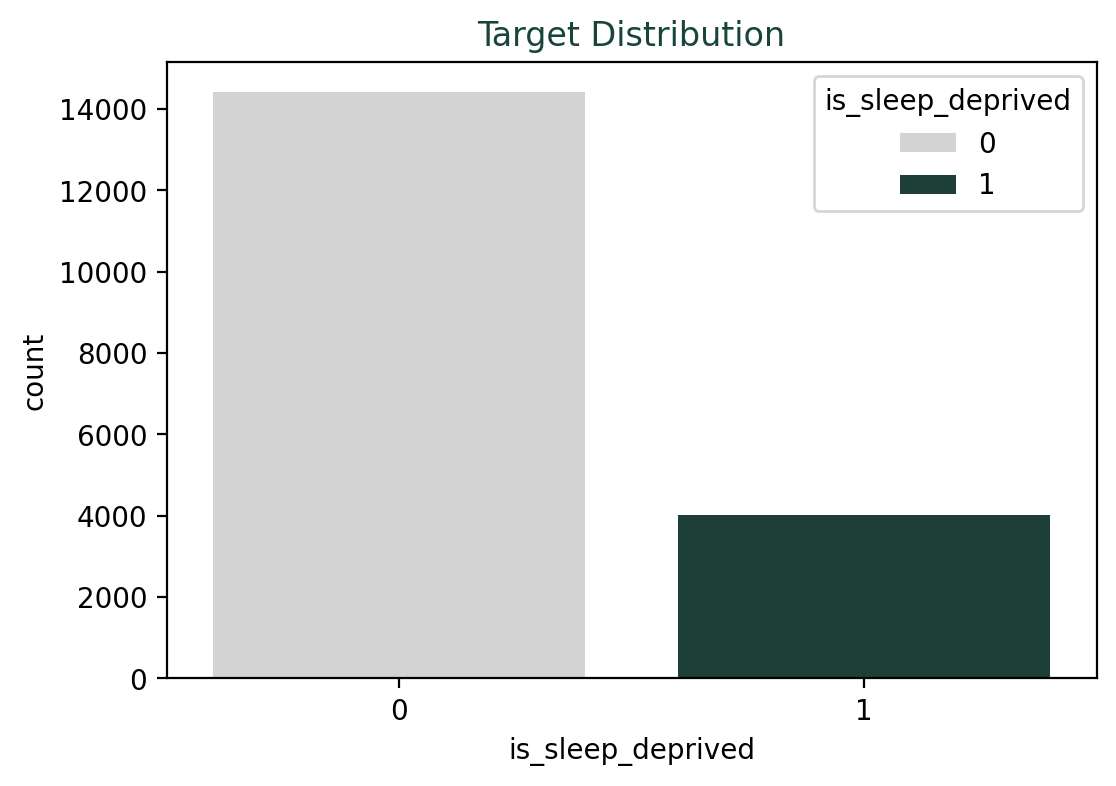

In [225]:
# 1.1 data structure
print(f"Rows: {X_selected.shape[0]}, Columns: {X_selected.shape[1]}")
print(f"Target:\n{y.value_counts()}")

# target dist
plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette=msu_colors)
plt.title('Target Distribution', color=msu_colors[1]) # fontweight='bold', 
plt.gca().set_facecolor('white')
plt.show()

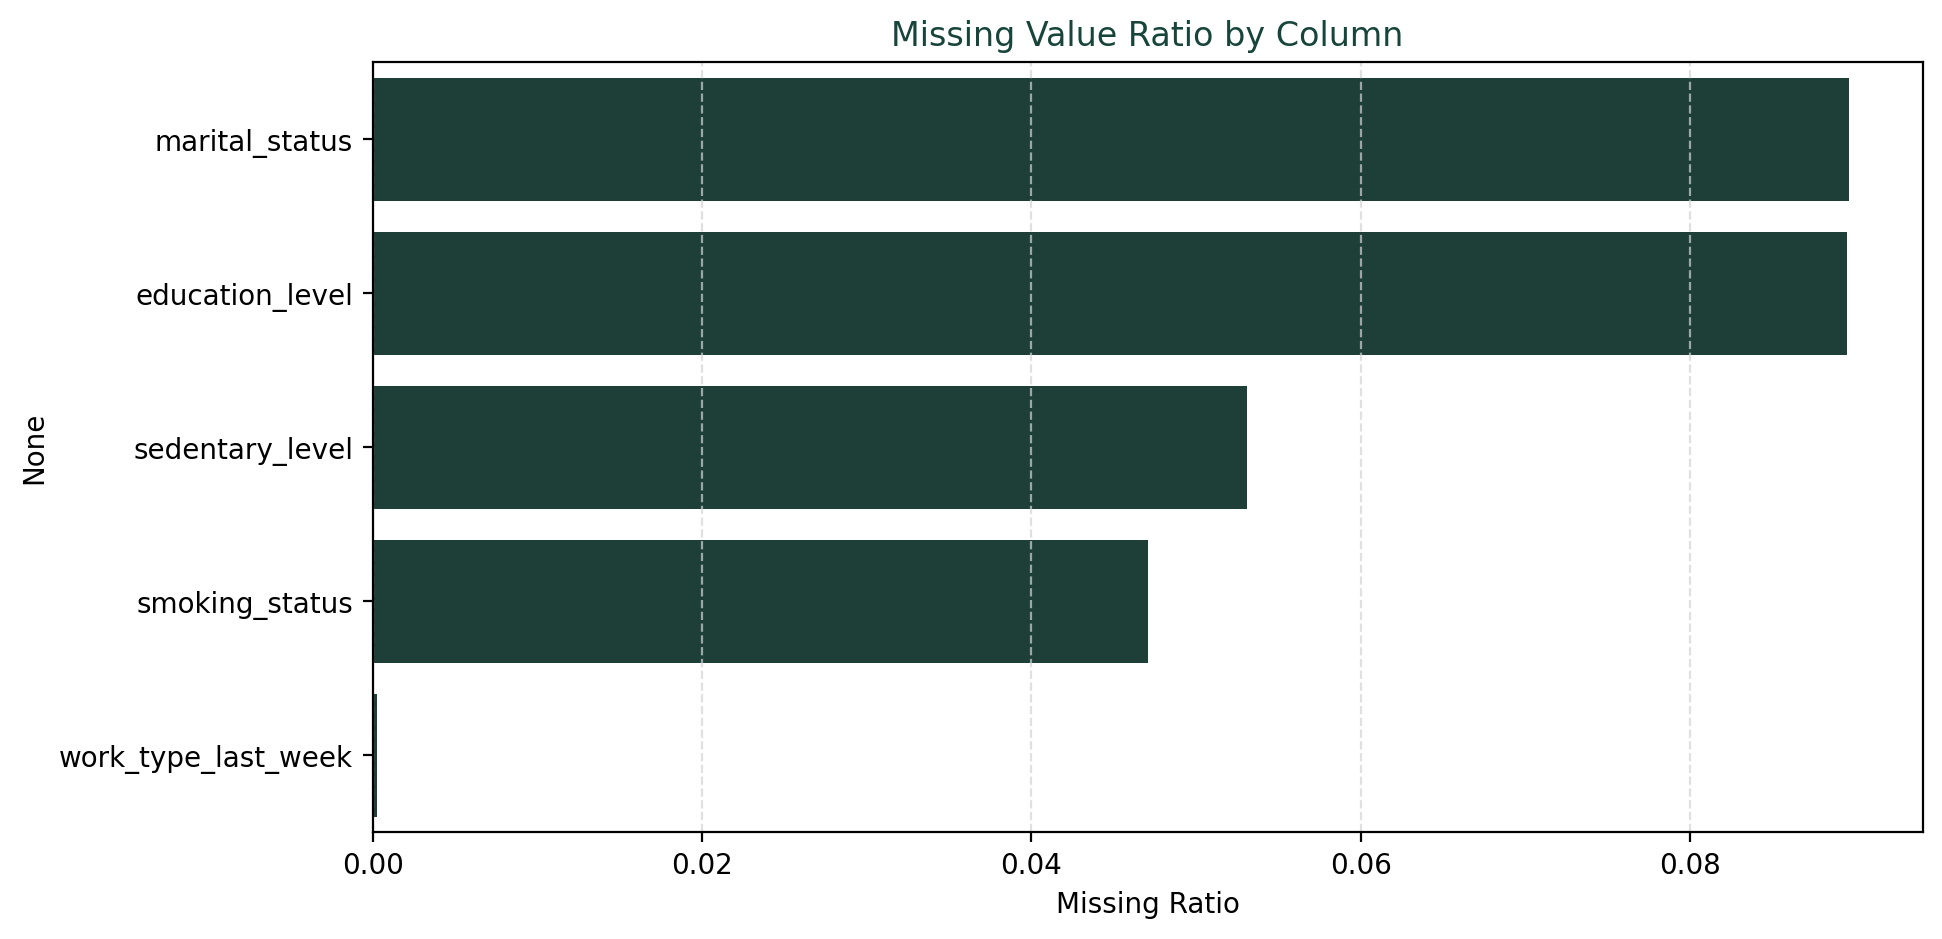

In [136]:
# 1.2 missing value
# missing value ratio by features
missing_ratio = X_selected.isna().mean().sort_values(ascending=False)
missing_ratio = missing_ratio[missing_ratio > 0] # cols with missing values

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_ratio.values, y=missing_ratio.index, color='#18453B')
plt.title('Missing Value Ratio by Column', color=msu_colors[1])#, fontweight='bold')
plt.xlabel('Missing Ratio')
plt.gca().xaxis.grid(True, linestyle='--', alpha=0.7, color=msu_colors[0])
plt.show()

## Numerical

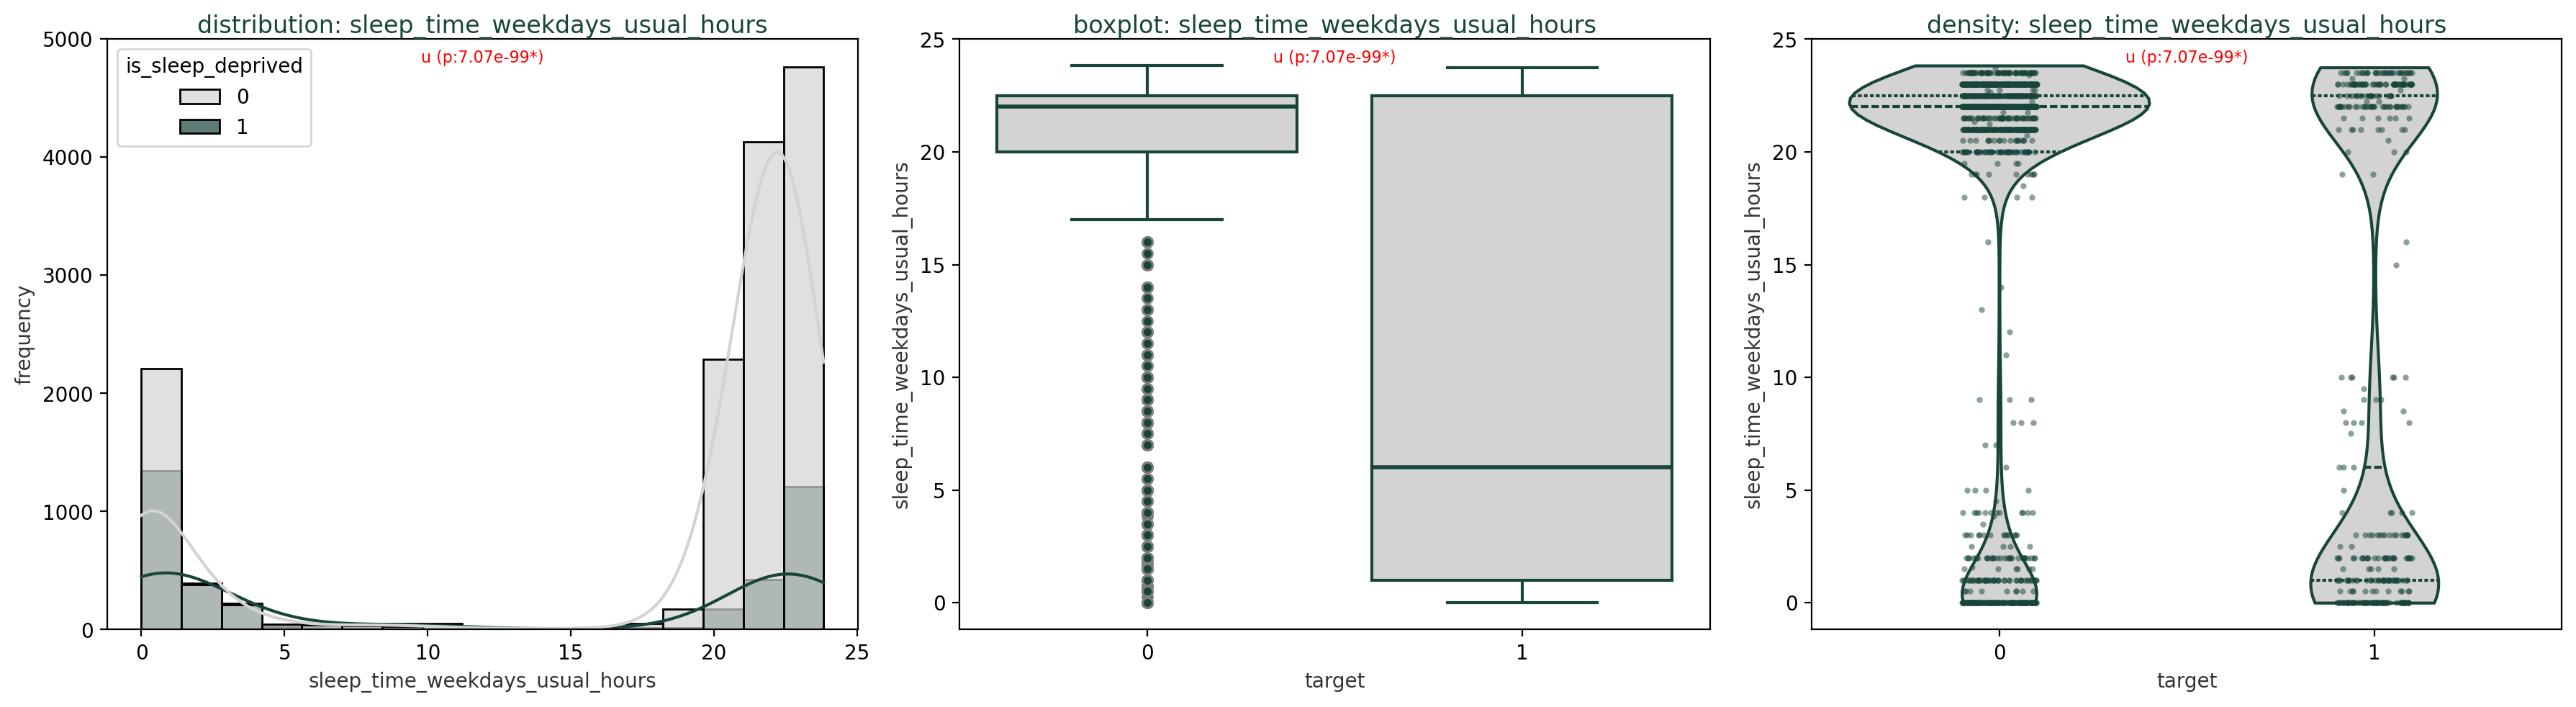

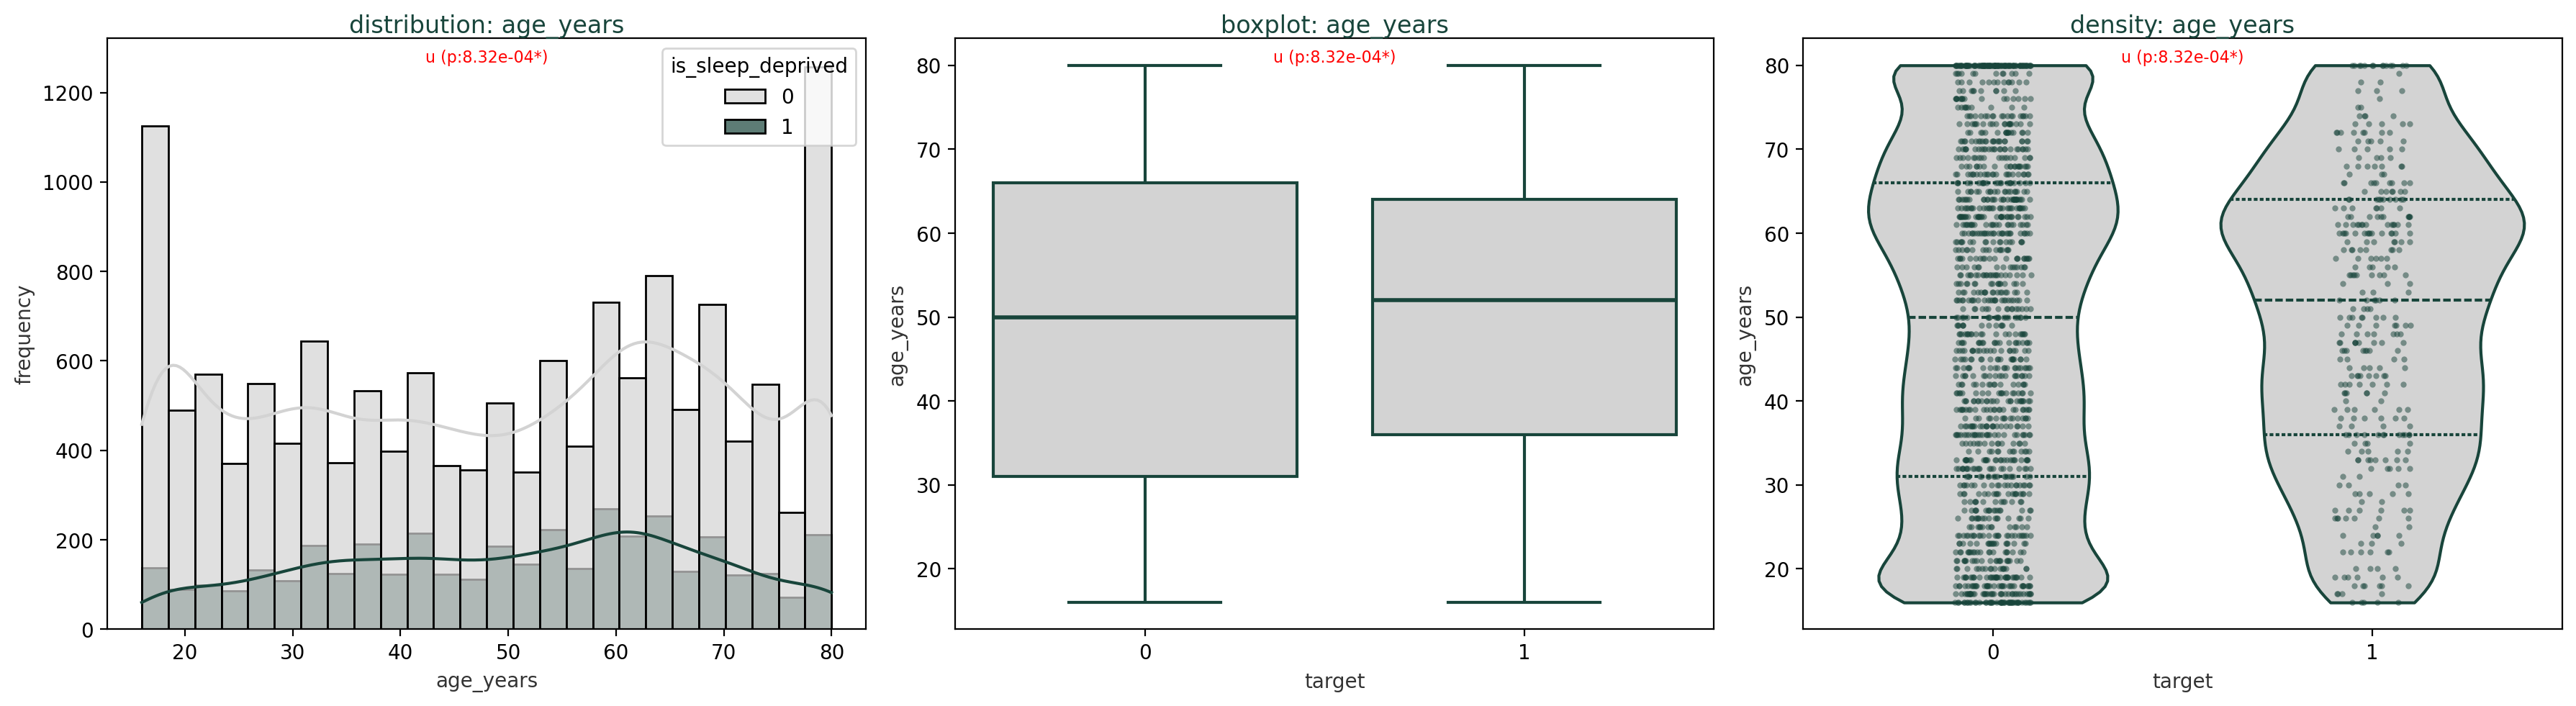

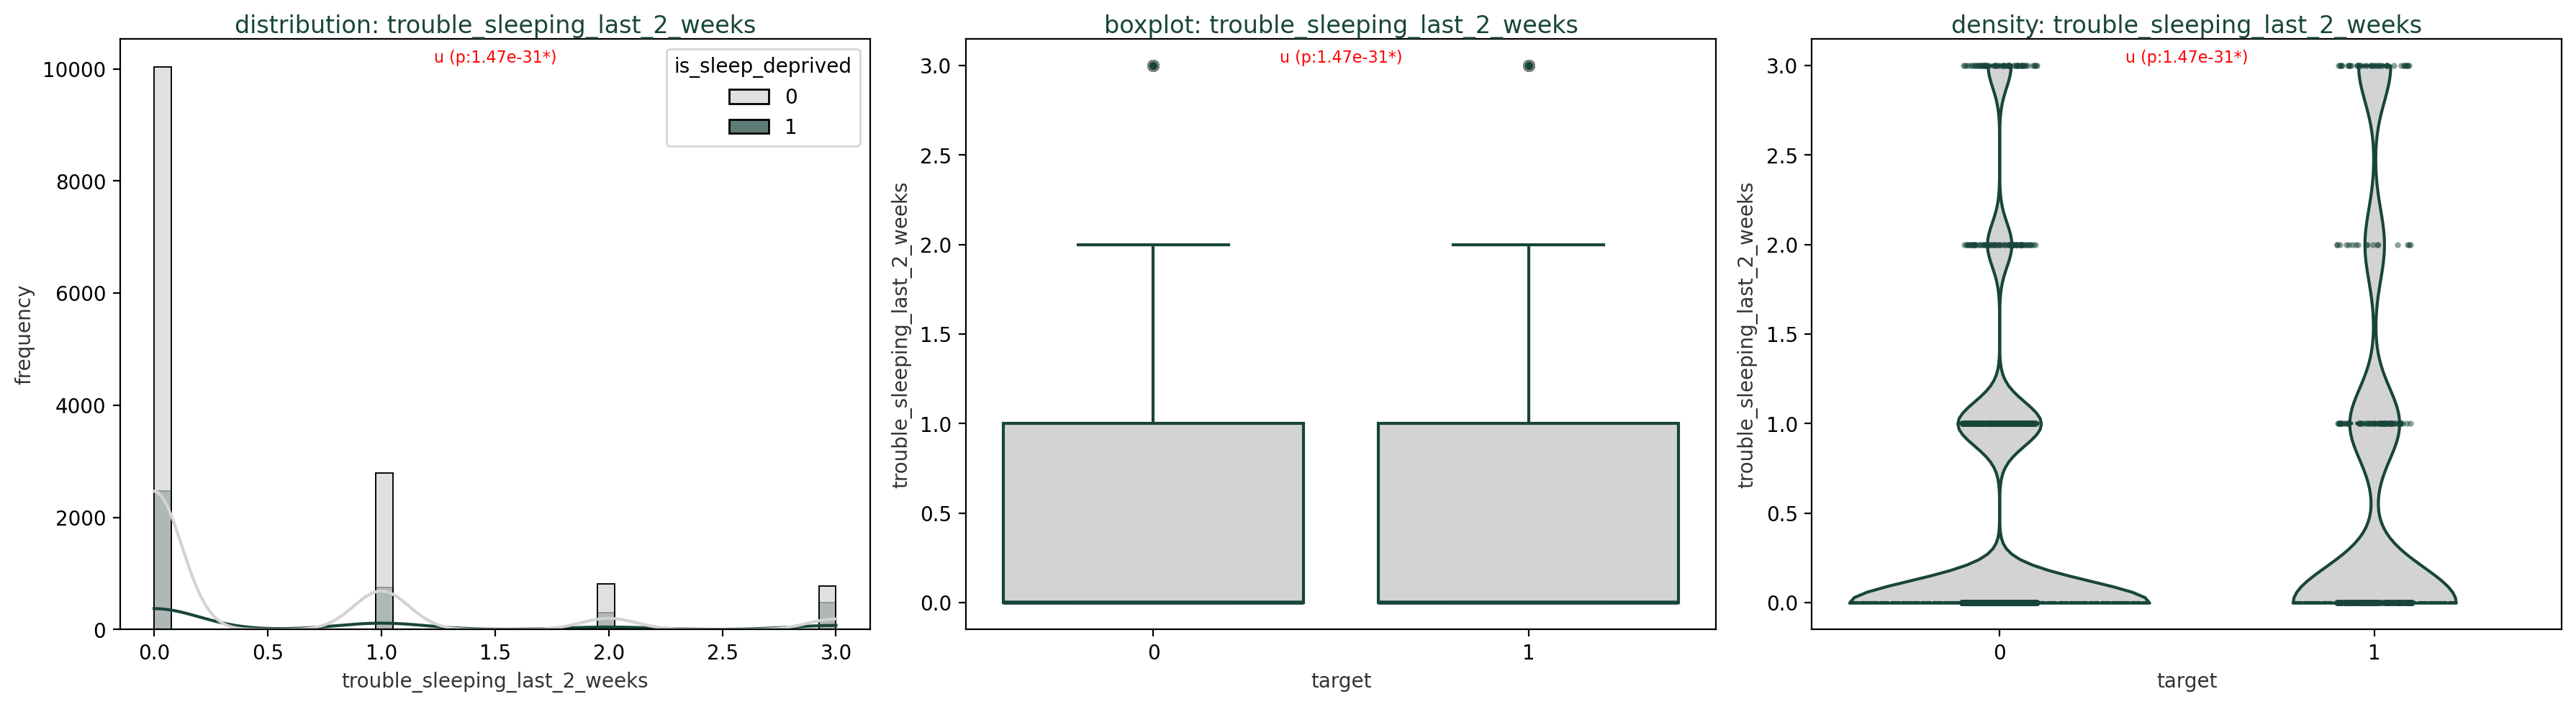

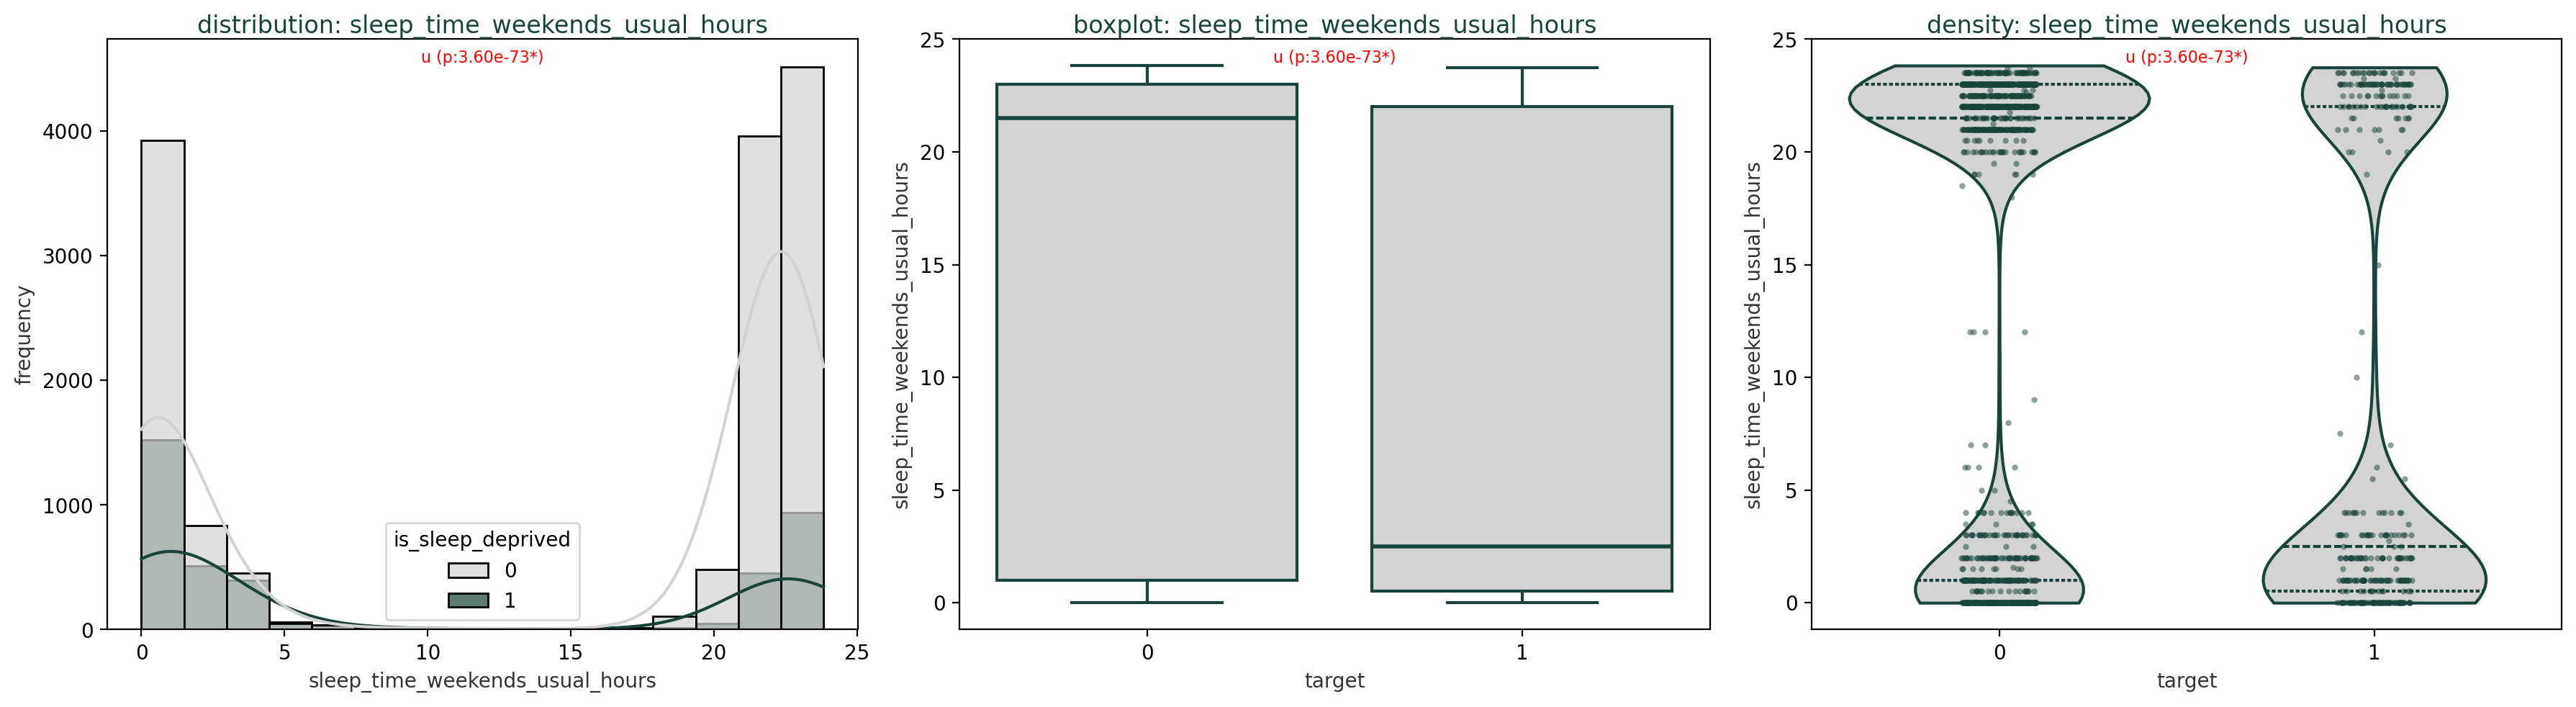

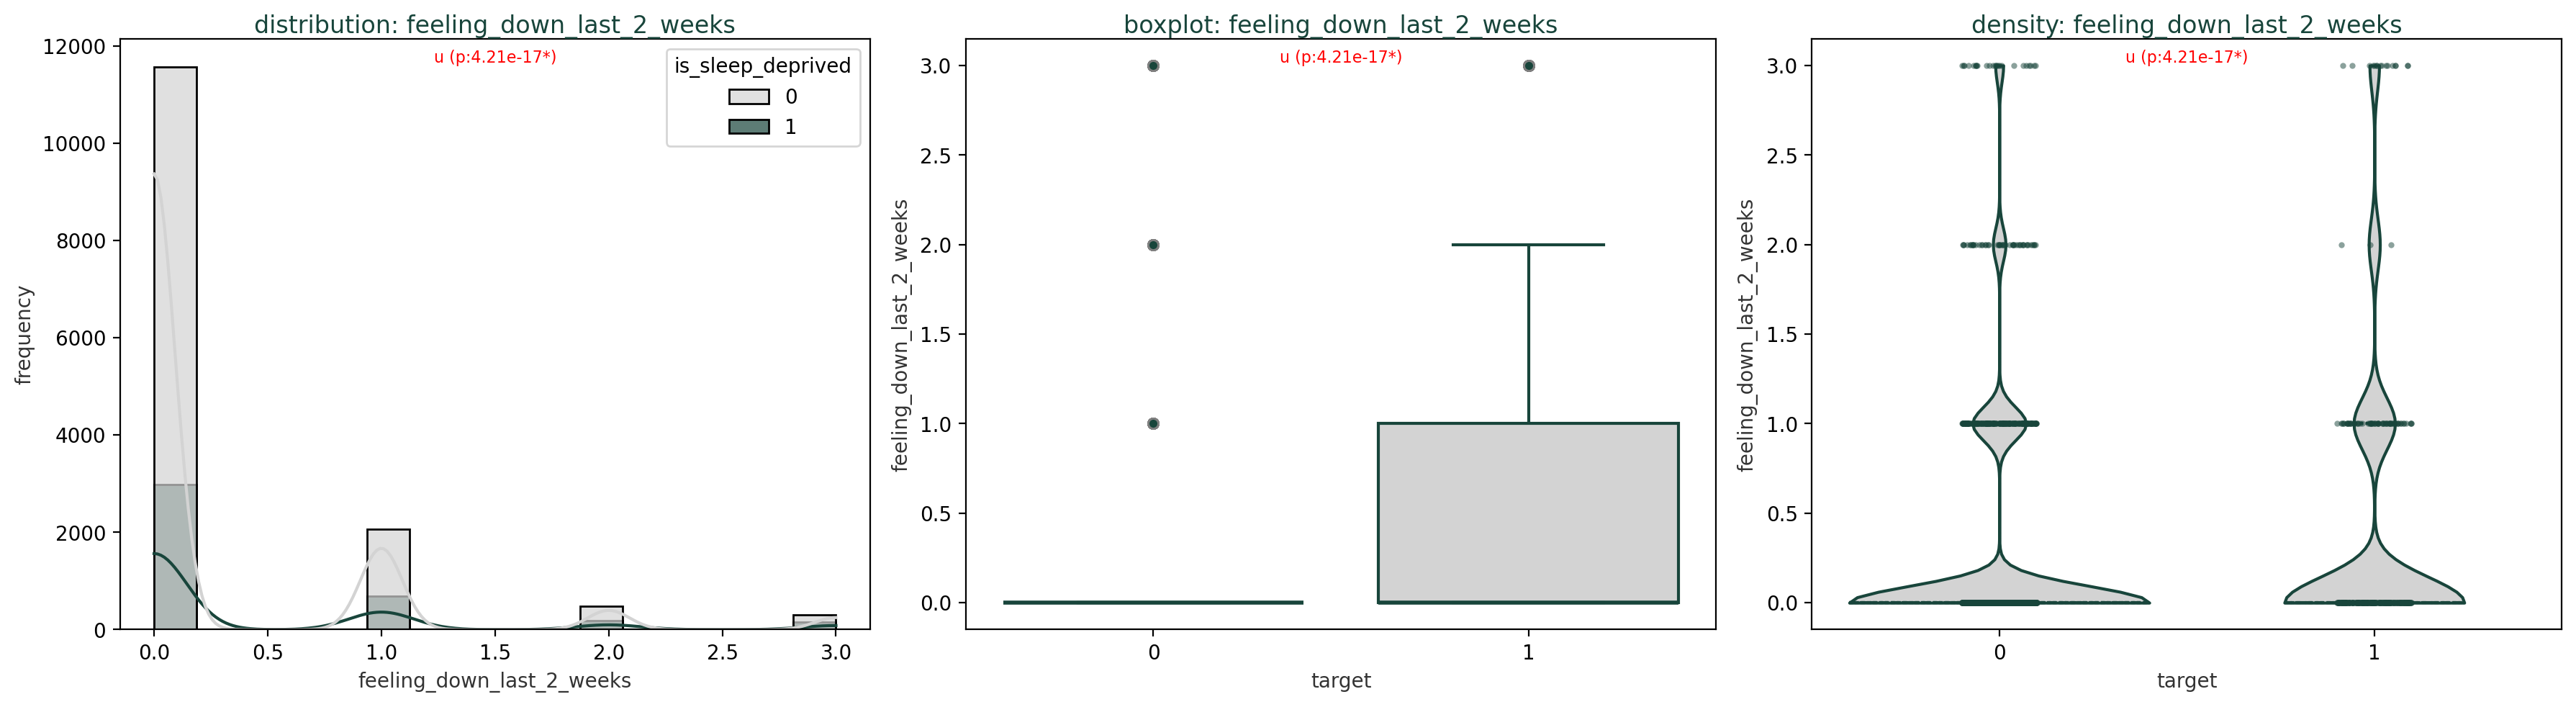

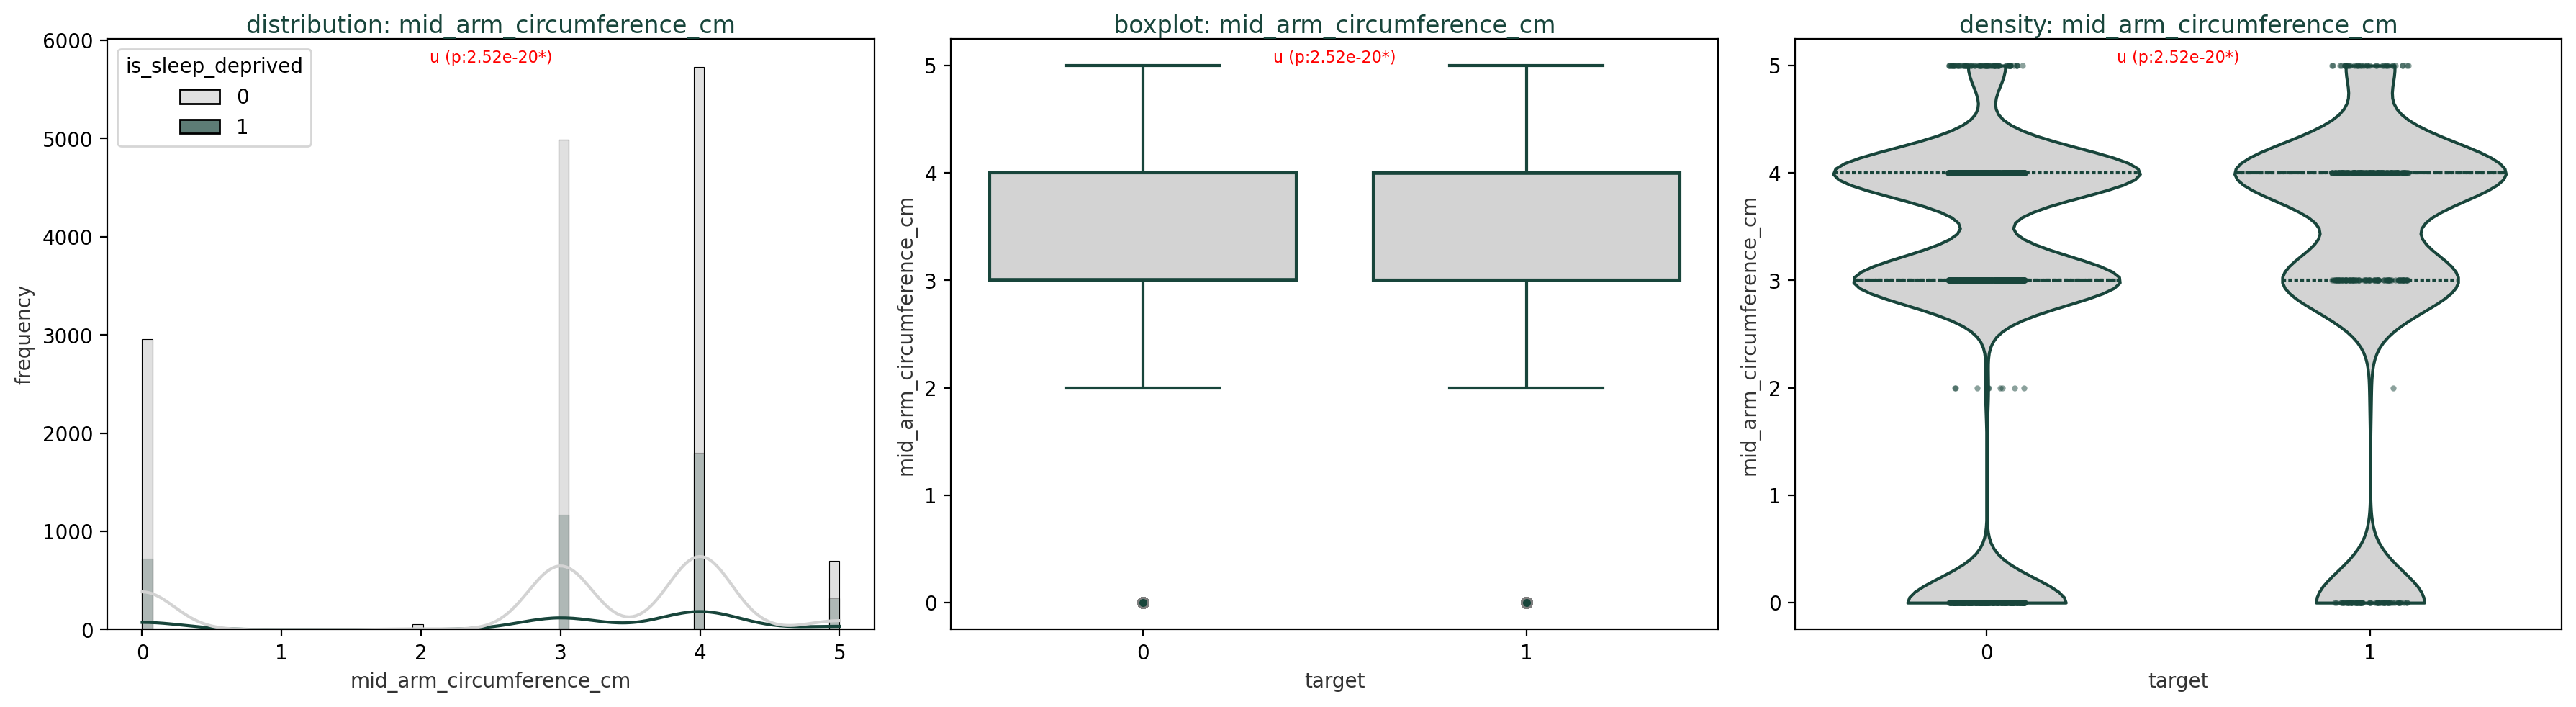

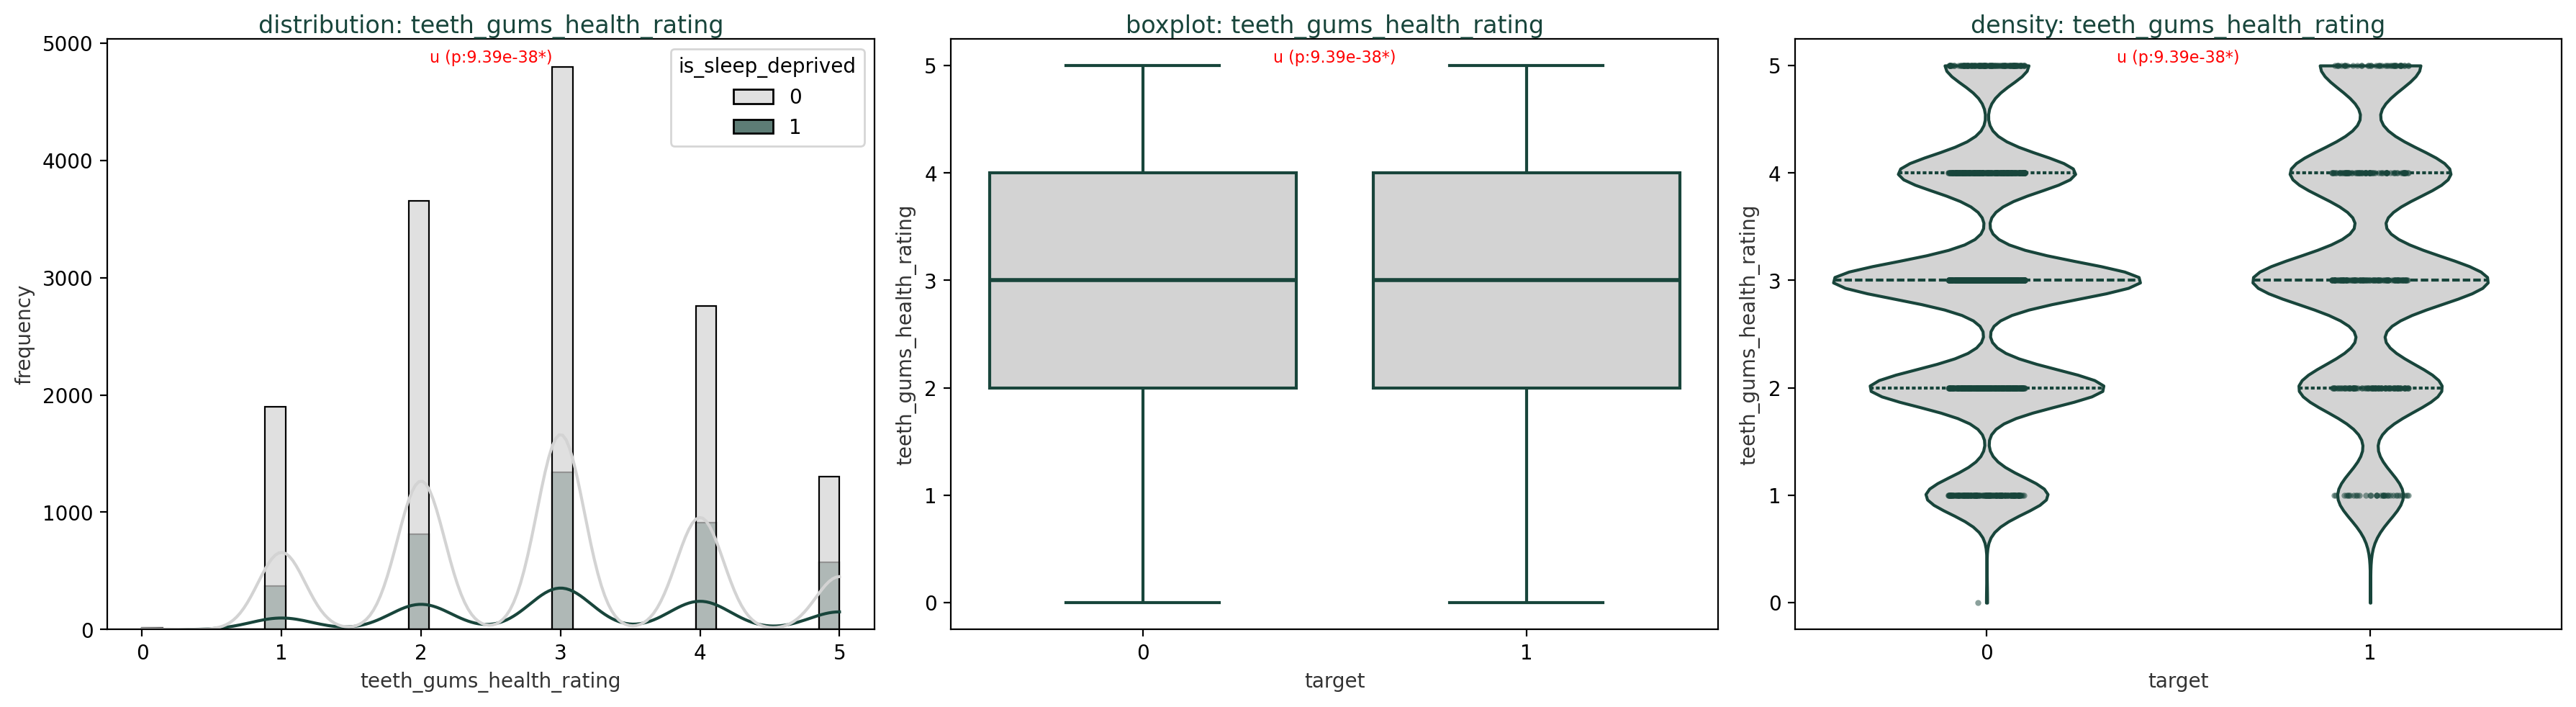

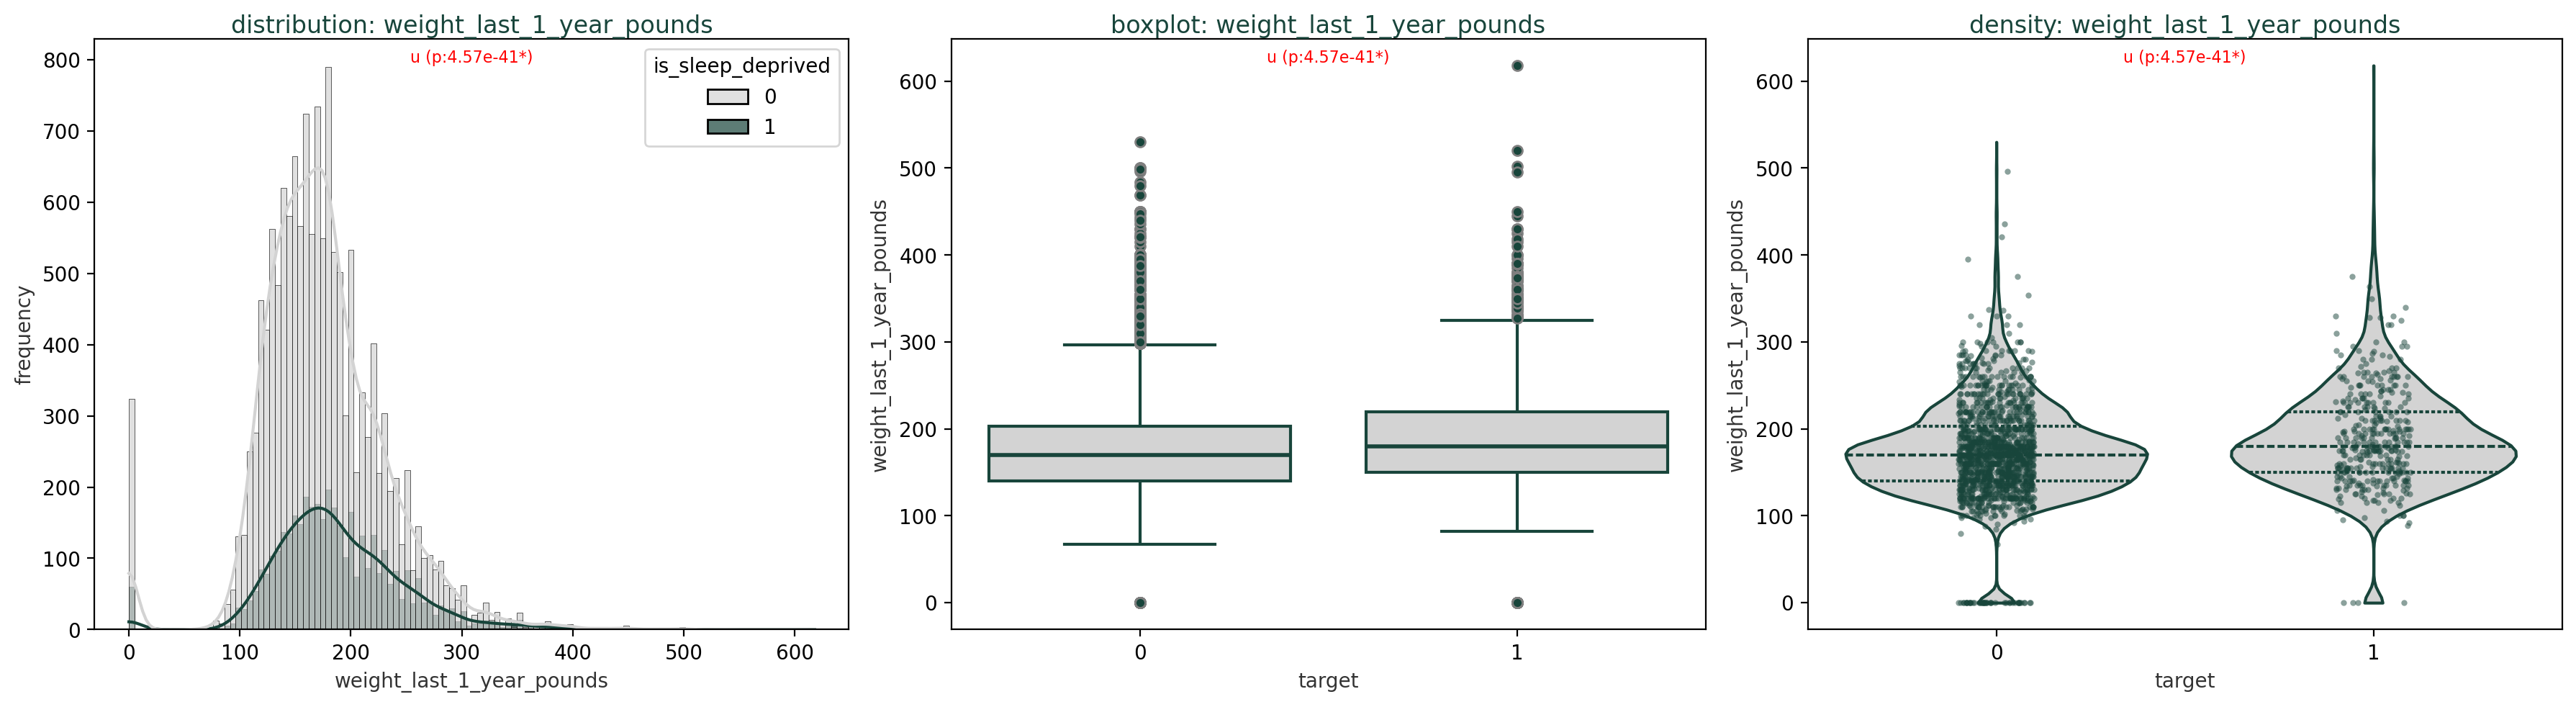

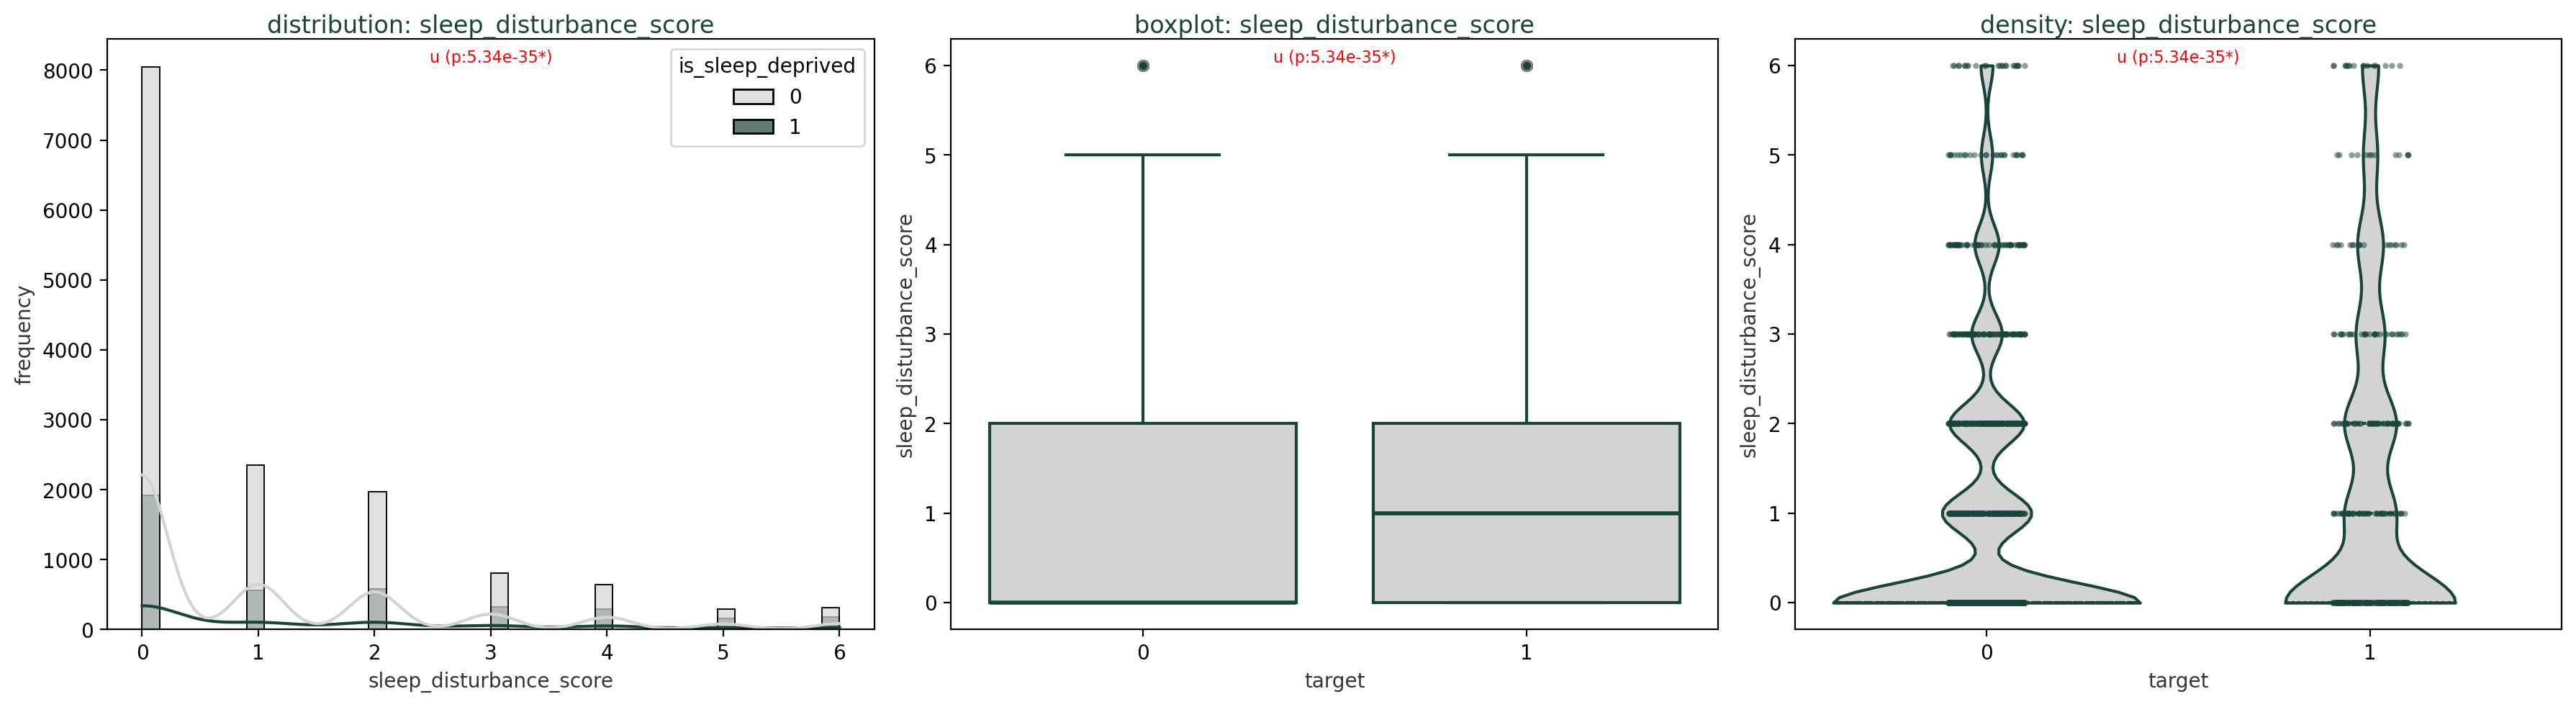

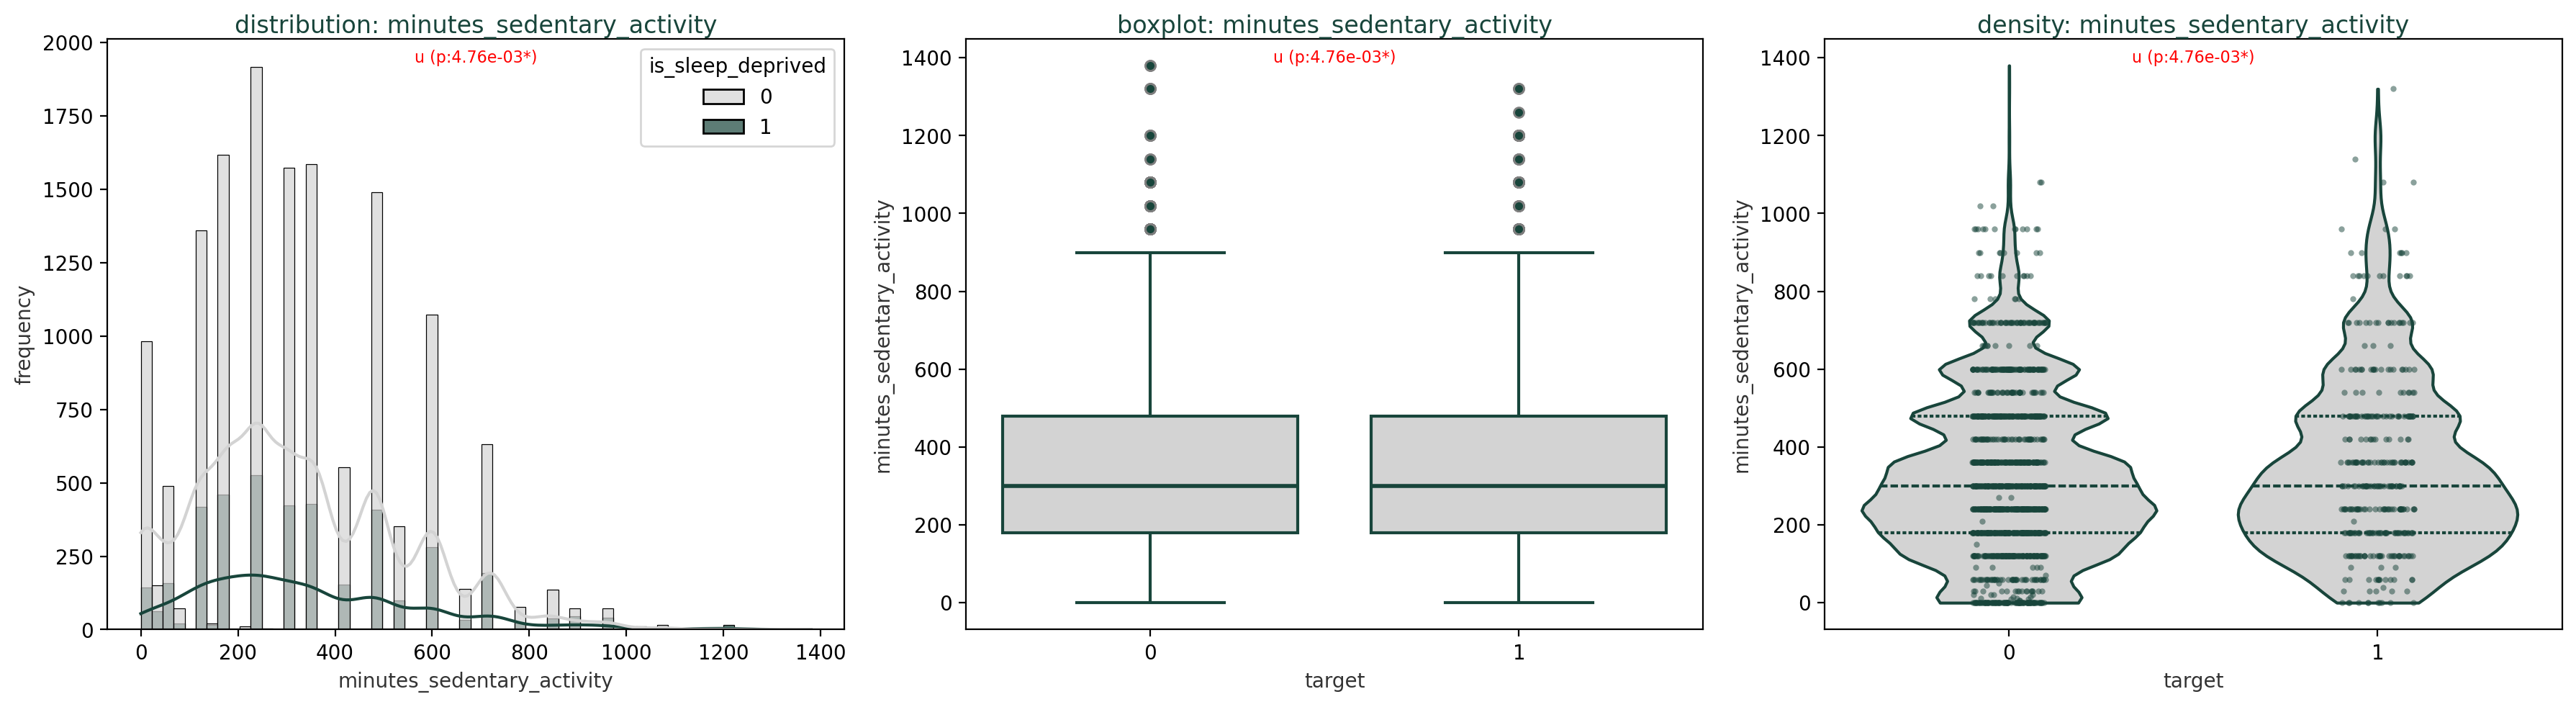

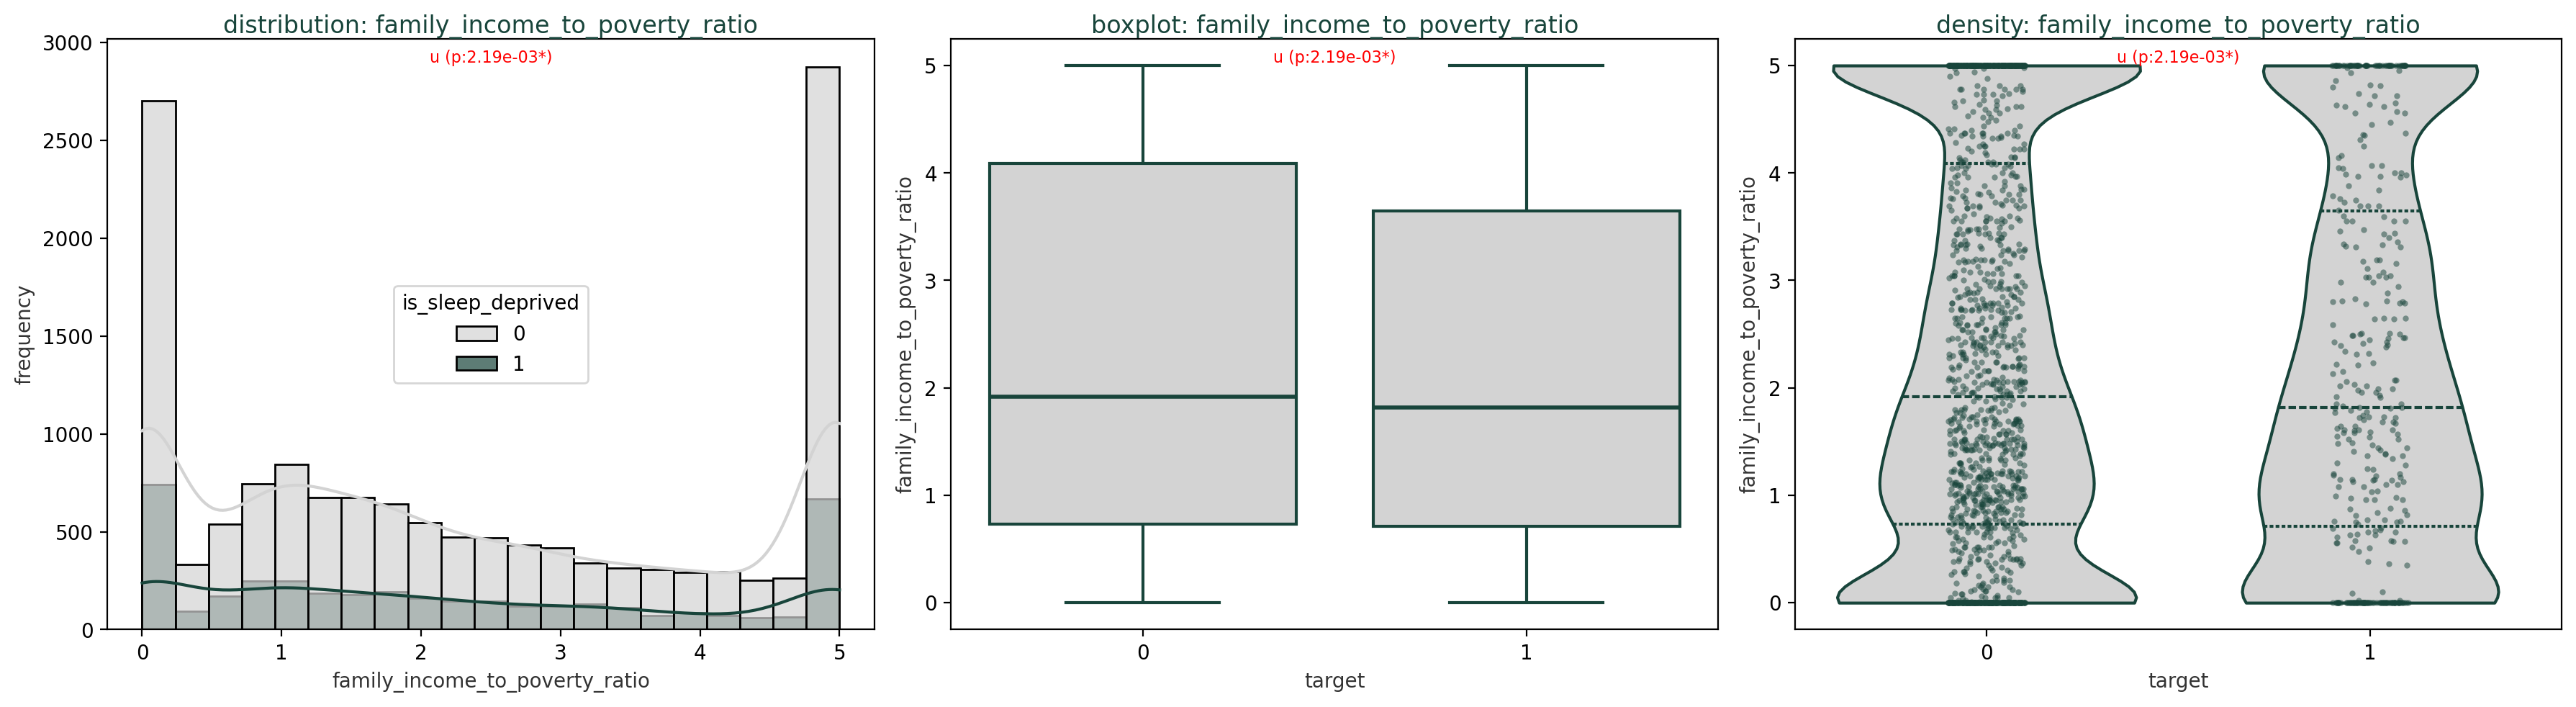

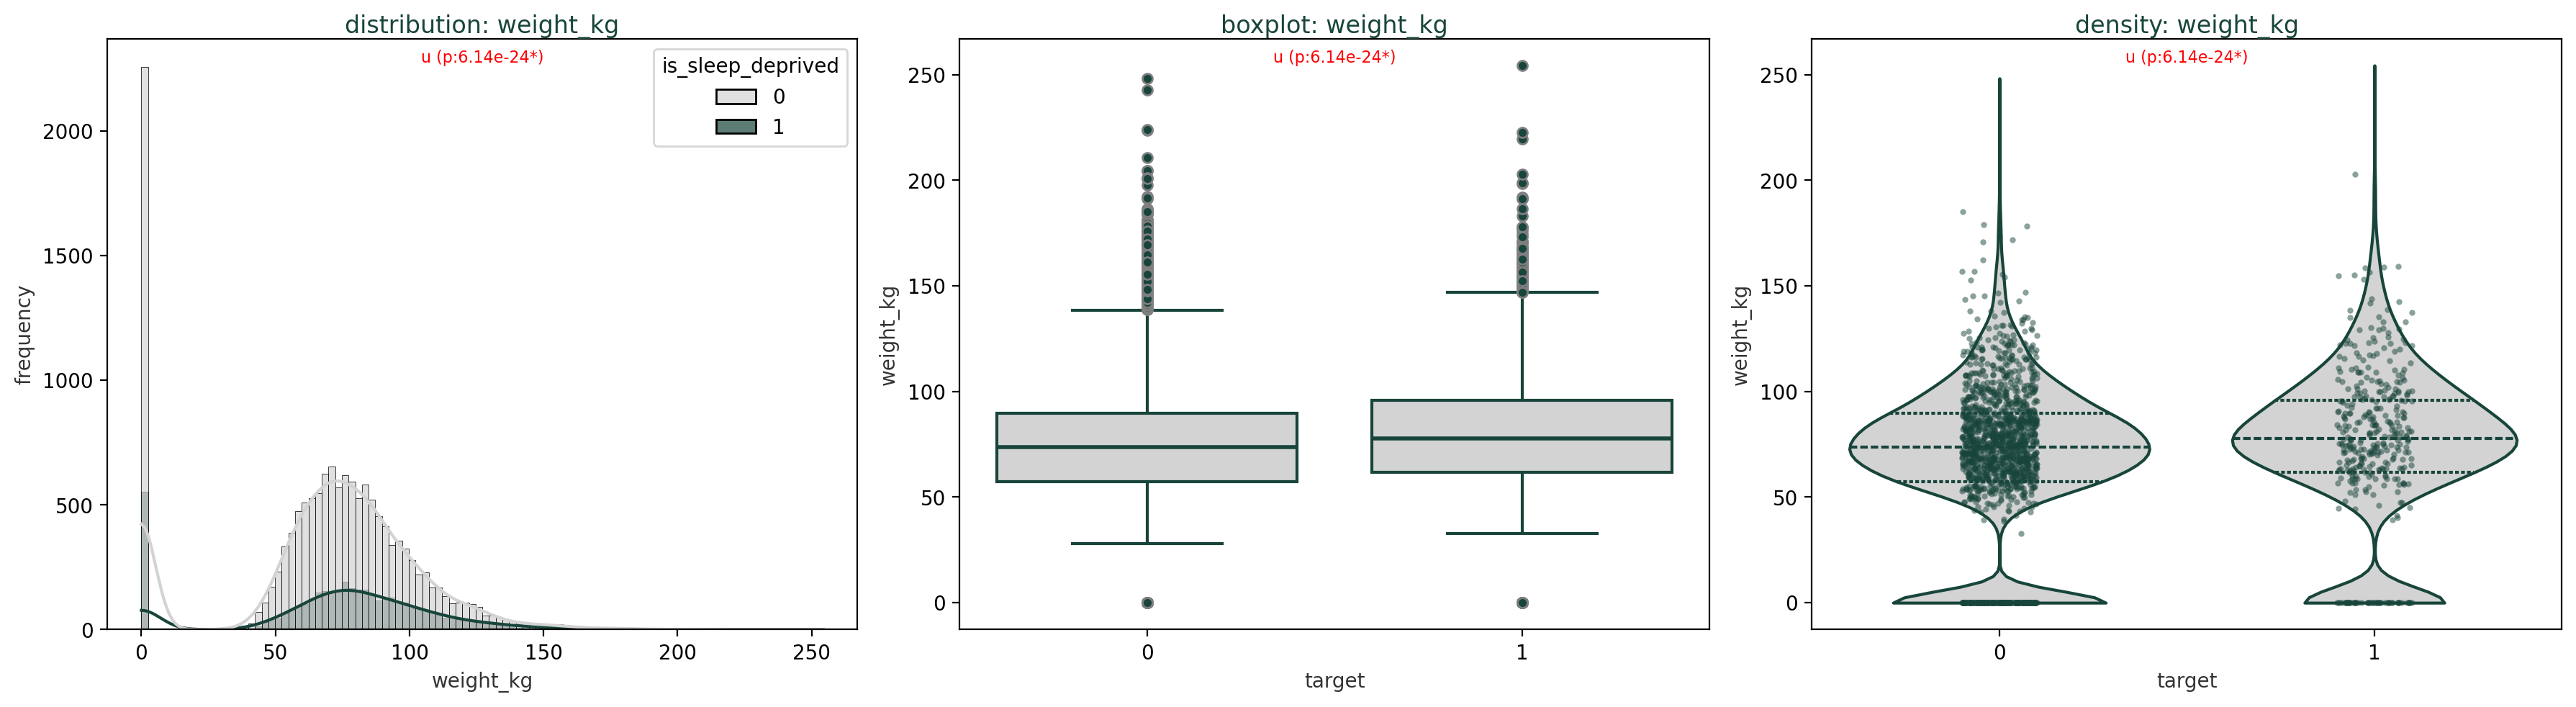

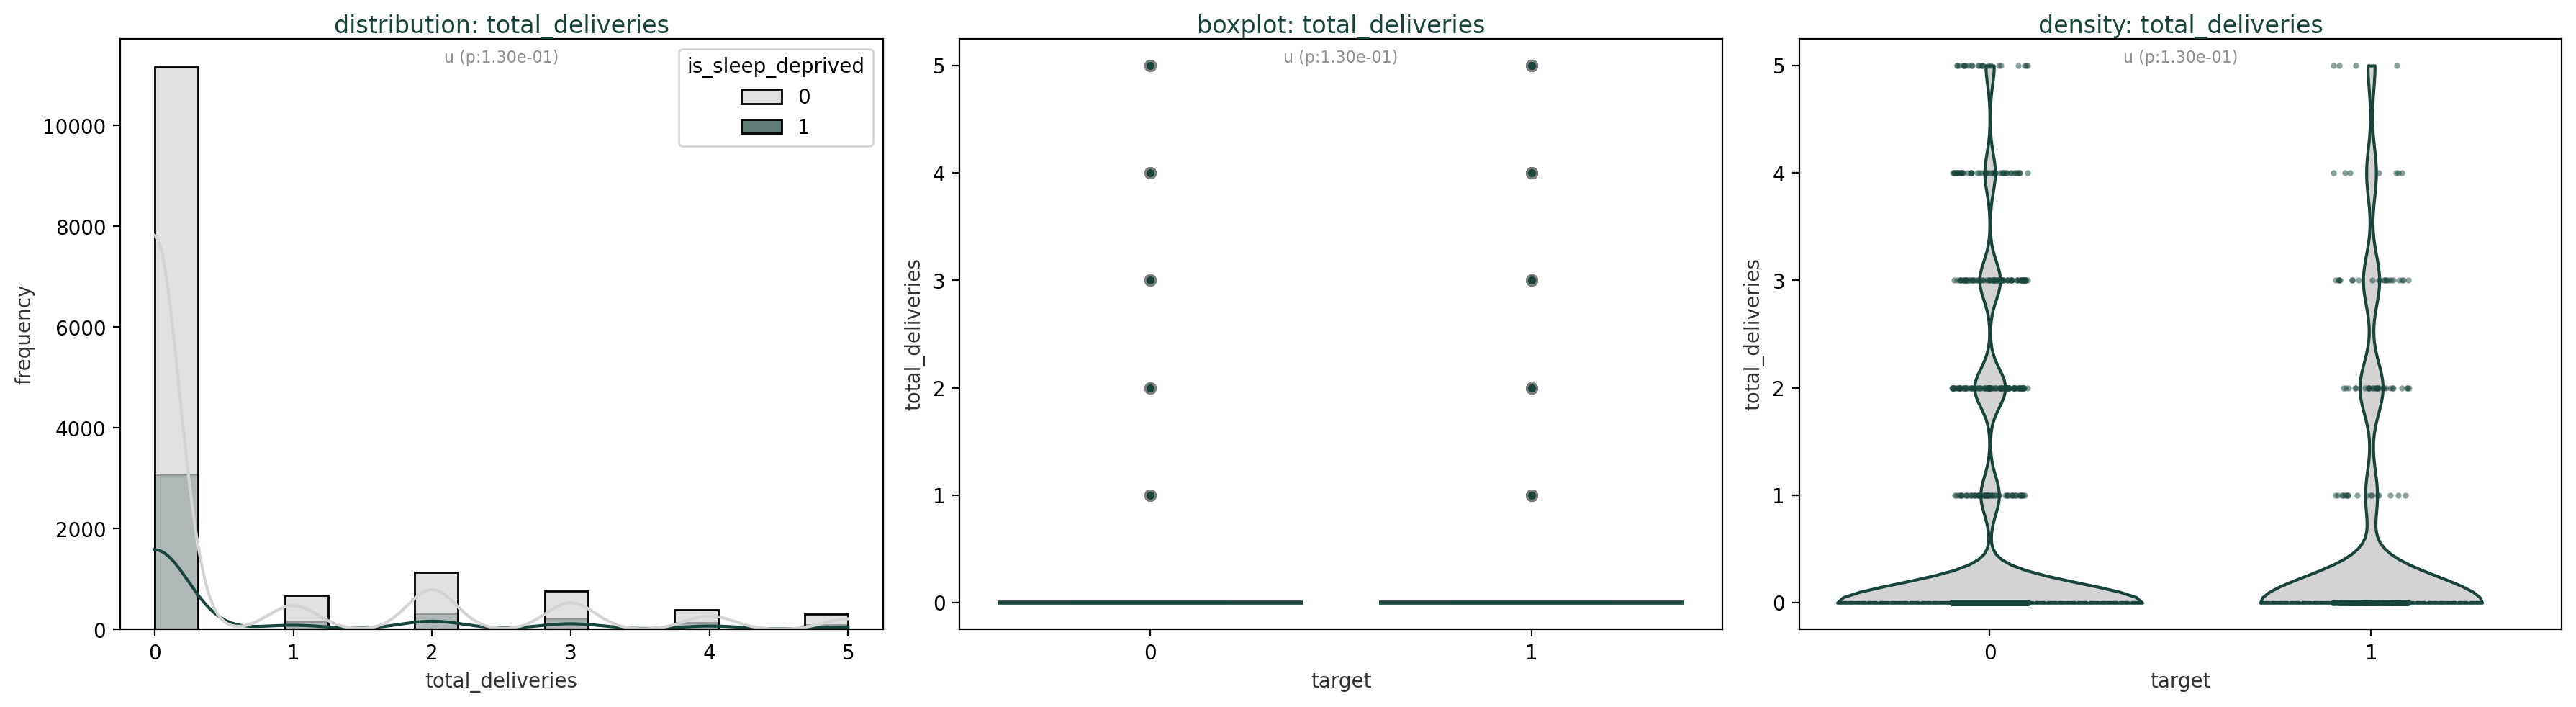

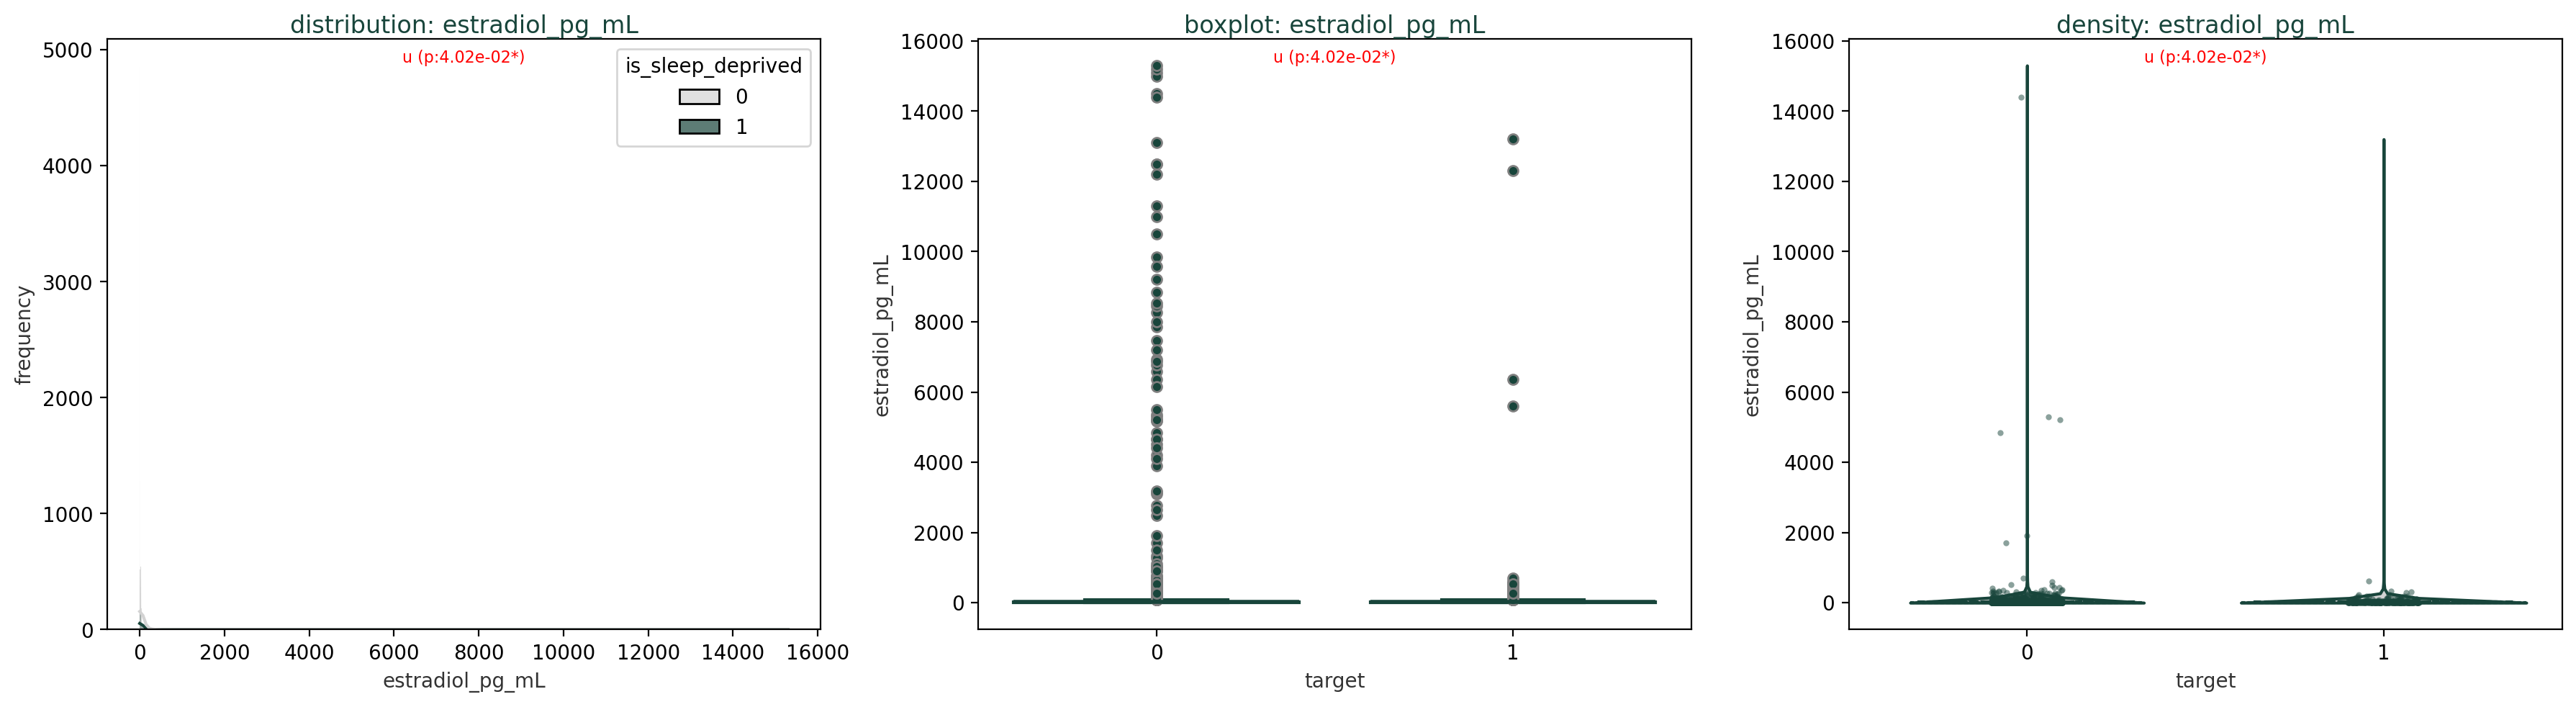

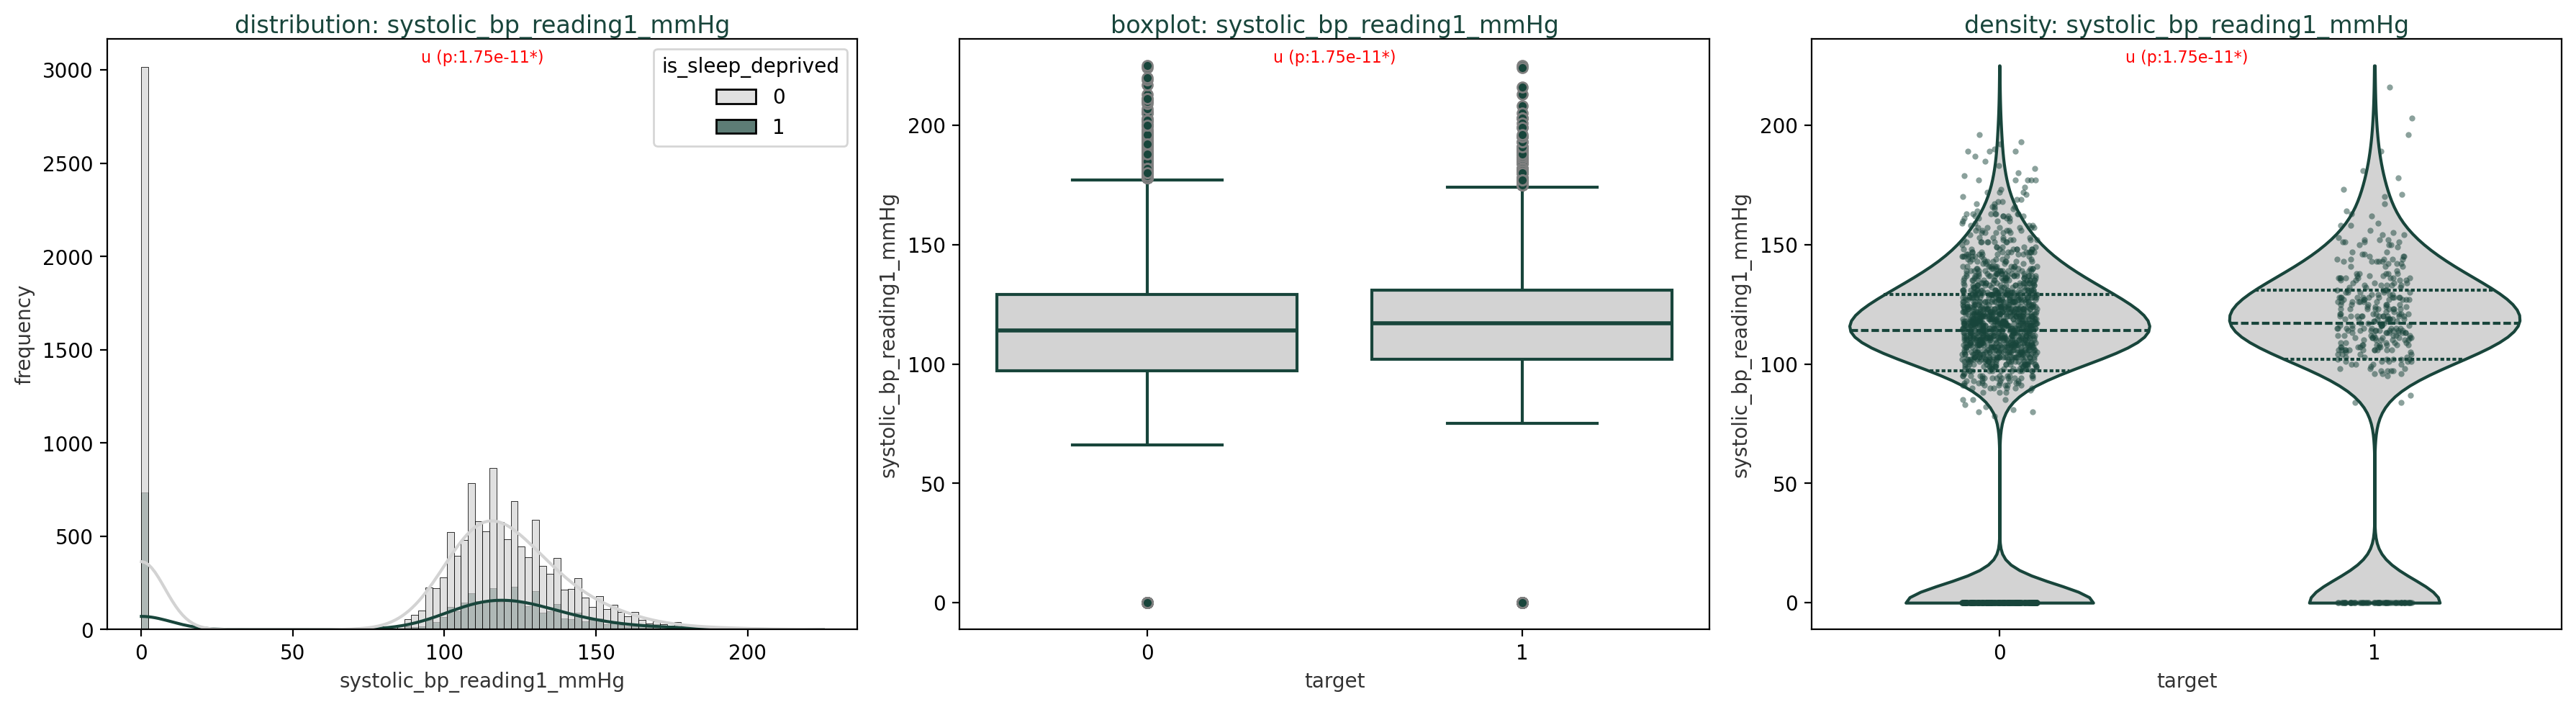

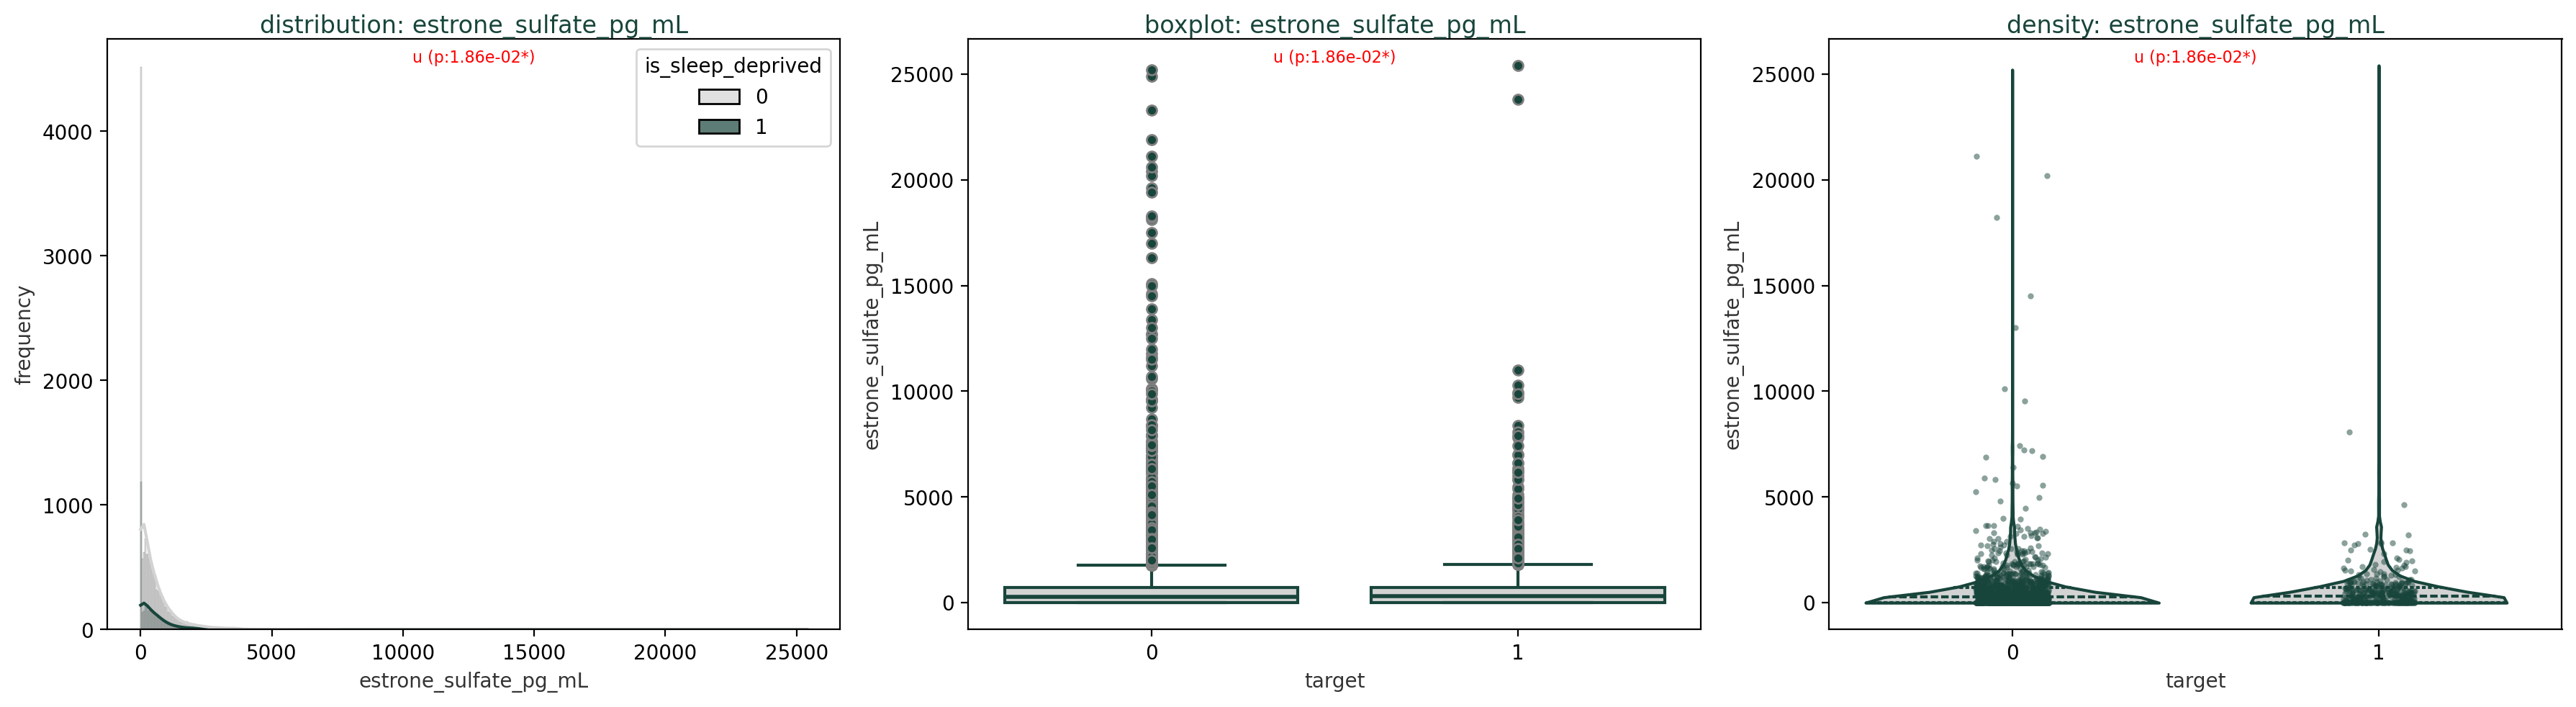

In [264]:
# 2.1 numerical cols

from scipy.stats import ttest_ind, mannwhitneyu, shapiro

for col in numerical_cols:
    # check for missing values
    if X_selected[col].isnull().any():
        missing_count = X_selected[col].isnull().sum()
        missing_ratio = missing_count / len(X_selected) * 100
        print(f"warning: {col} has {missing_count} missing values ({missing_ratio:.1f}%)")

    # create figure with 3 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # histogram + kde
    sns.histplot(data=X_selected, x=col, hue=y, kde=True, ax=ax1, 
                 palette=msu_colors, alpha=0.7, bins='auto')
    ax1.set_title(f'distribution: {col}', color=msu_colors[1], pad=0)
    ax1.set_xlabel(col, color='#333333')
    ax1.set_ylabel('frequency', color='#333333')

    # boxplot
    sns.boxplot(data=X_selected, x=y, y=col, ax=ax2, 
                boxprops=dict(facecolor=msu_colors[0], edgecolor=msu_colors[1], linewidth=1.5), # box
                medianprops=dict(color=msu_colors[1], linewidth=2),
                whiskerprops=dict(color=msu_colors[1], linewidth=1.5),
                capprops=dict(color=msu_colors[1], linewidth=1.5),
                flierprops=dict(markerfacecolor=msu_colors[1], markersize=5)) # flier/ball
    ax2.set_title(f'boxplot: {col}', color=msu_colors[1], pad=0)
    ax2.set_xlabel('target', color='#333333')
    ax2.set_ylabel(col, color='#333333')

    # violin + stripplot
    # using stripplot (instead of swarmplot; too much overlap)
    sns.violinplot(data=X_selected, x=y, y=col, ax=ax3,
                   color=msu_colors[0], inner='quartile',
                   linecolor=msu_colors[1], linewidth=1.5, cut=0)
    # sample stripplot for large datasets
    sample_data = X_selected.sample(frac=0.1, random_state=SEED) if len(X_selected) > 1000 else X_selected # if >1000 rows 10% sampling, alpha=0.5
    sns.stripplot(data=sample_data, x=y, y=col, ax=ax3,
                  color=msu_colors[1], size=3, alpha=0.5, jitter=True)
    ax3.set_title(f'density: {col}', color=msu_colors[1], pad=0)
    ax3.set_xlabel('target', color='#333333')
    ax3.set_ylabel(col, color='#333333')

    # t-test or mann-whitney u test
    group1 = X_selected[y == 1][col]
    group0 = X_selected[y == 0][col]
    try:
        # sample for shapiro test to avoid large N warning
        sample_size = min(1000, len(group1), len(group0))
        group1_sample = group1.sample(n=sample_size, random_state=SEED) if len(group1) > sample_size else group1
        group0_sample = group0.sample(n=sample_size, random_state=SEED) if len(group0) > sample_size else group0
        # check normality of class 1 and 0 with shapiro-wilk test
        _, p_norm1 = shapiro(group1_sample)
        _, p_norm0 = shapiro(group0_sample)
        is_normal = p_norm1 > 0.05 and p_norm0 > 0.05 # normal if p > 0.05
        # if normal: Welch's t-test, if non-normal: Mann-Whitney U
        if is_normal:
            # use t-test for normal data
            t_stat, p_val = ttest_ind(group1, group0, equal_var=False) # equal_var=False -> Welch’s t-test
            test_stat = t_stat
            test_name = 't'
        else:
            # use mann-whitney u for non-normal data
            _, p_val = mannwhitneyu(group1, group0, alternative='two-sided')
            test_stat = None
            test_name = 'u'
            
    except ValueError as e:
        print(f"error: statistical test failed for {col}: {e}")
        p_val = 1.0
        test_stat = 0.0
        test_name = 't'

    # annotate statistical test result
    # if significant difference (p<0.05), highlihght it red
    p_text = f'{test_name}:{test_stat:.2f} (p:{p_val:.2e}' + ('*)' if p_val < 0.05 else ')') if test_name == 't' else f'{test_name} (p:{p_val:.2e}' + ('*)' if p_val < 0.05 else ')')
    for ax in [ax1, ax2, ax3]:
        ax.text(
            0.5, 0.96, p_text,
            transform=ax.transAxes,
            color='red' if p_val < 0.05 else '#909090',
            ha='center', fontsize=8
        )

    plt.tight_layout()
    plt.show()

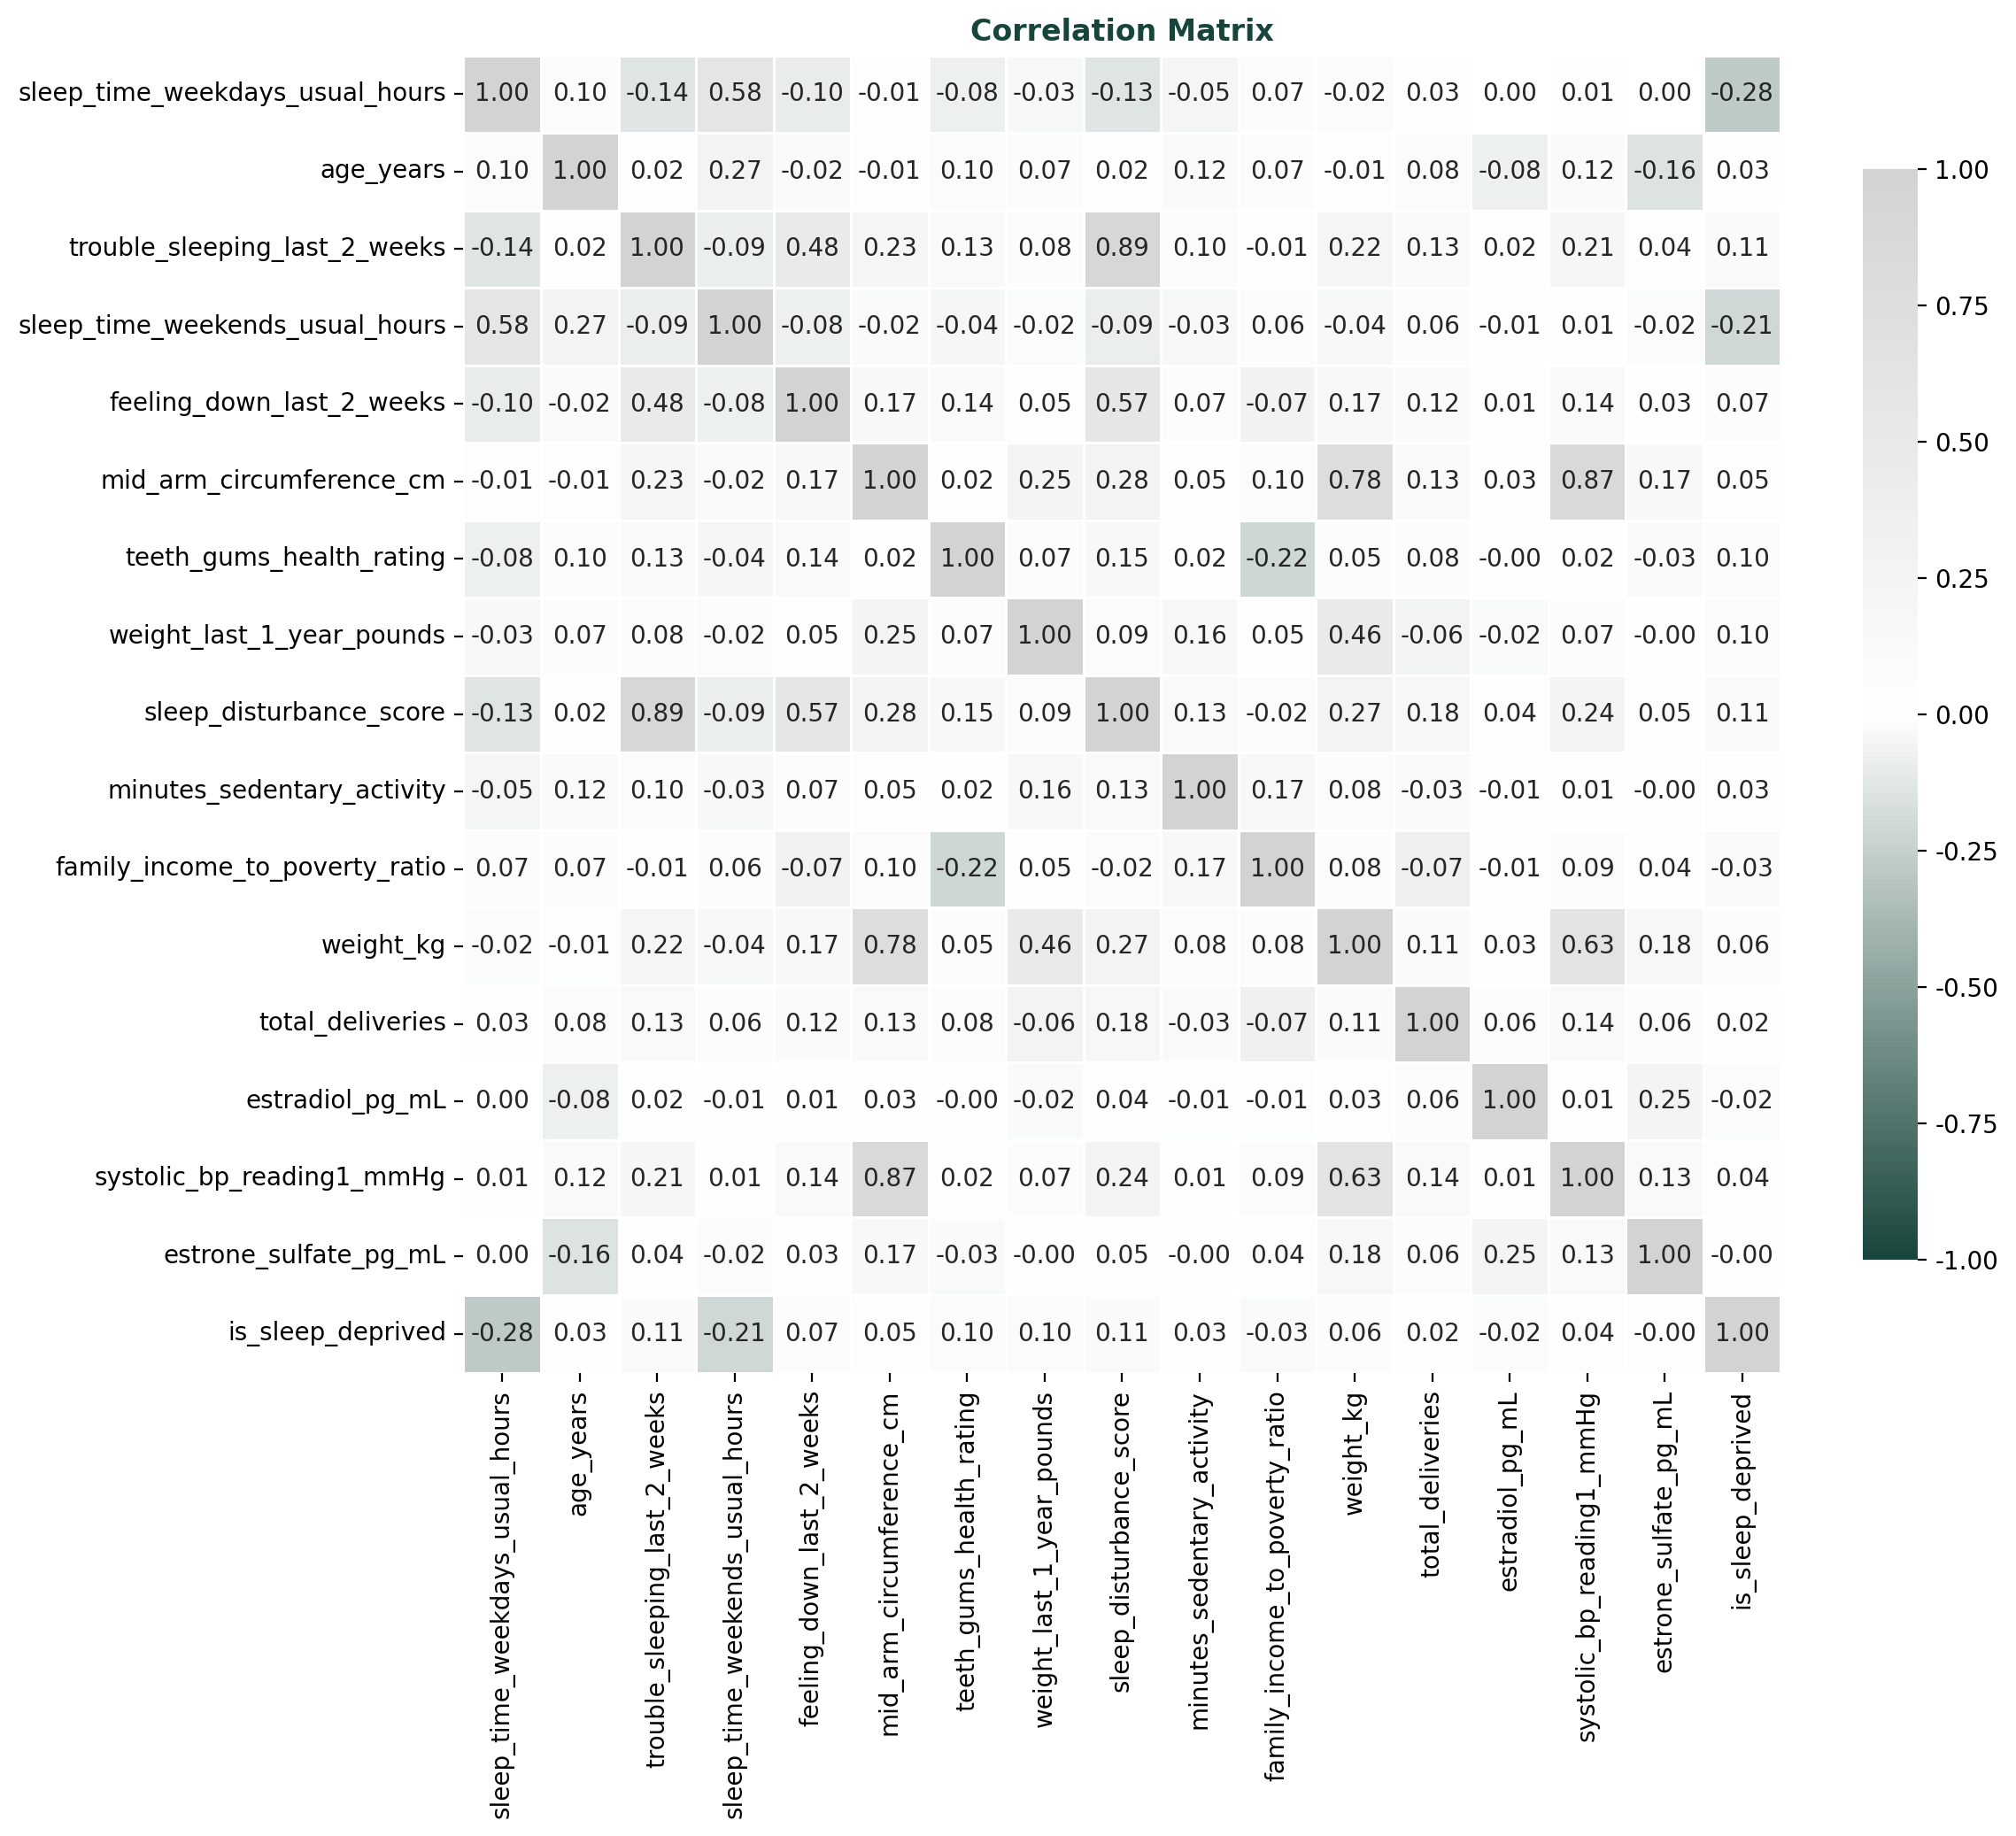

In [138]:
# 2.2 correlation (numeric)
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(12, 10), facecolor='white')
corr = pd.concat([X_selected[numerical_cols], y], axis=1).corr()

# set color map: spartan green → white → light gray
colors = [msu_colors[1], "#FFFFFF", msu_colors[0]]
# msu_cmap = sns.light_palette("#18453B", as_cmap=True)
# msu_cmap = sns.color_palette(colors, as_cmap=True)
msu_cmap = LinearSegmentedColormap.from_list("msu_cmap", colors, N=256)

sns.heatmap(corr, annot=True, cmap=msu_cmap, fmt='.2f', 
            linewidths=0.5, vmin=-1, vmax=1, center=0, #linecolor='#18453B', 
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontweight='bold', color=msu_colors[1])
plt.show()

## Categorical

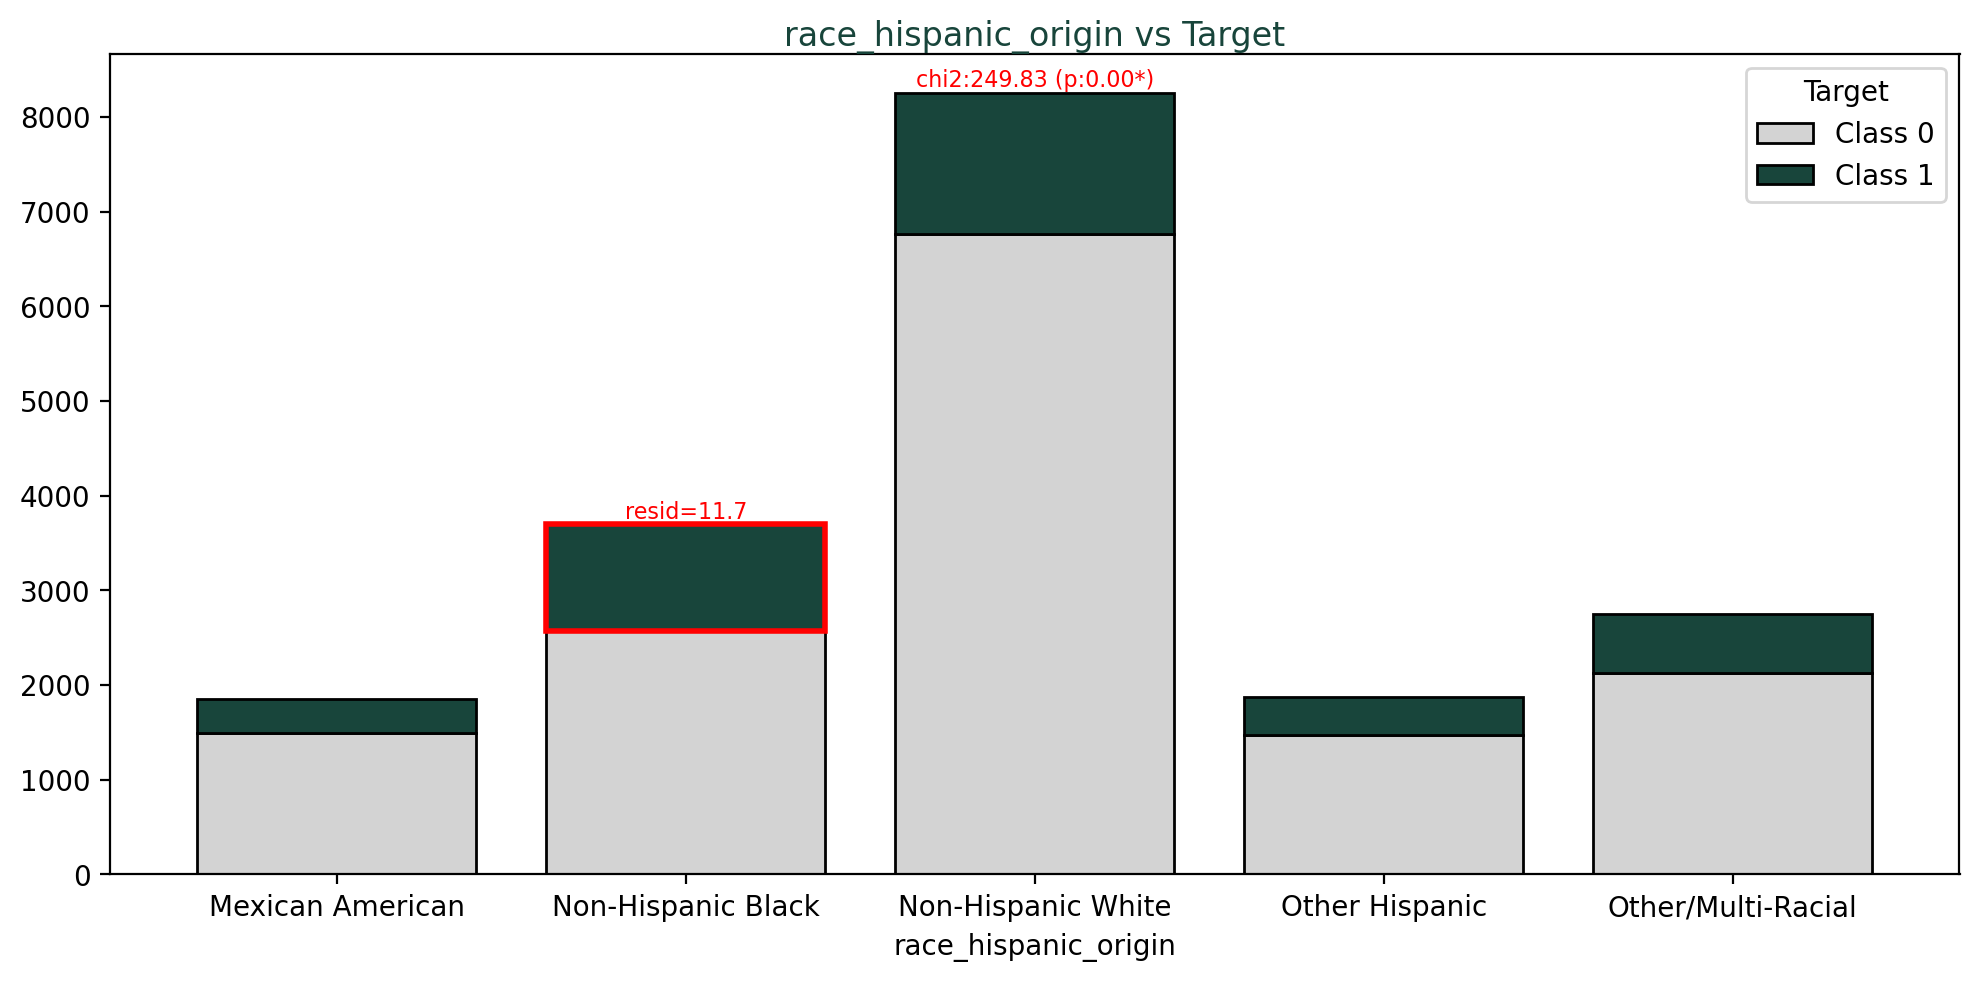

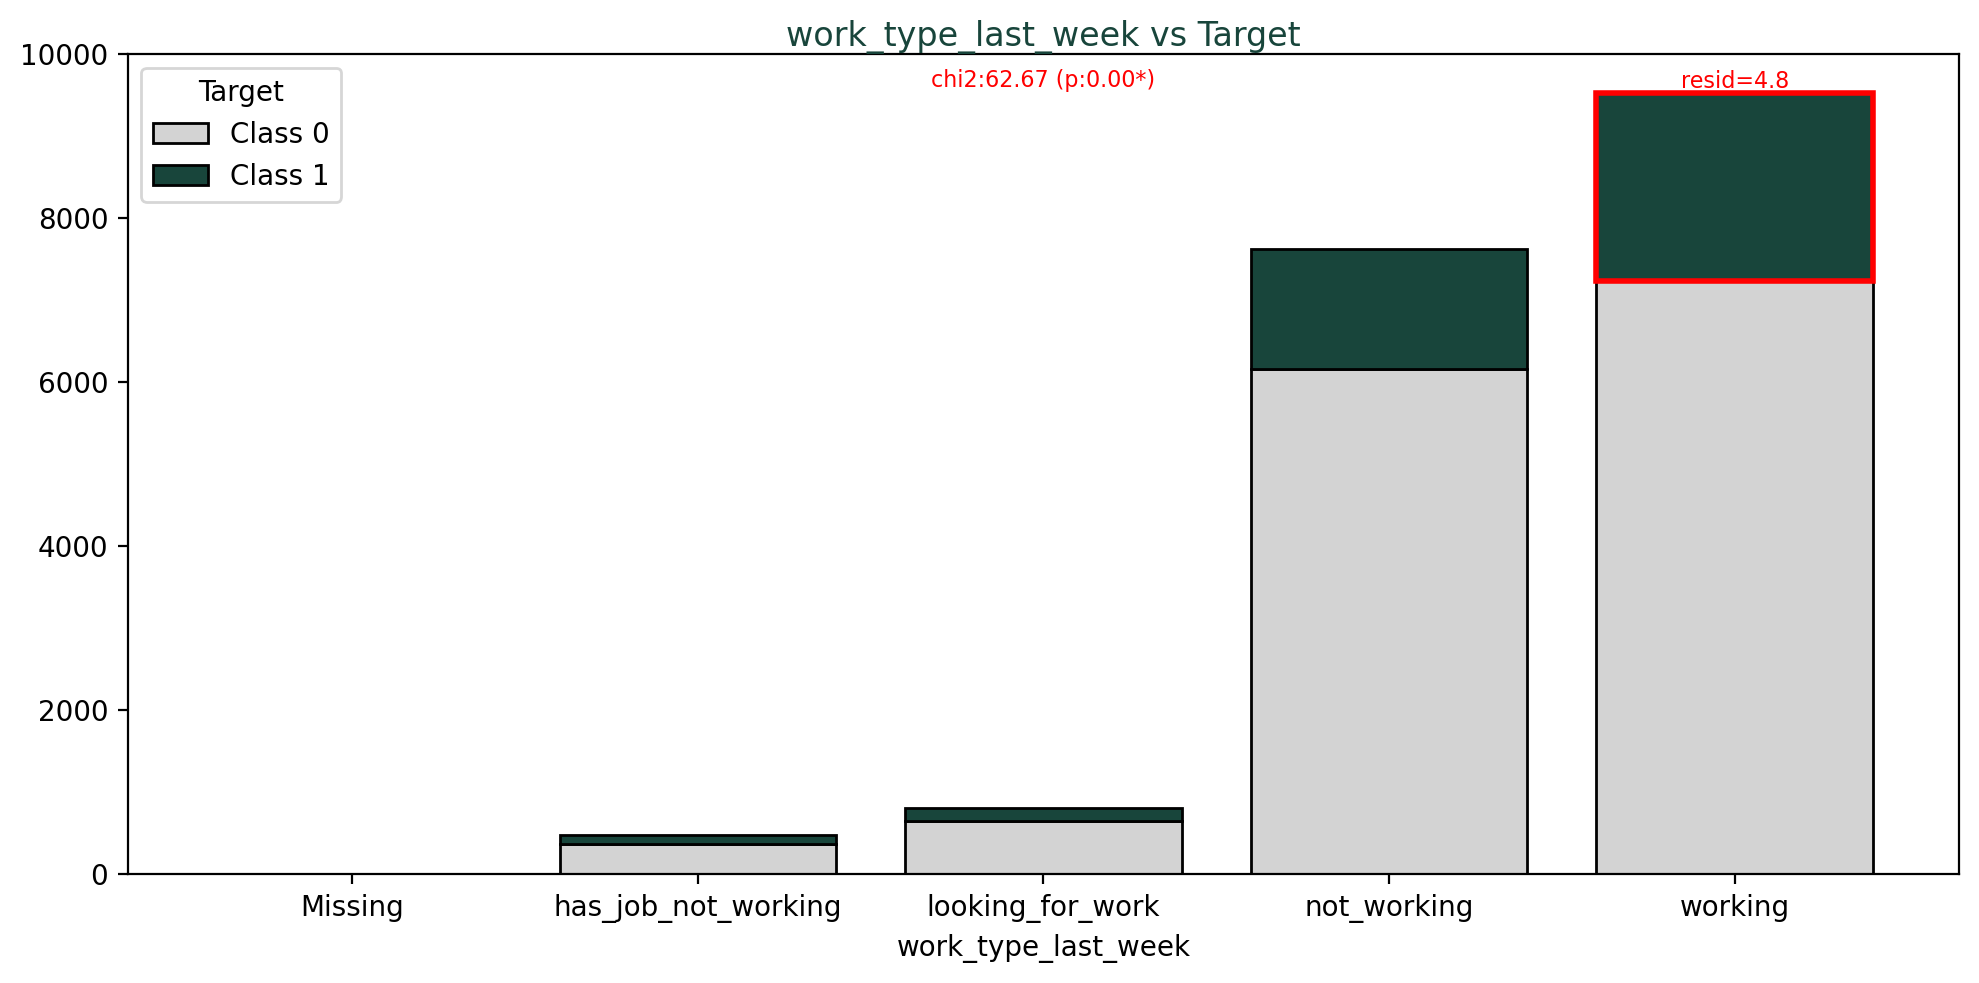

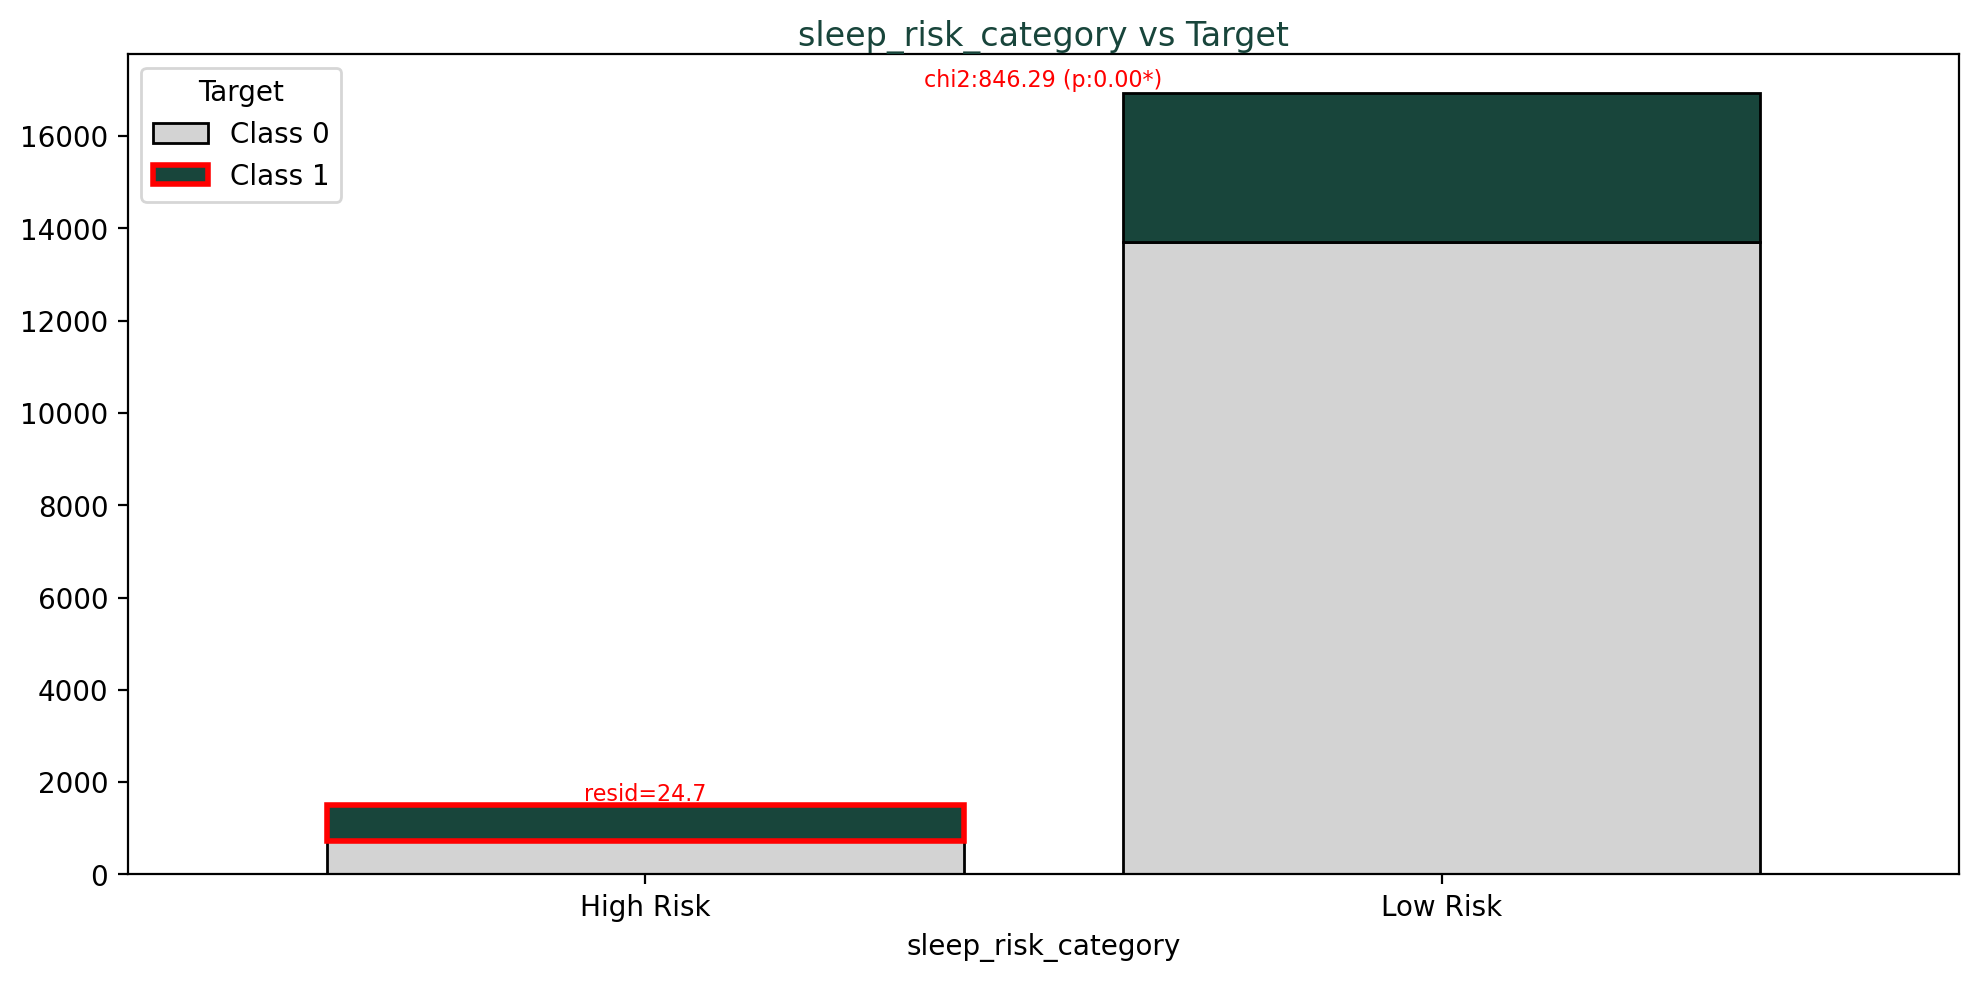

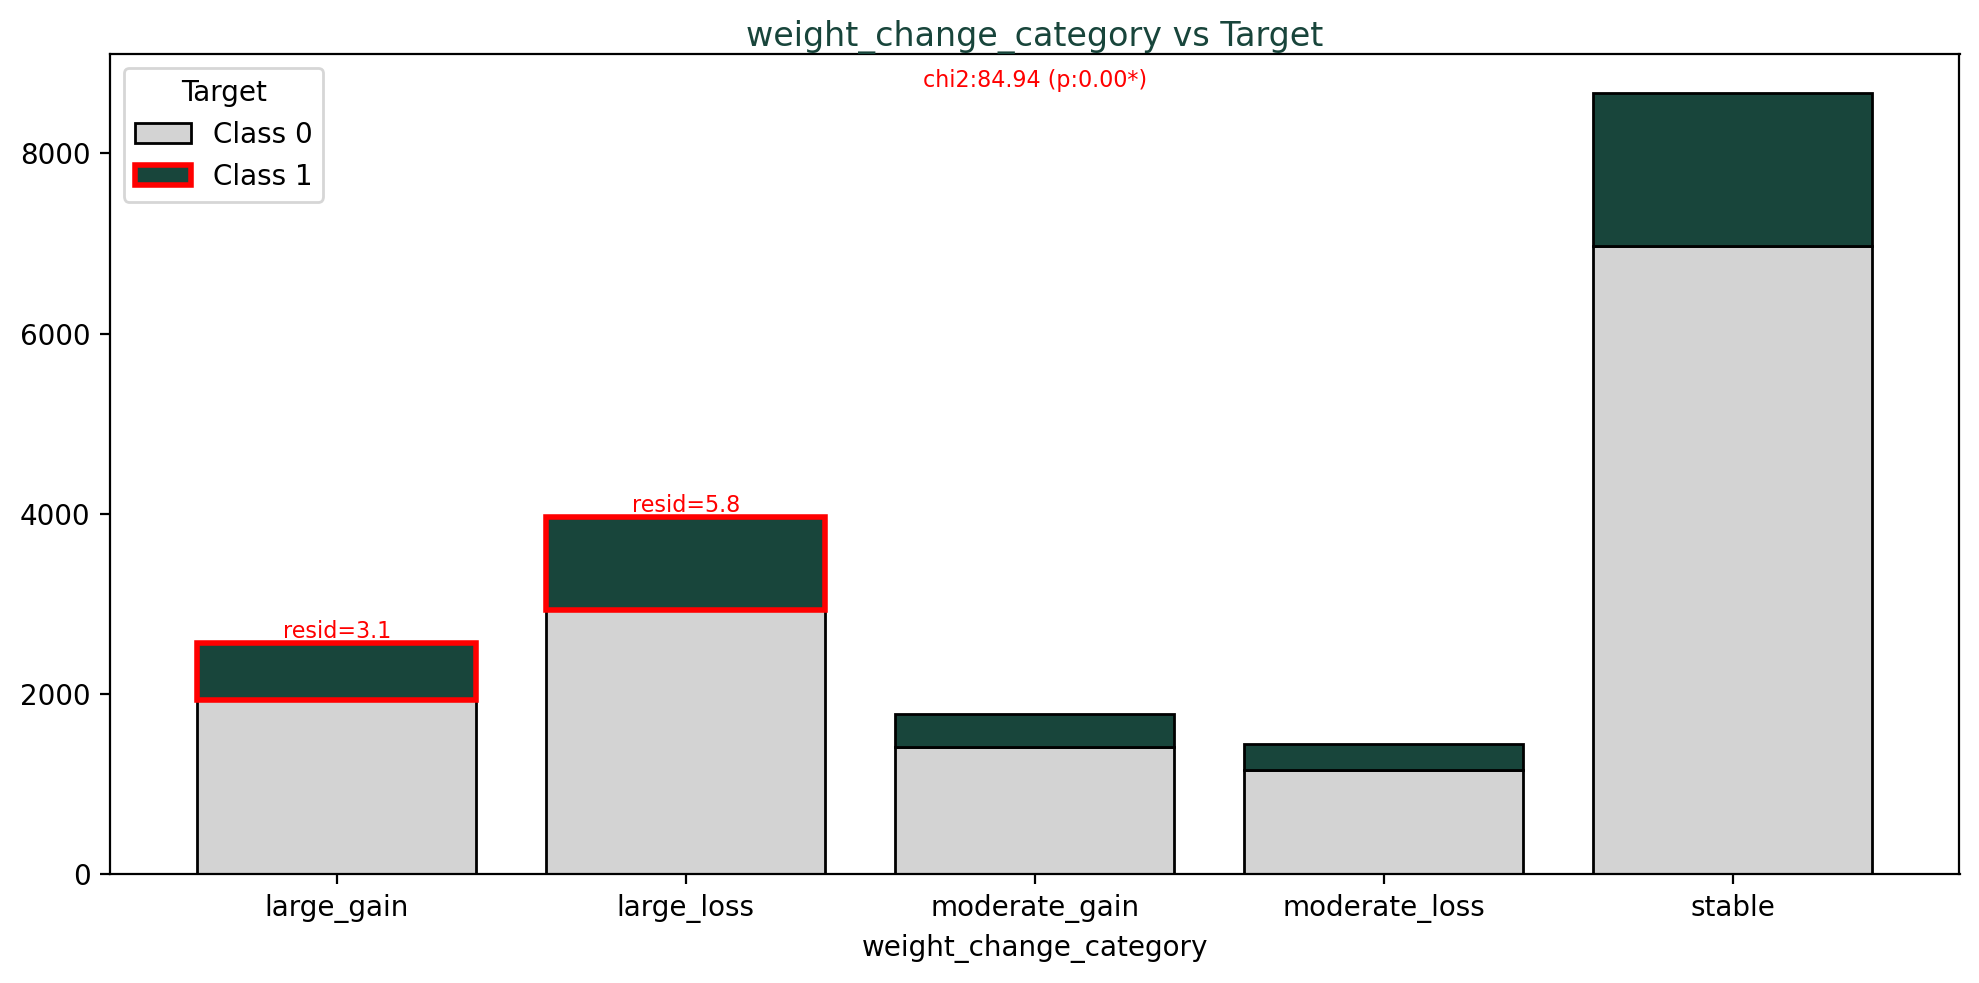

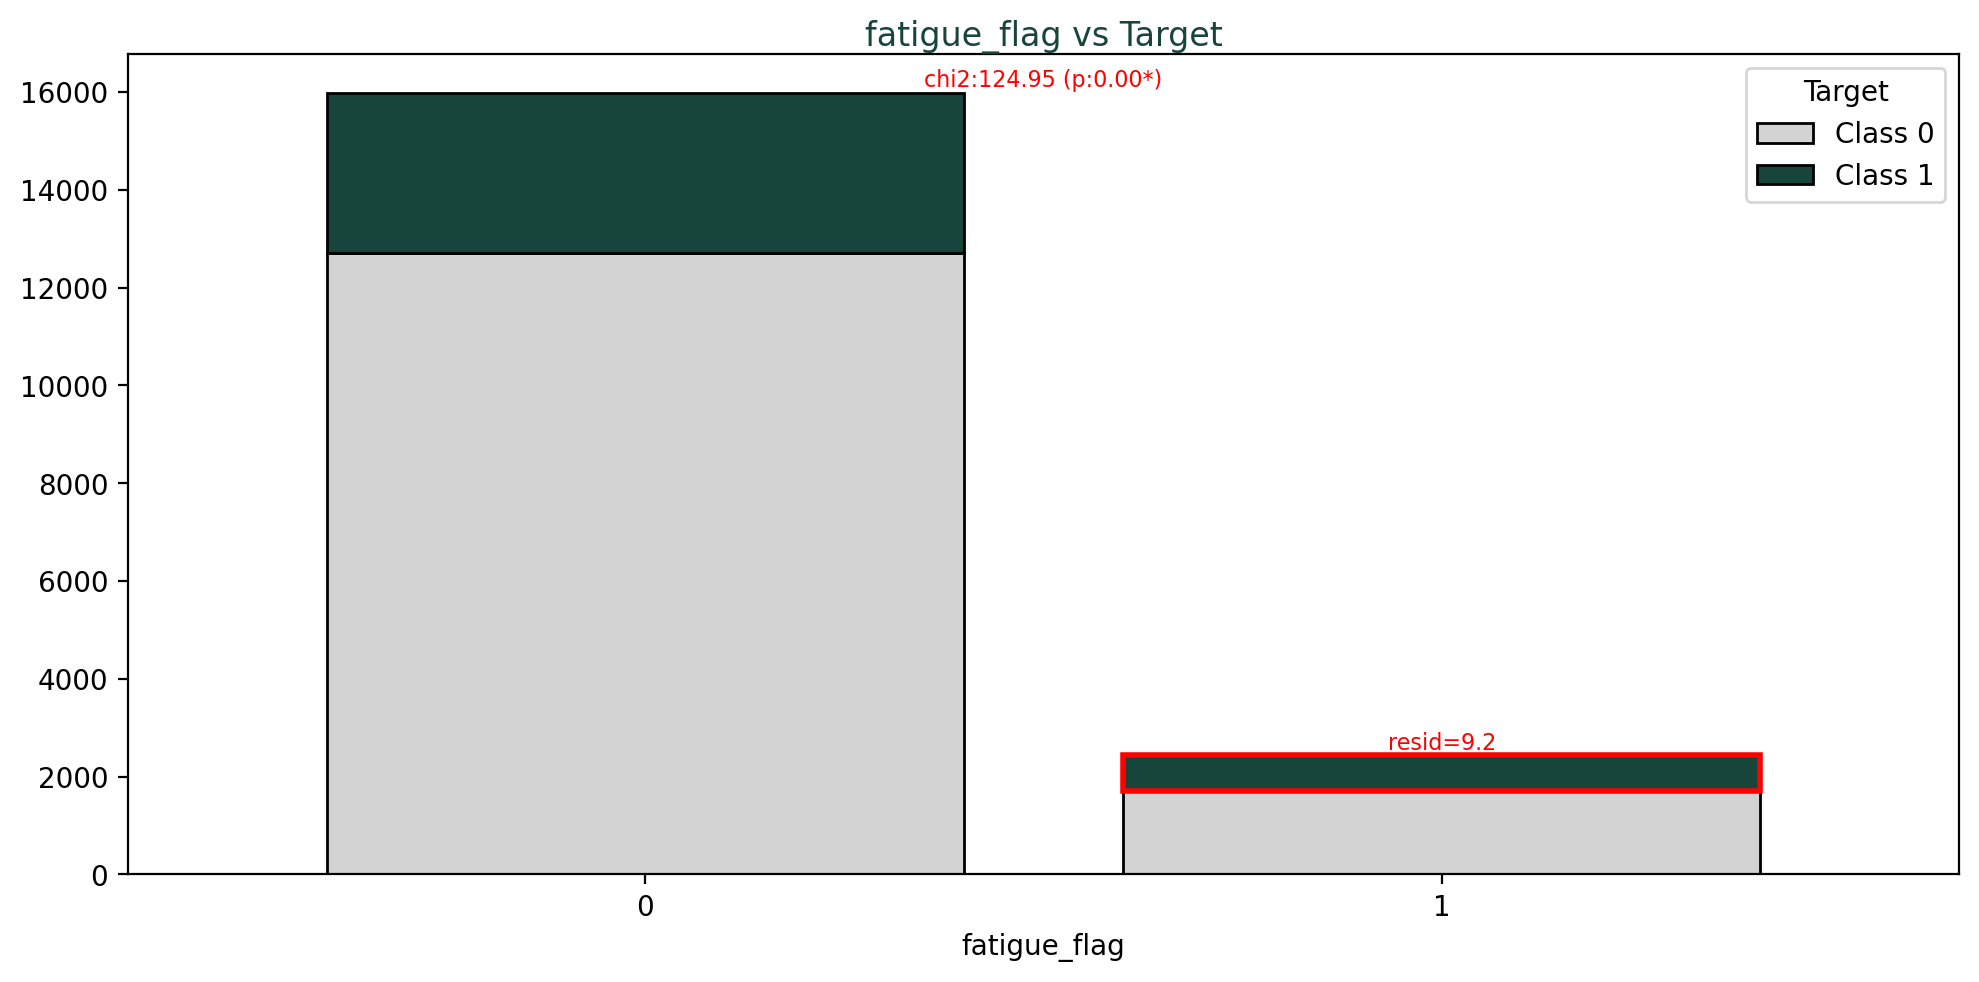

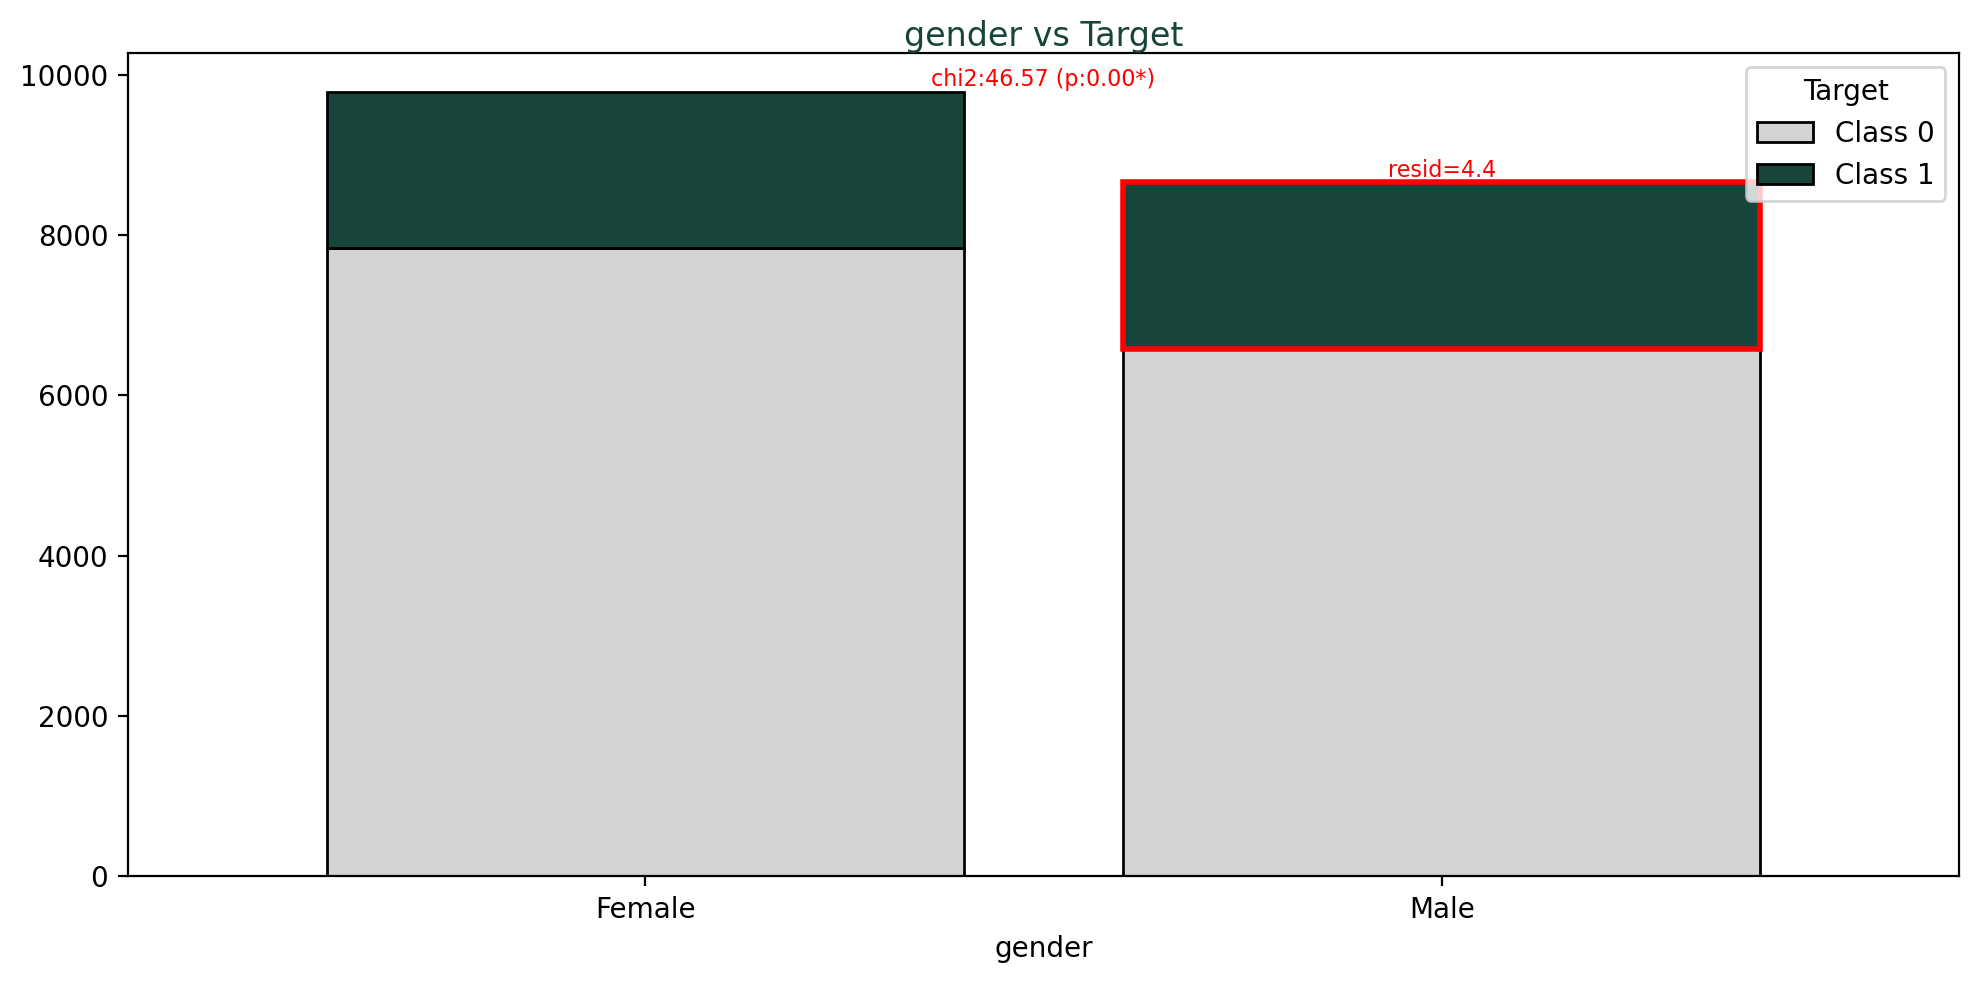

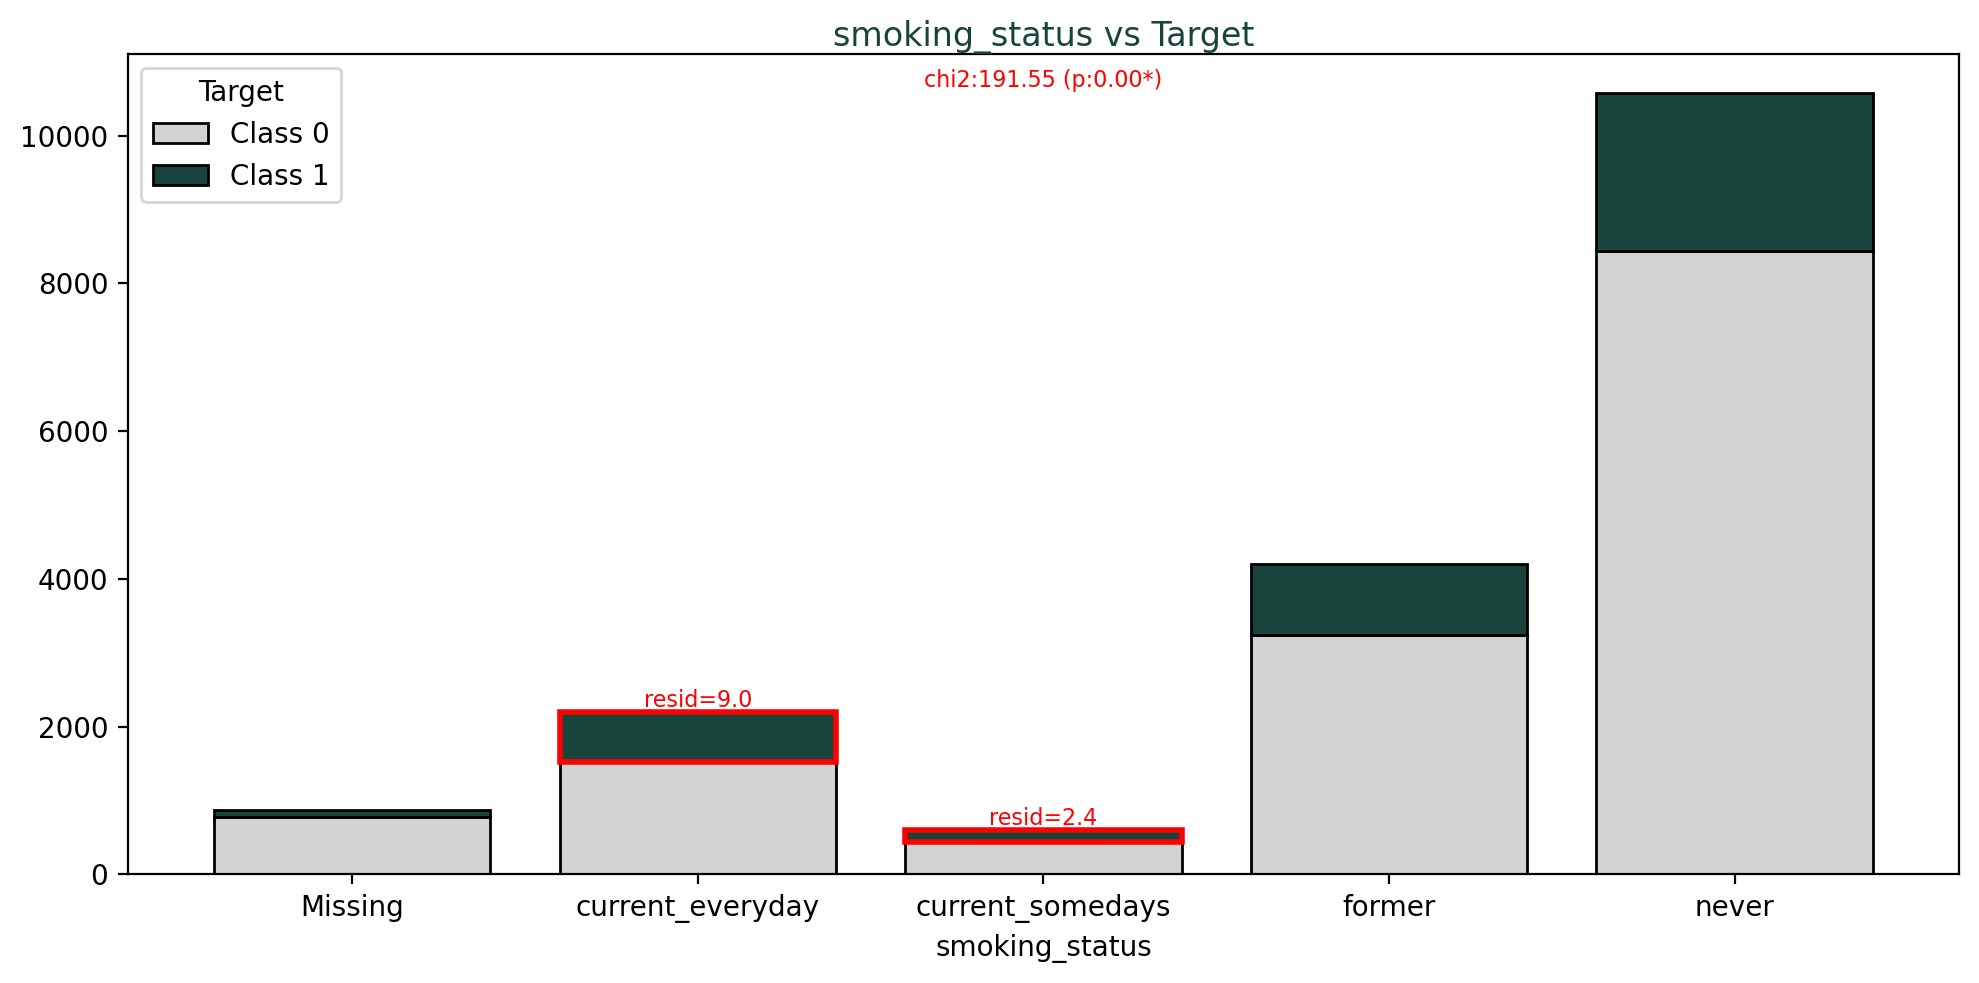

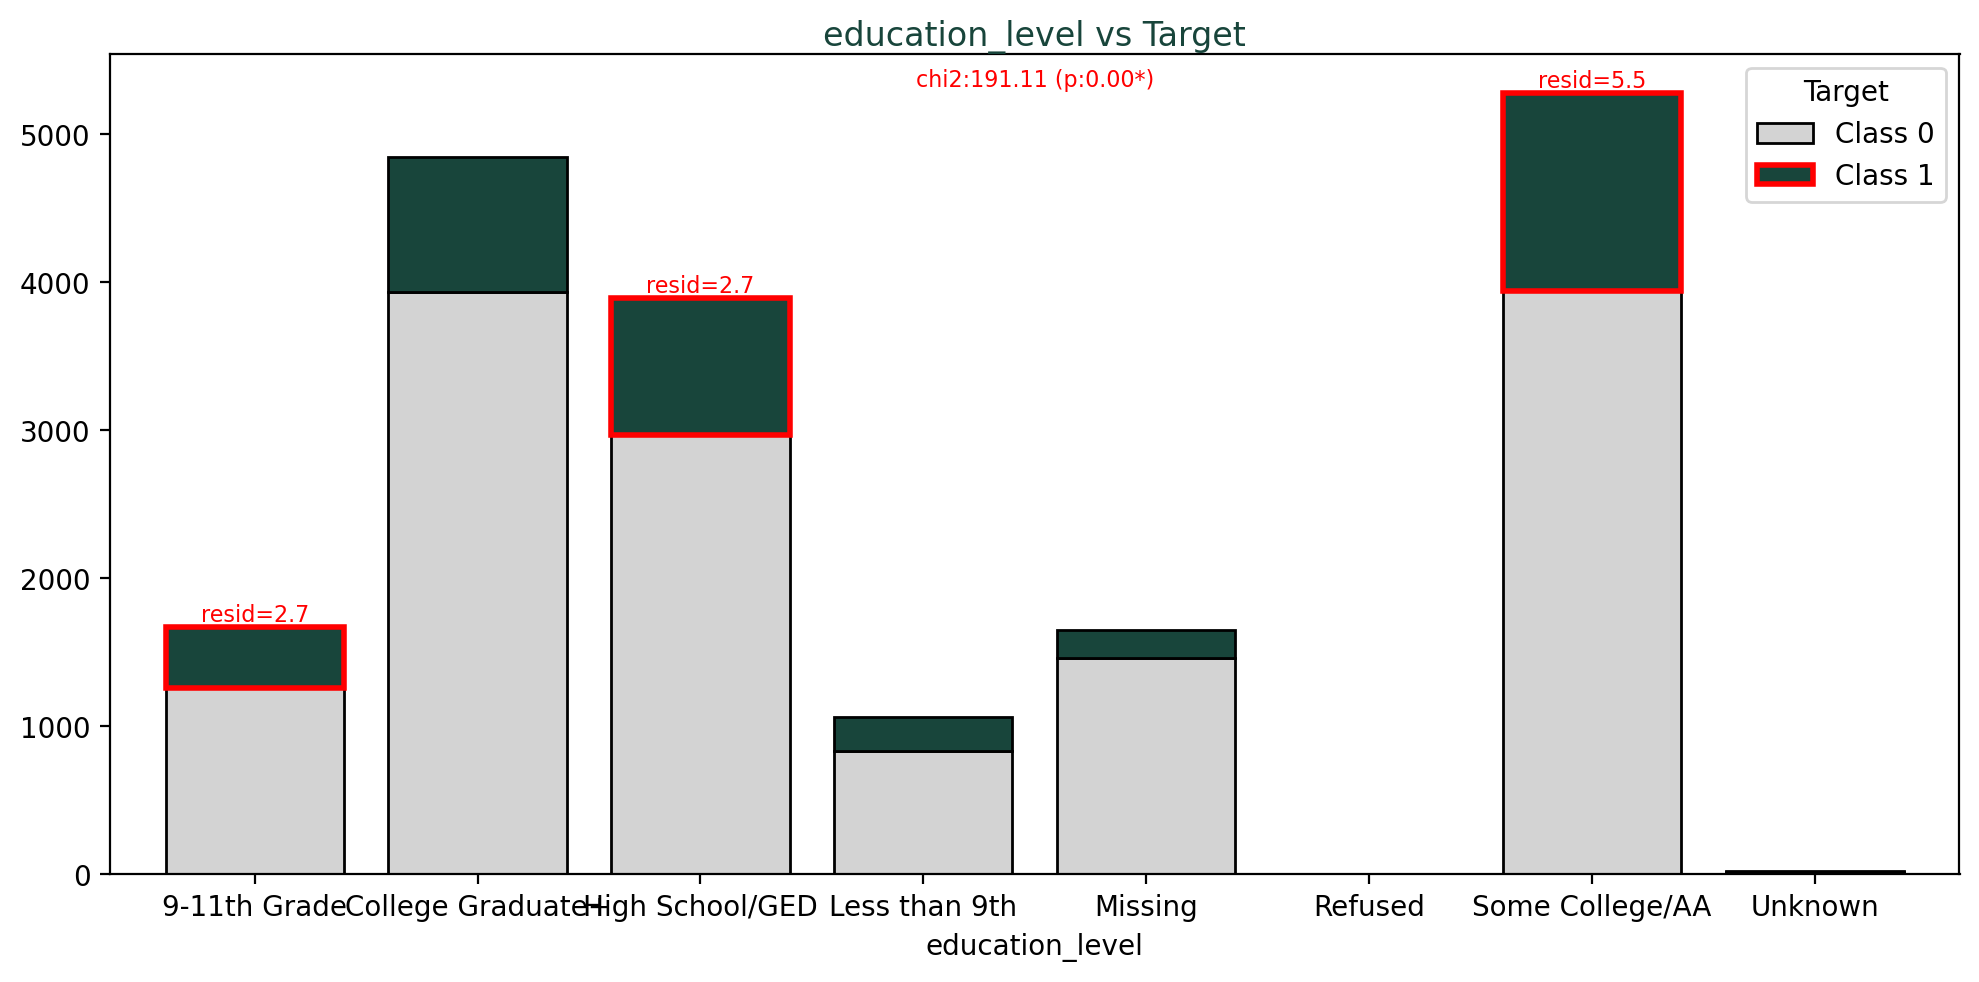

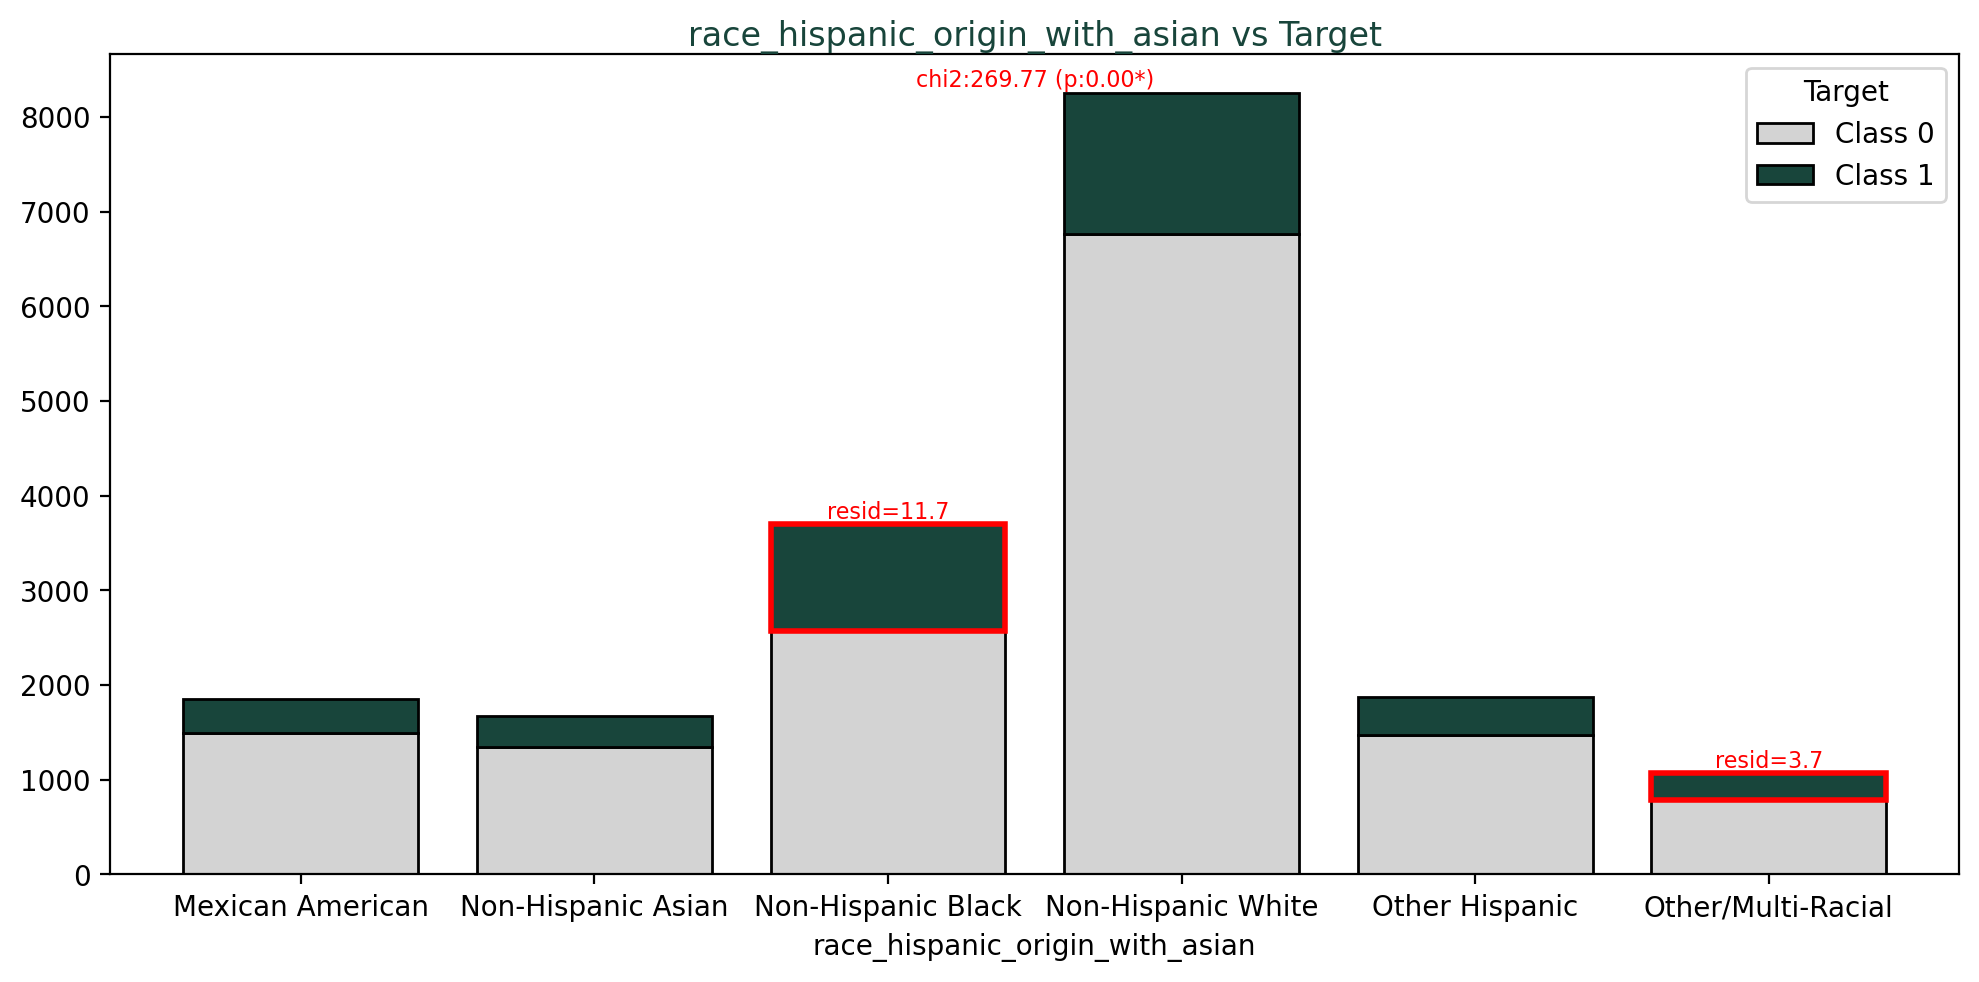

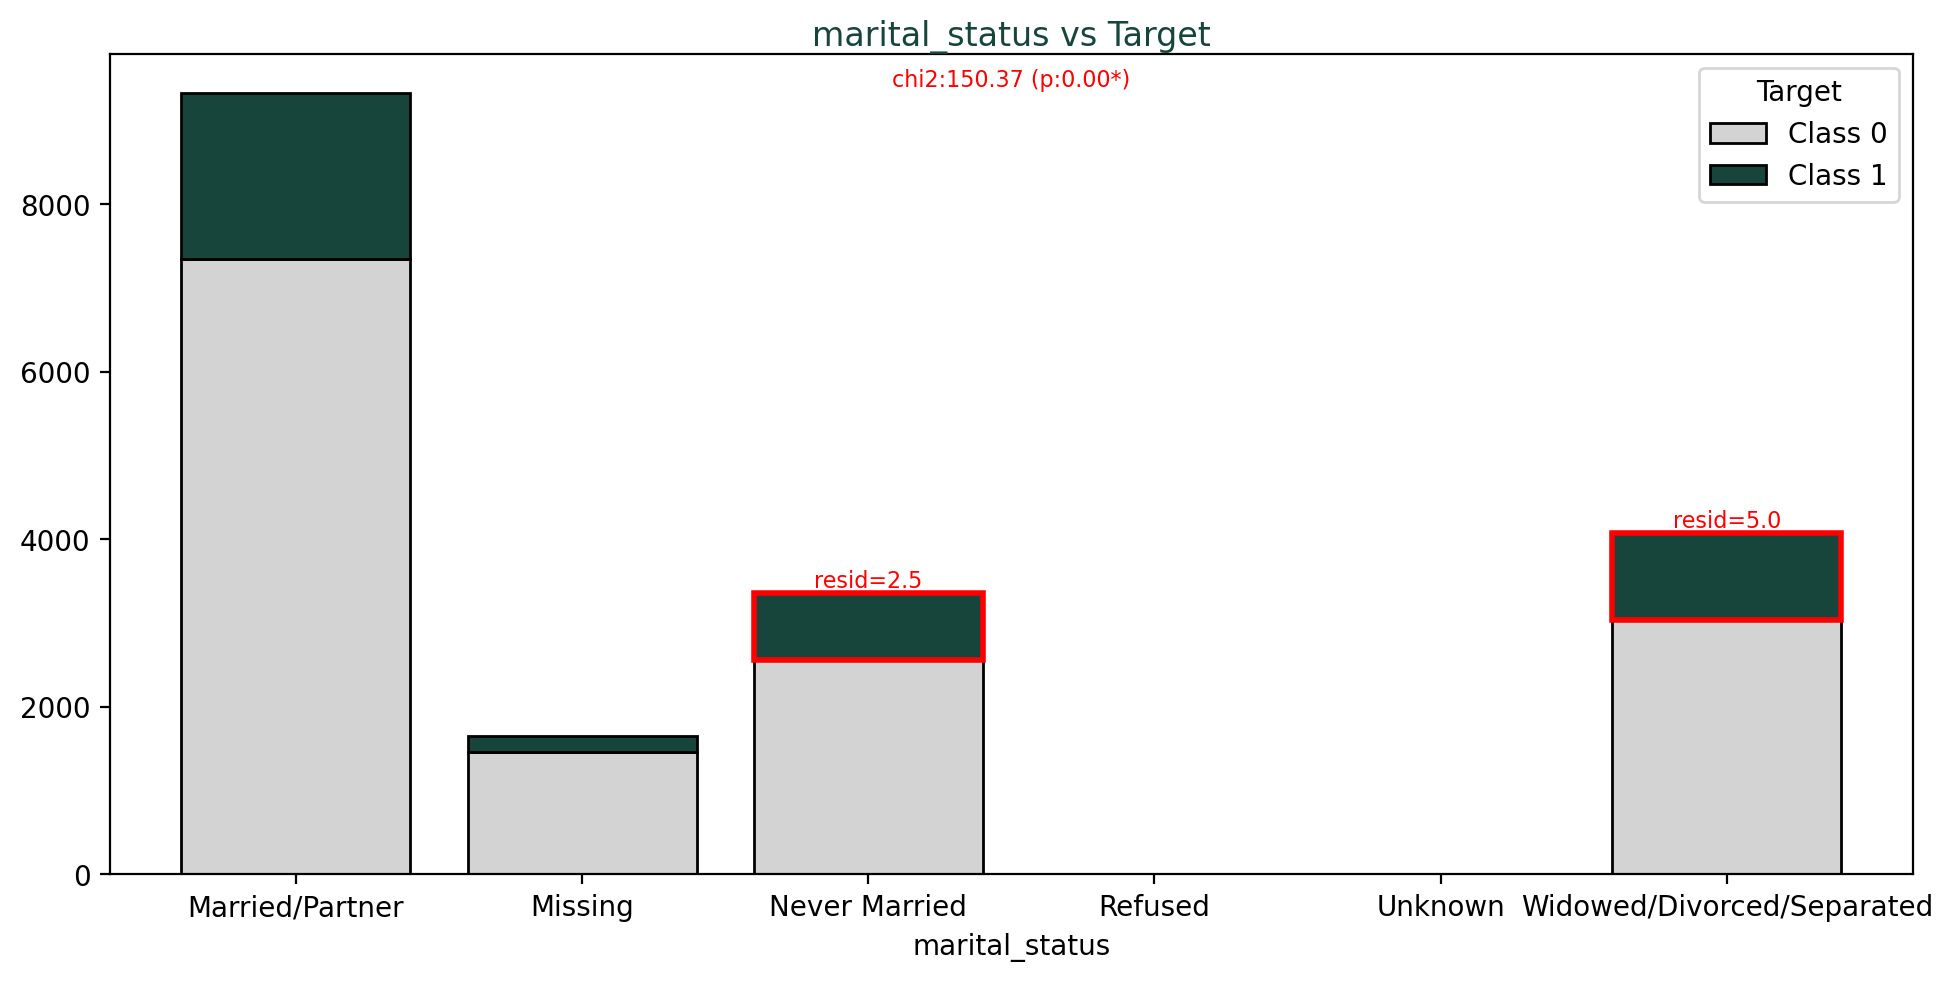

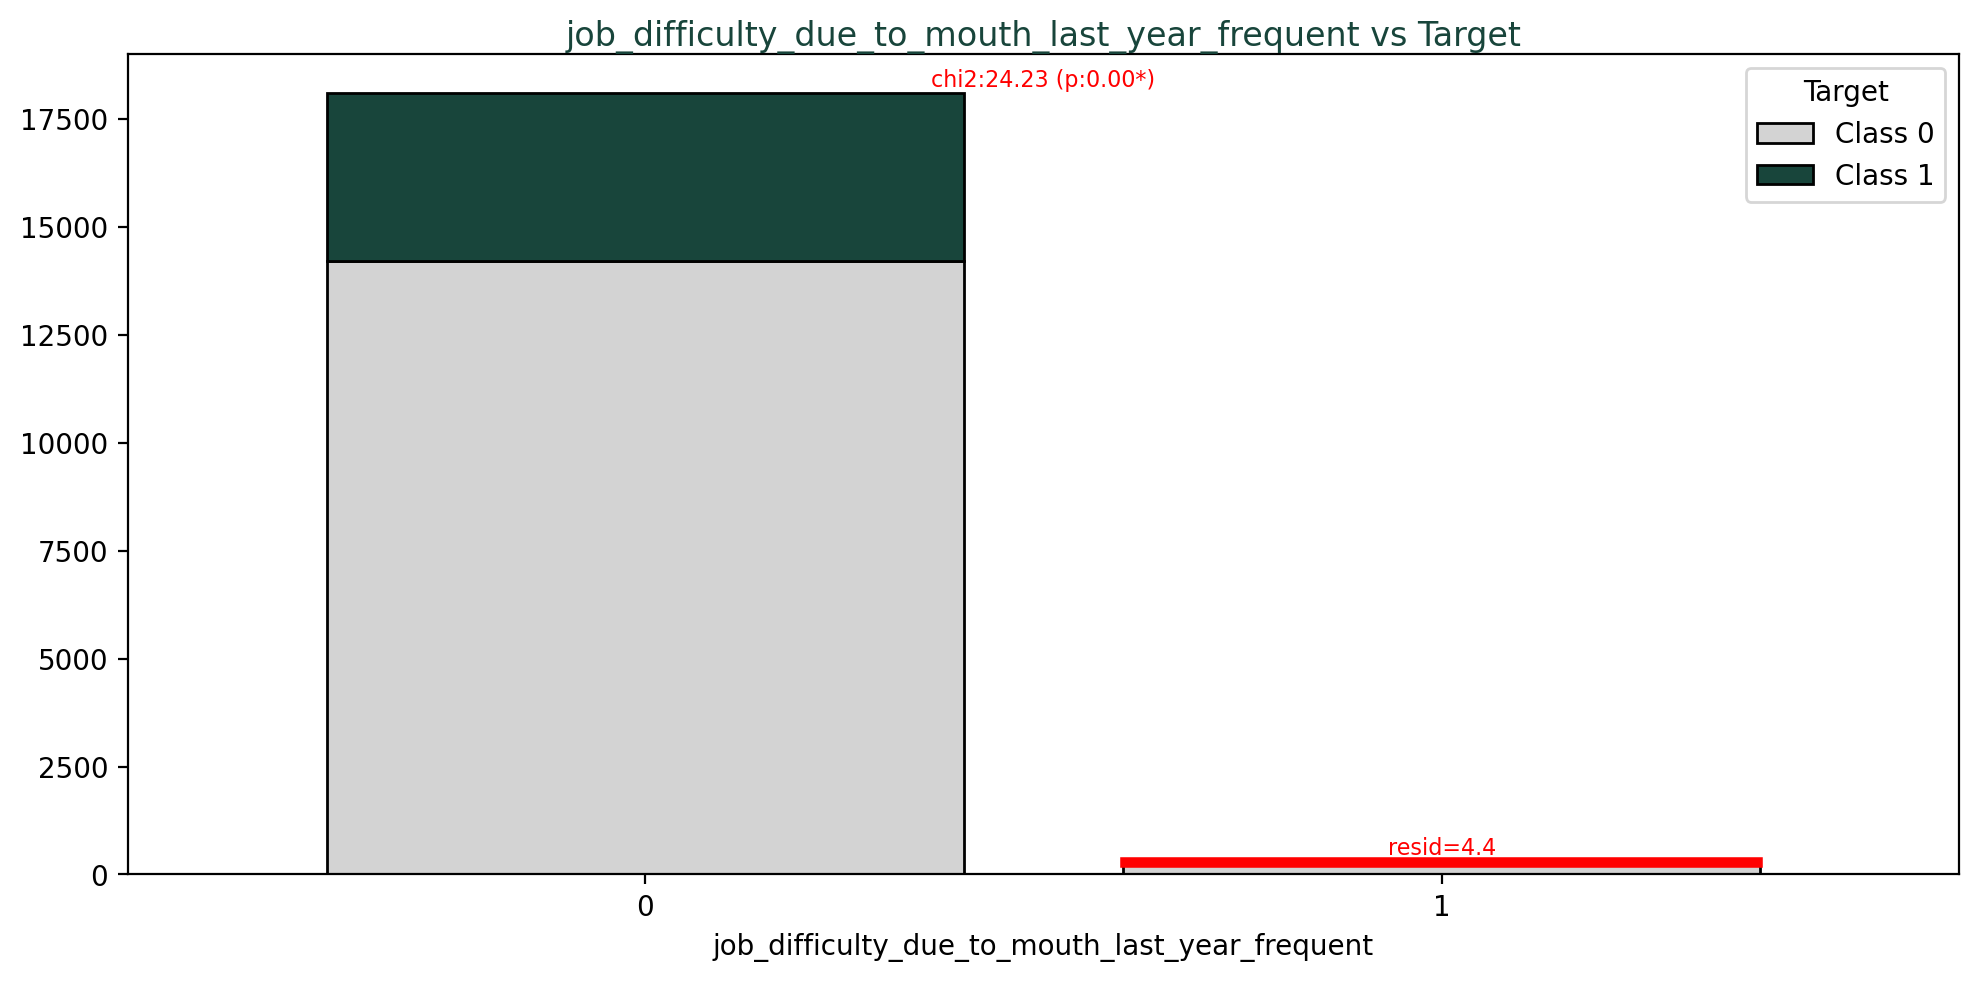

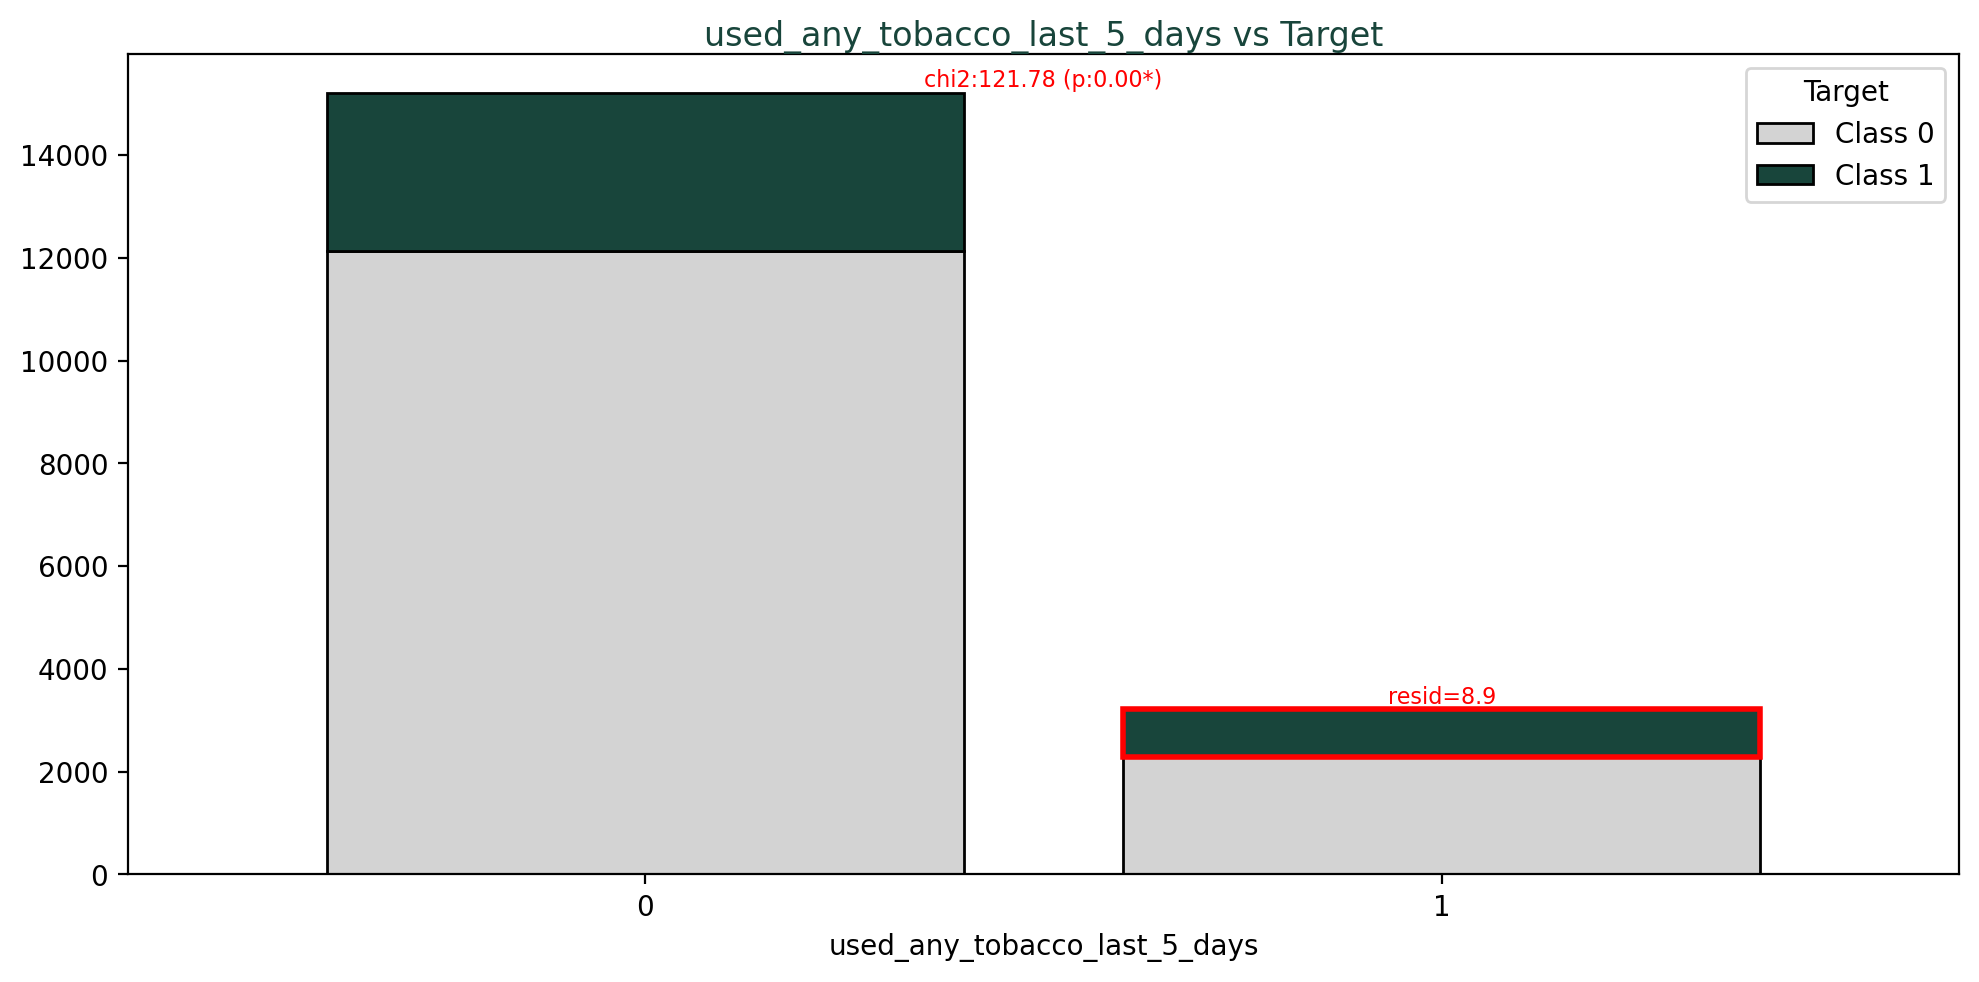

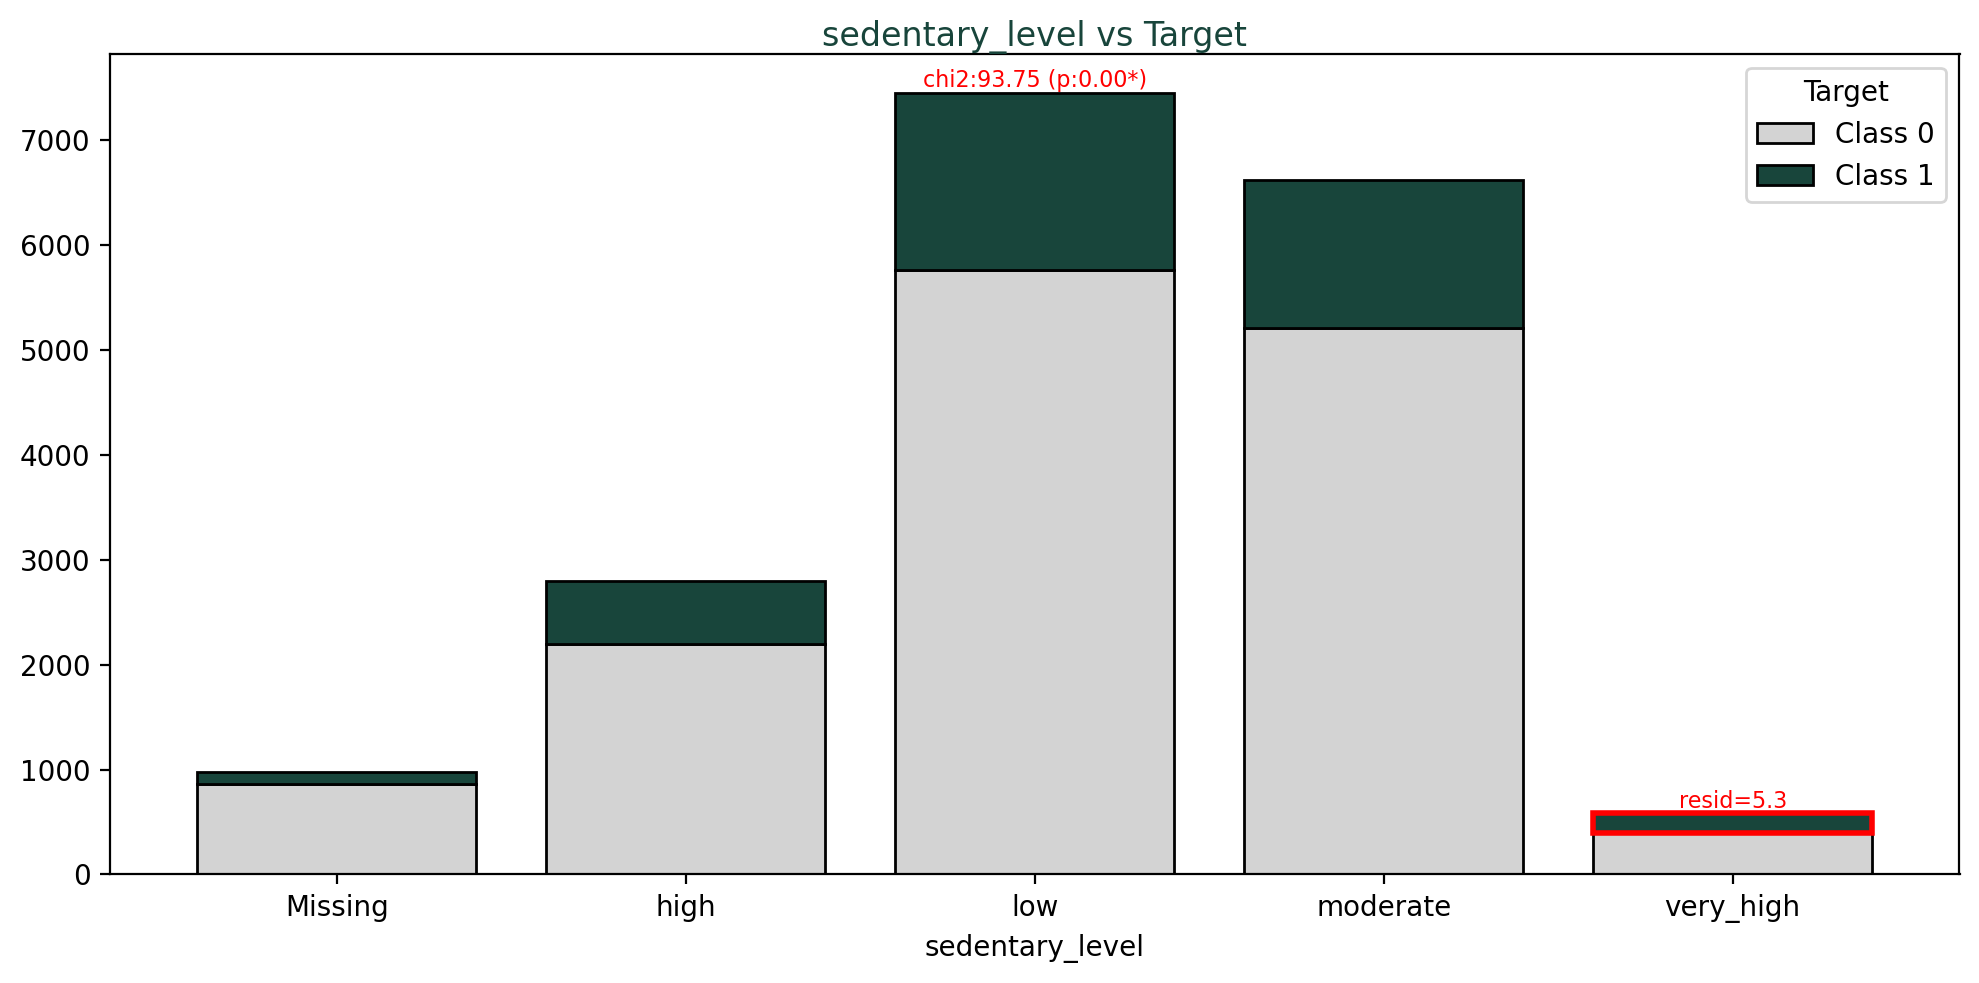

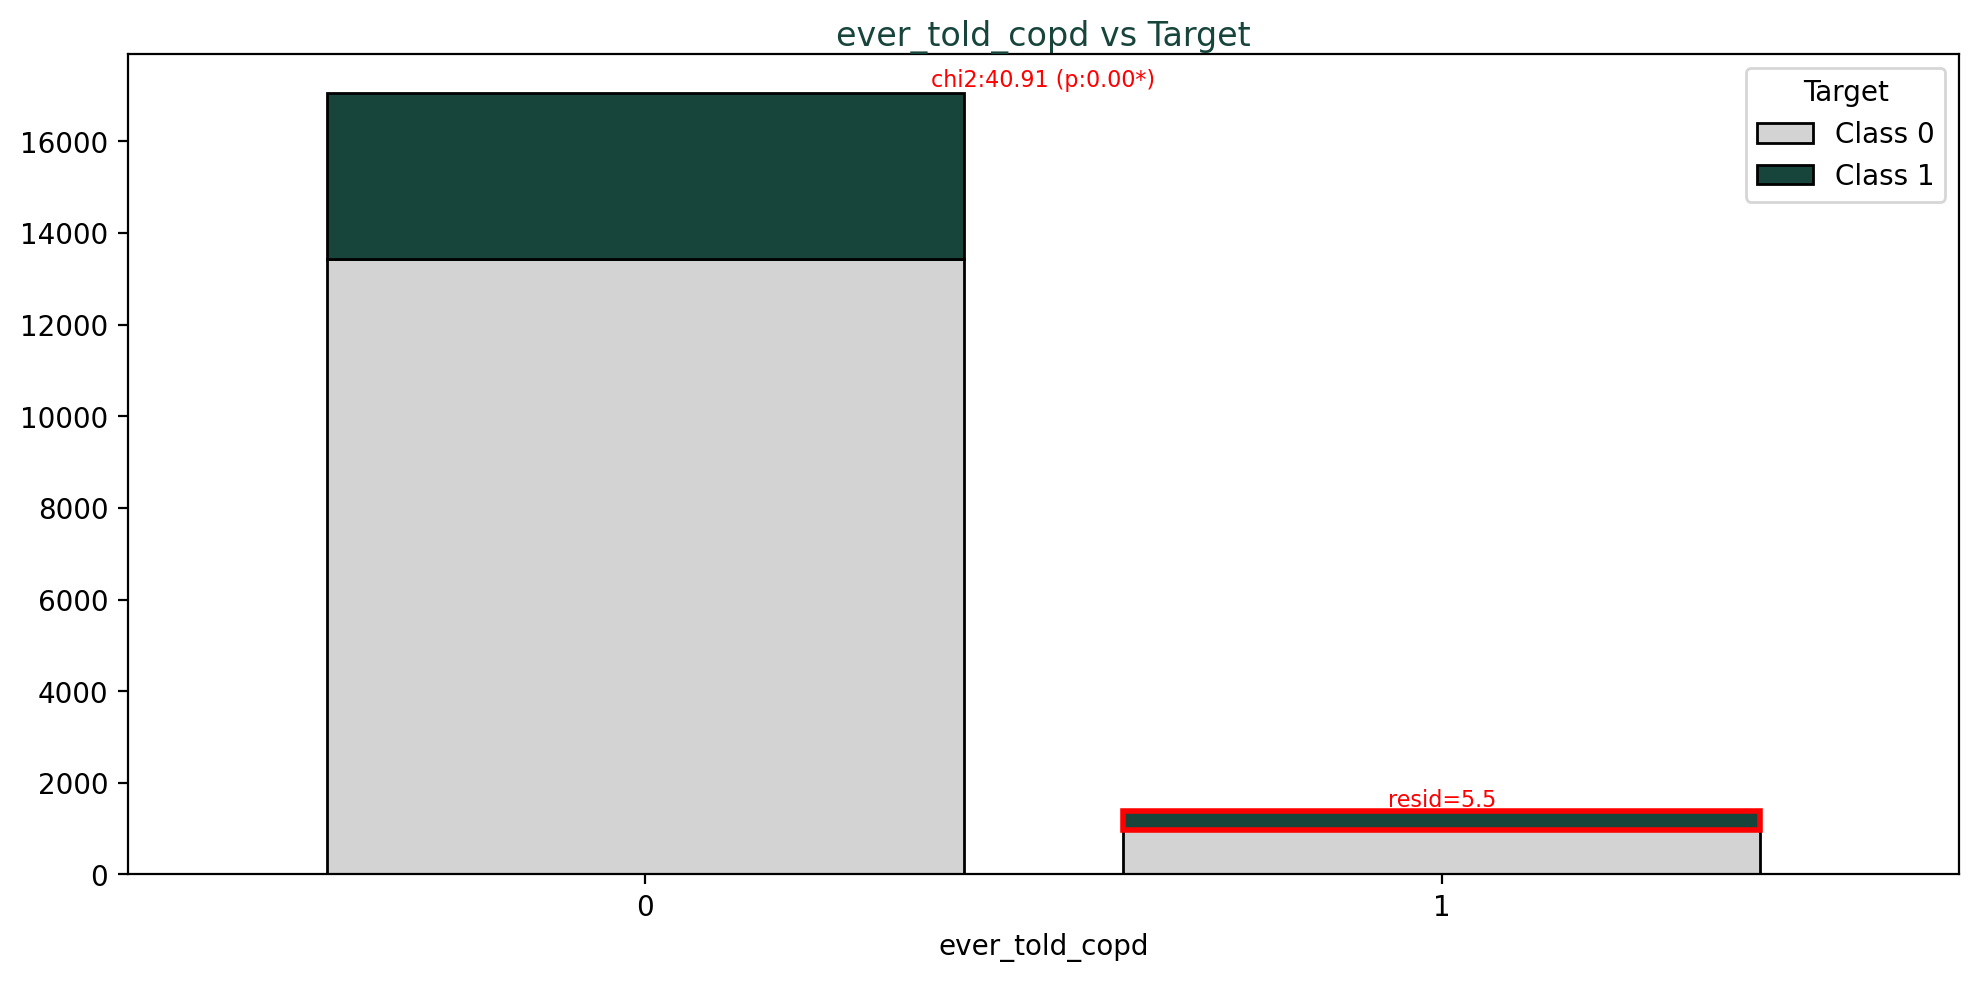

In [231]:
# 3.1 categorical cols
# Cross-tab + chi2 test
for col in categorical_cols:
    # handle missing values in column
    if X_selected[col].isnull().any():
        print(f"warning: {col} has missing values, filling with 'Missing'")
        X_selected[col] = X_selected[col].fillna('Missing')

    # create contingency table
    crosstab = pd.crosstab(X_selected[col], y) # observed frequencies

    # check for low expected frequencies
    try:
        # chi-square test
        chi2, p_val, _, expected = chi2_contingency(crosstab) # expected frequencies under null hypothesis
        expected = pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns)
        
        # warn if expected frequencies are too low (< 5)
        if (expected < 5).any().any():
            print(f"warning: {col} has expected frequencies < 5, chi-square may be unreliable")
        
        # calculate standardized residuals (how much observed counts differ from expected)
        # measure how much observed counts deviate from expected counts under null hypothesis
        # formula: (Observed - Expected) / sqrt(Expected)
        residuals = (crosstab - expected) / np.sqrt(expected + 0.1) # add 0.1 to avoid division by zero
        residuals = pd.DataFrame(residuals, index=crosstab.index, columns=crosstab.columns)
        
        # identify significant categories (residual for class 1 > 2)
        sig_categories = residuals[residuals[1] > 2].index # residual > 2 means p < 0.05 significance level
    except ValueError as e:
        print(f"error: chi-square test failed for {col}: {e}")
        continue

    # plot stacked bar chart
    # plt.figure(figsize=(10, 5))
    ax = crosstab.plot(kind='bar', stacked=True, 
                       color=msu_colors, edgecolor='black', 
                       alpha=1, width=0.8, figsize=(10, 5))

    # only highlights class 1 bars in categories that significantly contribute to chi-square result
    for i, category in enumerate(crosstab.index):
        if category in sig_categories:
            # explicitly access class 1 bar using container
            bars = ax.containers[1] # class 1 bars (second container)
            if i < len(bars):
                class1_bar = bars[i]
                class1_bar.set_edgecolor('red') # highlight with red
                class1_bar.set_linewidth(2)
                
                # add residual annotation
                height = class1_bar.get_height()
                if height > 0: # only annotate if bar has height
                    ax.text(
                        class1_bar.get_x() + class1_bar.get_width() / 2.,
                        class1_bar.get_y() + height + 0.5, # + height / 2.,
                        # f'↑\nresid={residuals.loc[category, 1]:.1f}',
                        f'resid={residuals.loc[category, 1]:.1f}',
                        ha='center', va='bottom', color='red', fontsize=8
                    )

    # set plot title and labels
    plt.title(f'{col} vs Target', color=msu_colors[1], pad=0)
    plt.xticks(rotation=0 if max([len(str(x)) for x in crosstab.index]) > 7 else 0)
    plt.legend(title='Target', labels=['Class 0', 'Class 1'])

    # add chi-square and p-value annotation
    p_text = f'chi2:{chi2:.2f} (p:{p_val:.2f}' + ('*)' if p_val < 0.05 else ')')
    ax.text(
        0.5, 0.96, p_text,
        transform=ax.transAxes,
        color='red' if p_val < 0.05 else '#909090',
        ha='center', fontsize=8
    )

    plt.tight_layout()
    plt.show()

In [495]:
crosstab

is_sleep_deprived,0,1
ever_told_copd,,
0,13443,3620
1,981,394


## Numerical (Other)

In [228]:
# 4.1 T-test (numeric)
ttest_results = []
for col in numerical_cols:
    group1 = X_selected[y == 1][col].dropna()
    group0 = X_selected[y == 0][col].dropna()
    t_stat, p_val = ttest_ind(group1, group0)
    ttest_results.append([col, t_stat, p_val])
ttest_df = pd.DataFrame(ttest_results, columns=['Feature', 't-statistic', 'p-value'])

# result table color setting
threshold = 0.05
def color_pval(val):
    color = '#18453B' if val < threshold else 'gray'
    return f'color: {color}'
styled_ttest = ttest_df.sort_values('p-value').style.map(color_pval, subset=['p-value'])
styled_ttest.set_caption('T-test Results (Green = p < 0.05)')
styled_ttest

,Feature,t-statistic,p-value
0,sleep_time_weekdays_usual_hours,-40.312204,0.000000
3,sleep_time_weekends_usual_hours,-28.450123,0.000000
2,trouble_sleeping_last_2_weeks,14.810412,0.000000
8,sleep_disturbance_score,14.807882,0.000000
6,teeth_gums_health_rating,13.061219,0.000000
7,weight_last_1_year_pounds,12.982364,0.000000
4,feeling_down_last_2_weeks,9.146707,0.000000
11,weight_kg,8.681508,0.000000
5,mid_arm_circumference_cm,6.913916,0.000000
14,systolic_bp_reading1_mmHg,5.193311,0.000000


In [229]:
# 4.2 VIF (numeric)
vif_cols = X_selected.select_dtypes(include=['number']).columns
vif_data = pd.DataFrame({
    'Feature': vif_cols,
    'VIF': [variance_inflation_factor(X_selected[vif_cols].values, i) 
           for i in range(len(vif_cols))]
})

# VIF result color setting
threshold = 10
def color_vif(val):
    color = '#18453B' if val > threshold else 'gray' # VIF > threshold: green, else: gray
    return f'color: {color}'
styled_vif = vif_data.sort_values('VIF', ascending=False).style.map(color_vif, subset=['VIF'])
styled_vif.set_caption(f'VIF Scores (Green = VIF > {threshold})')
styled_vif

,Feature,VIF
5,mid_arm_circumference_cm,31.625308
14,systolic_bp_reading1_mmHg,22.078256
11,weight_kg,15.133212
7,weight_last_1_year_pounds,12.934245
8,sleep_disturbance_score,8.776123
1,age_years,8.631311
2,trouble_sleeping_last_2_weeks,6.645681
6,teeth_gums_health_rating,6.396310
0,sleep_time_weekdays_usual_hours,5.642236
3,sleep_time_weekends_usual_hours,4.183924


# Handle Missing Values
- Imputation using XGBRegressor and XGBClassifier

In [211]:
# select numerical and categorical cols
numerical_cols = X_selected.select_dtypes(include=['float64']).columns # numerical
categorical_cols = X_selected.select_dtypes(include=['object']).columns # categorical

# encode categorical cols (for imputation)
X_categorical_encoded = X_selected[categorical_cols].copy()
for col in categorical_cols:
    X_categorical_encoded[col] = X_categorical_encoded[col].astype('category').cat.codes
    X_categorical_encoded[col] = X_categorical_encoded[col].replace(-1, np.nan) # replace -1 (missing values after encoding) with nan

In [212]:
# impute numerical cols (iterativeimputer)
numerical_imputer = IterativeImputer(
    estimator=XGBRegressor(random_state=SEED), # xgboost
    # estimator=RandomForestRegressor(n_estimators=50, random_state=SEED), # rf
    max_iter=20, # iterations 10 -> 20 to help convergence
    tol=1e-2, # relax tolerance for convergence
    random_state=SEED,
    verbose=1
)
X_numerical_imputed = numerical_imputer.fit_transform(X_selected[numerical_cols])
X_numerical_imputed_df = pd.DataFrame(
    X_numerical_imputed,
    columns=numerical_cols,
    index=X_selected.index
)

# impute categorical columns (iterativeimputer)
categorical_imputer = IterativeImputer(
    estimator=XGBClassifier(random_state=SEED), # xgboost
    # estimator=RandomForestClassifier(n_estimators=50, random_state=SEED), # rf
    max_iter=20,
    tol=1e-2,
    random_state=SEED,
    verbose=1
)
X_categorical_imputed = categorical_imputer.fit_transform(X_categorical_encoded)
X_categorical_imputed_df = pd.DataFrame(
    X_categorical_imputed,
    columns=categorical_cols,
    index=X_selected.index
)

# decode categorical columns back to original values
X_categorical_final = X_categorical_imputed_df.copy()
for col in categorical_cols:
    # map numeric codes back to original categories
    code_to_category = dict(enumerate(X_selected[col].astype('category').cat.categories))
    X_categorical_final[col] = X_categorical_final[col].round().astype(int).map(code_to_category)

# combine numerical and categorical imputed data
X_imputed = pd.concat([X_numerical_imputed_df, X_categorical_final], axis=1)

[IterativeImputer] Completing matrix with shape (18438, 16)
[IterativeImputer] Change: 0.0, scaled tolerance: 254.0 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (18438, 14)
[IterativeImputer] Change: 0.0, scaled tolerance: 0.07 
[IterativeImputer] Early stopping criterion reached.


In [213]:
print_cols(X_imputed)

(18438, 30)


,sleep_time_weekdays_usual_hours,age_years,trouble_sleeping_last_2_weeks,sleep_time_weekends_usual_hours,feeling_down_last_2_weeks,mid_arm_circumference_cm,teeth_gums_health_rating,weight_last_1_year_pounds,sleep_disturbance_score,minutes_sedentary_activity,family_income_to_poverty_ratio,weight_kg,total_deliveries,estradiol_pg_mL,systolic_bp_reading1_mmHg,estrone_sulfate_pg_mL,race_hispanic_origin,work_type_last_week,sleep_risk_category,weight_change_category,fatigue_flag,gender,smoking_status,education_level,race_hispanic_origin_with_asian,marital_status,job_difficulty_due_to_mouth_last_year_frequent,used_any_tobacco_last_5_days,sedentary_level,ever_told_copd
respondent_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
109266,22.0,29.0,0.0,23.0,0.0,4.0,4.0,200.0,0.0,480.0,5.00,97.1,0.0,35.5,99.0,0.0,Other/Multi-Racial,working,Low Risk,moderate_gain,0,Female,never,College Graduate+,Non-Hispanic Asian,Never Married,0,0,moderate,0
109267,0.0,21.0,0.0,3.0,0.0,0.0,1.0,125.0,0.0,540.0,5.00,0.0,0.0,0.0,0.0,0.0,Other Hispanic,working,Low Risk,stable,0,Female,never,Some College/AA,Other Hispanic,Never Married,0,0,high,0
109268,22.0,18.0,0.0,23.0,0.0,0.0,2.0,120.0,0.0,540.0,1.66,0.0,0.0,0.0,0.0,0.0,Non-Hispanic White,not_working,Low Risk,stable,0,Female,never,Missing,Non-Hispanic White,Missing,0,0,high,0
109271,23.0,49.0,0.0,23.0,1.0,4.0,4.0,180.0,0.0,60.0,0.00,98.8,0.0,69.6,102.0,273.0,Non-Hispanic White,not_working,Low Risk,large_gain,0,Male,current_everyday,9-11th Grade,Non-Hispanic White,Never Married,0,1,low,1
109273,8.0,36.0,2.0,21.0,2.0,3.0,5.0,155.0,4.0,180.0,0.83,74.3,0.0,23.4,116.0,267.0,Non-Hispanic White,working,High Risk,moderate_gain,1,Male,current_everyday,Some College/AA,Non-Hispanic White,Never Married,0,1,low,0


In [214]:
# data types and missing values for selected features
print('Imputed data dtypes and missing values:')
print(pd.concat([X_imputed.dtypes, X_imputed.isnull().sum()], axis=1))

Imputed data dtypes and missing values:
                                                      0  1
sleep_time_weekdays_usual_hours                 float64  0
age_years                                       float64  0
trouble_sleeping_last_2_weeks                   float64  0
sleep_time_weekends_usual_hours                 float64  0
feeling_down_last_2_weeks                       float64  0
mid_arm_circumference_cm                        float64  0
teeth_gums_health_rating                        float64  0
weight_last_1_year_pounds                       float64  0
sleep_disturbance_score                         float64  0
minutes_sedentary_activity                      float64  0
family_income_to_poverty_ratio                  float64  0
weight_kg                                       float64  0
total_deliveries                                float64  0
estradiol_pg_mL                                 float64  0
systolic_bp_reading1_mmHg                       float64  0
estrone_sulfate_

# Save

In [453]:
with open('data/X_imputed.pkl', 'wb') as file: 
    pickle.dump(X_imputed, file) 
with open('data/y.pkl', 'wb') as file: 
    pickle.dump(y, file)

# with open('X_imputed.pkl', 'rb') as file: 
#     X_imputed = pickle.load(file)
# with open('y.pkl', 'rb') as file: 
#     y = pickle.load(file)